# M3 — Architecture du solveur, état de validation, feuille de route

*Document de référence. Toutes les affirmations numériques proviennent des sorties de RUN 9 et RUN 12 telles que rapportées ; celles qui sont incohérentes entre sources sont signalées explicitement en §7.5.*

---

## 0. Avertissement de lecture

Deux principes gouvernent ce document.

**Un chiffre n'a de sens que si son estimand est identifié.** Le mode d'échec dominant du projet, documenté sur quatre cas (CROSS_NEG, COH, `lam_deflate`, `err_p`), n'a jamais été le solveur : c'est le jugement porté sur des agrégats dont on n'avait pas établi ce qu'ils mesuraient. Ce document indique donc, pour chaque métrique, *sur quel échantillon* et *sous quelle condition d'identification* elle est interprétable.

**Une prédiction théorique prime sur une intuition mécanique.** La §5 corrige une affirmation centrale du fichier de contexte. Cette correction change la conclusion tactique de la feuille de route et doit être lue avant toute décision de recalibration.

---

## 1. Résumé exécutif

Le code résout, par réseaux de neurones informés par la physique (PINN de type DEQN), un jeu dynamique d'extraction de ressource épuisable à N agents avec structure de conduite arbitraire (oligopolistes singletons, cartels, frange preneuse de prix), contrainte de capacité active et horizon fini.

**Configuration courante** : N = 2, un cartel singleton (agent 0, c = 10, κ = 20, S₀ = 700) et une frange preneuse de prix (agent 1, c = 20, κ = 30, S₀ = 450), T = 50, α = 100, β = 1, r = 5 %. C'est exactement le jeu cartel–frange de Salant (1976).

**Ce qui est acquis** : l'étage A (open-loop) est validé. Le réseau retrouve l'oracle analytique à `err_p_noext = 8.4 × 10⁻³`, avec la rente de Hotelling exacte sur les dates intérieures, une surface de valeur ancrée (Bellman MC 1.6 %) et un gradient diagonal ∂V₀/∂S₀ correct à 1.17 % sur le sentier.

**Ce qui n'est pas acquis** : l'étage B n'a jamais tourné depuis la restauration du socle. L'étage C (MPE) est encore inatteignable faute de référence closed-loop — et, comme le montre la §5, faute de divergence à mesurer sur cette configuration.

**Correction majeure (§5)**. Le fichier de contexte affirme que l'en-tête du code était fausse et que la divergence open-loop / closed-loop existe à un seul joueur stratégique face à une frange. **C'est la correction qui est fausse.** Benchekroun & Withagen (2012, *Games and Economic Behavior* 76(2), 355–374) démontrent que les issues du jeu cartel–frange en boucle ouverte et en boucle fermée **coïncident** lorsque la frange est preneuse de prix. La littérature sur l'incohérence temporelle invoquée par la correction porte sur l'équilibre de **von Stackelberg**, où le cartel internalise la fonction de réaction instantanée de la frange — conduite que le code n'implémente pas. Conséquence directe : recalibrer stocks et coûts pour faire apparaître un feedback non nul à N = 1 stratégique est voué à l'échec, parce que le résultat nul est théorique et non calibratoire. La divergence est à chercher à N ≥ 2 joueurs stratégiques, ce qui était la justification initiale de M3.

---

## 2. Le modèle

**État.** S ∈ ℝᴺ, vecteur des stocks. Le temps t ∈ {0, …, T} est un second argument (embedding discret), pas une variable d'état continue.

**Demande.** p = α − β Σᵢ xᵢ.

**Conduite.** Une matrice A ∈ {0,1}^{N×N} : A[i,j] = 1 ssi i et j appartiennent au même bloc de coalition ; la frange a une ligne nulle. On pose Λ = A·x. Alors :

| Type d'agent | Ligne de A | Λᵢ | Marge stratégique perçue |
|---|---|---|---|
| Oligopoliste singleton | eᵢ | xᵢ | p − βxᵢ − cᵢ (Cournot) |
| Membre de cartel C | 1_C | Q^C = Σ_{j∈C} xⱼ | p − βQ^C − cᵢ (maximisation jointe) |
| Frange | 0 | 0 | p − cᵢ (preneur de prix) |

Toute la conduite est encodée dans A. C'est ce qui rend le passage au DAG de configurations de coalitions mécanique.

**Condition du premier ordre.**

    hᵢ = p − βΛᵢ − cᵢ − δλ′ᵢ ,     xᵢ = min( min(Sᵢ, κᵢ), softplus(zᵢ) )

**Enveloppe (co-état).** λᵢ = δλ′ᵢ dans la zone de capacité liante, max(gain immédiat, δλ′ᵢ) à l'intérieur, plus un terme de feedback à l'étage C.

**Bellman.** Vᵢ = (p − cᵢ)xᵢ + δV′ᵢ.

**Sobolev (dérivée totale markovienne).**

    ∂Vᵢ/∂Sⱼ = δ·GV2[i,j] + M_full[i,j] ,
    coef[i,k] = −βxᵢ − δ·GV2[i,k] + 1{i=k}·(p − cᵢ) ,     J[k,j] = ∂x_k/∂Sⱼ ,
    M_full = einsum(coef, J).

Cette identité se dérive en une ligne : Vᵢ(S) = πᵢ(x(S)) + δVᵢ(S − x(S)) ; on différentie par rapport à Sⱼ ; le terme direct est δ∂V′ᵢ/∂S′ⱼ, et chaque canal indirect passe par x_k avec coefficient ∂πᵢ/∂x_k − δ∂V′ᵢ/∂S′_k = coef[i,k].

**Trois étages.**

| Étage | Toggles | Ce qui est résolu | Rôle de l'oracle |
|---|---|---|---|
| **A** | `cross=False, sob_off=False` | Système open-loop à N joueurs | **Vérité.** Doit être retrouvé. |
| **B** | `cross=False, sob_off=True` | Idem, mais on entraîne le gradient complet ∂Vᵢ/∂Sⱼ | **Vérité.** L'équilibre ne doit pas bouger : c'est le test du résidu lui-même. |
| **C** | `cross=True, sob_off=True` | MPE (feedback markovien internalisé) | **Comparateur seulement.** |

---

## 3. Architecture par blocs

Le fichier est linéaire : il s'exécute de haut en bas, sans fonction `main`. Découpage logique :

```
┌─ BLOC I : SPÉCIFICATION ──────────────────────────────────────┐
│ STEP 0   CFG, parsing CLI, construction de A, SOB_OK, STRAT,  │
│          échelles (VREF, LREF, XREF, DEN, OFF), growth_t      │
└───────────────────────────────────────────────────────────────┘
                              ↓
┌─ BLOC II : RÉFÉRENCES EXACTES (aucun PyTorch) ────────────────┐
│ STEP 1   Oracle open-loop N joueurs                           │
│            static_period_N  → équilibre statique par périodes │
│            totals_N         → chemin à rentes données         │
│            solve_oracle_N   → shooting sur μ + Gauss-Seidel   │
│ RUN 13a  Grille MPE 2D (induction rétrograde exacte, N=2)     │
│            mpe_grid, mpe_rollout                              │
└───────────────────────────────────────────────────────────────┘
                              ↓
┌─ BLOC III : APPROXIMATEUR ────────────────────────────────────┐
│ STEP 2   Net (tronc partagé, têtes z / w / l), forward_all    │
└───────────────────────────────────────────────────────────────┘
                              ↓
┌─ BLOC IV : PHYSIQUE (le cœur) ────────────────────────────────┐
│ STEP 3   residuals()      → R_foc, R_env, R_bell, R_sob,      │
│                             R_soff, R_lam, V                  │
│          loss_from_res()  → pondération, normalisation, V^MC  │
│          grad_norms()     → instrumentation                   │
└───────────────────────────────────────────────────────────────┘
                              ↓
┌─ BLOC V : ÉCHANTILLONNAGE ET OPTIMISATION ────────────────────┐
│ STEP 4   refresh_buffer() → tube + cible Monte-Carlo          │
│          sample_states()  → 4 bras (unif / jitter / tube /    │
│                             décorrélant)                      │
│          Adam (30 000 it, lr par paliers) puis L-BFGS         │
└───────────────────────────────────────────────────────────────┘
                              ↓
┌─ BLOC VI : DIAGNOSTICS ───────────────────────────────────────┐
│ STEP 5   rollout vs oracle, err_p_noext / q90, Hotelling      │
│ STEP 5a  rente : tête λ le long du sentier                    │
│ STEP 5e  rente : ∂V/∂S le long du sentier  (juge de paix)     │
│ STEP 5b  champ stratifié (κ / intérieur / zéro)               │
│ STEP 5c  récupération hors-sentier (0.8·S₀, 1.2·S₀)           │
│ STEP 5d  découplage 1-pas à l'état oracle                     │
│ STEP 6   Bellman Monte-Carlo                                  │
│ STEP 7   COH, CROSS_NEG, désagrégation (i,j), tube vs boîte   │
│ RUN 13c  cibles pathwise par différences finies  [COMMENTÉ]   │
│ STEP 8   magnitude du terme croisé                            │
│ RUN 12b  λ₀ désagrégé (intérieur vs zone κ)                   │
└───────────────────────────────────────────────────────────────┘
                              ↓
┌─ BLOC VII : SORTIE ───────────────────────────────────────────┐
│ figures (.png, .npz), log CSV une ligne par run, assertions   │
└───────────────────────────────────────────────────────────────┘
```

Deux propriétés structurelles à retenir :

1. **Les blocs II et III–V sont indépendants.** L'oracle et la grille MPE n'utilisent que NumPy. Ils fournissent des vérités que le réseau doit retrouver, jamais l'inverse. RUN 13a s'exécute *avant* l'entraînement : un verdict en 60 s au lieu de 15 min.
2. **Le bloc IV est le seul endroit où l'économie entre.** Tout le reste est de l'infrastructure. Une erreur de spécification y est invisible dans la loss et ne se révèle qu'au bloc VI.

---

## 4. Détail des blocs

### 4.1 STEP 0 — spécification

`CFG` est un dictionnaire unique, surchargeable en ligne de commande, et intégralement recopié dans la ligne CSV du run. C'est le bon design : un run est reproductible depuis sa ligne de log.

Objets construits :

- **`A_np`** — la matrice de conduite, dérivée de `blocs` (entiers distincts = oligopolistes ; égaux = même cartel ; −1 = frange).
- **`SOB_OK = (A == I).all(1)`** — vaut 1 uniquement pour les **oligopolistes singletons**. Masque le résidu d'identité `R_lam` (voir §4.5). Ne masque *pas* `R_sob`.
- **`STRAT = ~IS_FRINGE`** — vaut 1 pour tout agent stratégique. Masque le feedback et `R_soff`. Actif depuis RUN 10 mais **jamais exécuté** : il vit dans un bloc `if CFG["sob_off"]`.
- **`DEN = β(1 + diag(A))`** — attention au faux ami. `DEN` n'est **pas** un paramètre de conduite : c'est le dénominateur de Newton. Comme hᵢ est affine en xᵢ de pente −β(1 + A_ii), le pas xᵢ + hᵢ/DEN atterrit **exactement** sur la meilleure réponse non contrainte, en une itération. Toute la conduite est dans Λ = A·x.
- **`growth_t(t) = (1+r)^{t−(T−1)}`** — vaut 1 à la dernière date de décision, ≈ 0.0906 en t = 0.

**Pourquoi G(t) est le bon préconditionneur pour λ, et pourquoi ce n'est pas automatique pour V.** La rente vraie le long du sentier vaut λᵢ(t) = μᵢ(1+r)ᵗ. Comme G(t) ∝ (1+r)ᵗ, écrire λ = softplus(l)·LREF·G ramène la cible du réseau à une **constante** en t : à la calibration courante, softplus(l) ≈ μ₀(1.05)⁴⁹/α ≈ 1.41 pour l'agent 0. C'est un préconditionnement exact, adossé à la règle de Hotelling. Pour V, il n'existe aucun argument analogue : V décroît en t alors que G croît. `G_in_V` reste donc un choix, pas une propriété — et l'un des six toggles de bissection jamais isolé depuis la restauration.

- **Échelles.** `VREF = α·max(S₀)` (scalaire), `LREF = α` (borne de la rente par le choke price), `XREF = min(κ, S₀)` (échelle des **quantités**, pas des stocks). Chaque résidu est divisé par l'échelle de ce qu'il mesure — pas par une échelle globale.

### 4.2 STEP 1 — l'oracle open-loop

C'est la seule vérité exacte disponible aux étages A et B. Le point algorithmique est le suivant.

**Le problème.** L'équilibre open-loop à N joueurs comporte N·T inconnues et, en présence de bornes 0 ≤ xᵢ ≤ κᵢ, jusqu'à 3^{N·T} configurations de régimes. Résolution directe impossible.

**La réduction.** À l'optimum, la rente de rareté suit λᵢ(t) = μᵢ(1+r)ᵗ. Si l'on *fixe* les N scalaires μ = (μ₁,…,μ_N), chaque période devient un **équilibre statique indépendant** à coûts effectifs cᵢ + μᵢ(1+r)ᵗ. Les coins sont alors gérés nativement par le clip. On passe de N·T inconnues à **N**.

**Trois boucles imbriquées.**

*(a) `static_period_N` — point fixe de meilleures réponses.* La FOC hᵢ = 0 se réécrit

    xᵢ = [ α − c_effᵢ − β Σ_{j≠i} (1 + A_ij) xⱼ ] / [ β (1 + A_ii) ] ,   puis clip sur [0, κᵢ].

On itère `NITER_BR = 60` balayages Gauss-Seidel sur i, **vectorisés sur toutes les périodes simultanément**. Convergence à la précision machine en quelques dizaines d'itérations (contraction pour β > 0 et A à diagonale unitaire ou nulle).

*(b) Bissection sur μᵢ — méthode de tir.* À rentes des autres fixées, l'extraction cumulée Σ_t xᵢ(t ; μᵢ) est **strictement décroissante** en μᵢ. On tire donc sur μᵢ pour atteindre la condition terminale Σ_t xᵢ = Sᵢ. `nbis = 60` en évaluation finale. Un pré-test à μᵢ = 0 évite la bissection quand le stock n'est pas contraignant.

*(c) Gauss-Seidel sur les agents.* Les μᵢ sont couplés (le cumul de i dépend des rentes des autres via le prix). On bissecte μᵢ, puis μ_{i+1}, etc., et on itère jusqu'au point fixe (`nouter = 40`, critère max|Δμ| < 10⁻¹⁰).

**Coût et justification.** Les bissections imbriquées de M2 seraient en O(nbis^N). Ici le coût est nouter × N × nbis appels à `totals_N`, soit **linéaire en N** au lieu d'exponentiel.

**Réserve à porter au dossier.** La convergence de la boucle (c) n'est pas certifiée : c'est une itération de meilleures réponses sur les rentes, sans preuve de contraction. Le code sort silencieusement après `nouter` itérations si le critère n'est pas atteint. Recommandation à coût nul : logguer `max|Δμ|` final dans le CSV.

### 4.3 RUN 13a — la grille MPE 2D

Induction rétrograde exacte, NumPy pur, N = 2 uniquement. Grille ng × ng sur (S₀, S₁), interpolation bilinéaire de V.

À chaque t, en remontant de T−1 à 0 :

1. Boucle de meilleures réponses **dans la période** (`nbr = 40`) : pour chaque agent i,
   λᵢ ← ∂Vᵢ/∂Sᵢ(S′, t+1) par différence finie avant sur l'interpolant, puis
   xᵢ ← clip( [α − cᵢ − δλᵢ − β(1+A_ik)x_k] / [β(1+A_ii)] , 0, min(κᵢ, Sᵢ) ).
2. Vᵢ(S,t) ← (p − cᵢ)xᵢ + δVᵢ(S − x, t+1).

**Aucun terme de feedback n'est codé, et c'est le point.** Le feedback est *automatiquement contenu* dans le V calculé, puisque σ_{−i}(S) dépend de l'état à chaque nœud. La grille est donc une référence MPE non falsifiable par erreur de spécification du feedback — exactement ce dont le réseau manque.

**Cohérence de conduite avec le PINN — vérifiée.** Pour la frange, A_11 = 0 donne β(1+0) = β au dénominateur et β(1+0) = β au croisement, soit p = c_f + δλ_f : preneur de prix ✓. Pour le cartel singleton, A_00 = 1 donne 2β au dénominateur, soit p − βx₀ = c₀ + δλ₀ ✓. La grille et le réseau résolvent bien le même jeu.

**Quatre réserves, toutes bloquantes avant d'interpréter `gap_p`.**

1. **Aucun contrôle de convergence en ng.** Avec ng = 150 et S₀ = 700, le pas vaut d₀ ≈ 4.70. Le ε de la différence finie (10⁻³·S₀ = 0.7) est *inférieur au pas de grille* : la dérivée renvoyée est donc exactement la pente bilinéaire de la cellule, d'erreur O(d₀) et discontinue d'une cellule à l'autre. Rien ne garantit que cette erreur soit ≪ 1 %, alors que le critère de décision est un seuil à 1 %. **Exiger la stabilité de `gap_p` sur ng ∈ {100, 150, 220} avant toute conclusion.**
2. **`gap_p` est un max sur les dates actives de l'oracle open-loop.** C'est précisément la statistique déjà identifiée comme non fiable (§7.5). Si les dates d'extinction CL et OL diffèrent d'une période, le max explose pour une raison purement cinématique. Utiliser `gap_p0` (t = 0, immune) et un quantile 90 %.
3. **L'épuisement CL n'est pas asserté.** L'oracle open-loop, lui, l'est (`assert |Σx − S₀| < 10⁻⁴`). Si le rollout MPE laisse du stock en T, la comparaison mélange un effet de feedback et un effet d'horizon. Ajouter la vérification symétrique.
4. **`gap_p` (grille) et `feedback` (STEP 8) ne mesurent pas le même objet.** STEP 8 est une dérivée **locale du premier ordre** ; elle est identiquement nulle à un coin (∂x/∂S = 0 quand x = κ). La grille capture en plus les effets de **déplacement de la date de bascule de régime**, qui sont d'ordre zéro et invisibles à toute mesure locale. Les deux peuvent légitimement diverger. Ne pas les croiser naïvement.

### 4.4 STEP 2 — les réseaux

Un réseau par agent. Chaque réseau lit **l'état complet** S : c'est la définition même du markovien, et c'est ce qui rend calculables par autodiff les dérivées croisées ∂Vᵢ/∂Sⱼ et ∂σ_k/∂Sⱼ.

Structure : embedding de t (T+1 entrées, l'index t = T existe et est neutralisé par `alive`), tronc partagé de `depth = 3` couches de `width = 128` avec activation SiLU, puis trois têtes linéaires — politique `z`, valeur `w`, co-état `l`.

**Choix architecturaux et leur justification.**

- *Tronc partagé* : cohérence topologique — politique, valeur et co-état sont trois lectures d'une même représentation de l'état.
- *SiLU* : le résidu de Sobolev exige ∂V/∂S non trivial ; ReLU n'est pas assez lisse. Le kink est déjà dans l'architecture via les `min()`, donc il n'y a rien de non lisse à apprendre.
- *Ancrage terminal exact* : `alive = 1{t < T}` annule V et λ en T à la précision machine. Aucune condition terminale à apprendre.
- *Exactitude aux coins* : x = min(min(S,κ), softplus(z)) atteint κ **exactement** et garantit 0 ≤ x ≤ S par construction. À la calibration courante cela offre 28 dates sur 50 gratuites pour l'agent 0. C'est l'équivalent architectural d'un projecteur : le réseau n'a jamais à apprendre une contrainte qu'il peut satisfaire par construction.
- *V libre* (`alive·softplus(w)·VREF·G`). Deux ancrages ont été testés et rejetés définitivement : V ∝ S/S₀ annule V et **tous ses gradients** sur l'hyperplan Sᵢ = 0, détruisant l'ancre terminale de la chaîne arrière de R_sob ; V ∝ S impose une courbure nulle en S, alors que la courbure *est* l'objet que l'étage B doit apprendre (mesure : V₀/(λ₀S₀) = 1.72, donc un prior faux d'un facteur 1.7).

**Point de conception à noter pour le DAG.** Le nombre de réseaux **valeur** nécessaires est le nombre d'agents **stratégiques**, pas N. Une fois `STRAT` appliqué, V_f de la frange n'est lue par aucune équation du cartel. Le réseau de la frange conserve en revanche une tête **politique** indispensable, puisque J[f,·] entre dans le feedback du cartel. Économie disponible à l'étage B : 2 passes arrière sur 6 à N = 2.

### 4.5 STEP 3 — les résidus

C'est le bloc où tout se joue. Structure : le réseau est évalué en (S, t) puis en (S − x, t+1). Toute la dynamique est un couple d'états consécutifs — un résidu TD(0).

```
R_foc  = x − clamp(x + h/DEN, 0, min(S,κ))
R_env  = λ − tgt,   tgt = 1{x=κ}·δλ′ + 1{x<κ}·max(p − βΛ − c, δλ′)   [+ feedback si cross]
R_bell = V − [ (p − c)x + δV′ ]
R_sob  = diag(gV) − [ δ·diag(GV2) + diag(M_full) ]       (enveloppe universelle)
R_soff = ( gV − [ δ·GV2 + M_full ] ) ⊙ OFF               (hors-diagonale)
R_lam  = ( diag(gV) − λ ) ⊙ SOB_OK                       (identité co-état / gradient)
```

**Ce qui fabrique l'équilibre.** Chaque agent n'a que **sa propre** FOC — sommer celles des autres reviendrait à lui faire optimiser leurs décisions. Le mécanisme d'équilibre tient à deux choses : (i) p n'est **pas** détaché, donc le gradient du résidu de i remonte dans les réseaux de tous les autres ; (ii) chaque réseau lit l'état complet. Tout le reste (`R_env`, `R_bell`, `R_sob`, `R_soff`) est de la **régression supervisée sur cible bootstrap détachée**. C'est un schéma semi-gradient : les cibles sont traitées comme constantes, ce qui découple l'optimisation de la propagation du point fixe.

**`R_foc` est exact, pas approché.** Le pas de Newton x + h/DEN atterrit sur la racine exacte de hᵢ (affine en xᵢ), et le `clamp` projette. Donc R_foc = 0 ⟺ x est la meilleure réponse contrainte exacte étant donné (p, Λ, λ′). Les coins ne sont pas approximés : ils sont exacts.

**Pourquoi `SOB_OK` masque `R_lam` et pas `R_sob`.** Les deux résidus portent sur le même objet, diag(gV), avec des cibles différentes :

- `R_sob` est la **dérivée totale de Bellman**. Elle est valide pour *tout* agent, quelle que soit sa conduite. Aucun masque n'a de sens.
- `R_lam` impose ∂Vᵢ/∂Sᵢ = λᵢ. Cette identité ne tient que si coef[i,i] = 0, c'est-à-dire pour un **oligopoliste singleton à l'optimum intérieur** (théorème de l'enveloppe : le terme de choix propre s'annule). On calcule directement :

| Type | coef[i,i] = p − cᵢ − βxᵢ − δ·GV2[i,i] |
|---|---|
| Singleton intérieur | 0 (FOC : p − βxᵢ − cᵢ = δλ′ᵢ) |
| Membre de cartel | β(Q^C − xᵢ) ≠ 0 |
| Frange | −βx_f ≠ 0 |

Pour la frange, l'écart structurel vaut −βx_f(J_ff + J_if) − δ·GV2[f,i]·J_if, soit ≈ −8 % de λ_f — **non réductible par l'optimisation**. C'est ce qui a fait échouer RUN 6 (`SOB_OK = ones`) : deux équations incompatibles imposées au même objet. Ne pas y revenir.

**Cohérence du traitement de la frange — vérifiée.** λ_f est sa rente privée (p = c_f + δλ′_f), non ∂V_f/∂S_f. Le code masque donc `R_lam` (SOB_OK[f] = 0) et le feedback (STRAT[f] = 0), tout en laissant `R_sob` s'appliquer à V_f avec la bonne cible. La spécification est interne­ment cohérente.

**Où entre le MPE.** Une seule ligne : `if CFG["cross"]: tgt = tgt + feedback.detach()`. Le feedback est injecté dans la **cible du co-état**, puis se propage à la politique via le terme δλ′ de la FOC. Vérification de correction dans les deux branches :

- Zone κ : J[i,i] = 0, donc ∂Vᵢ/∂Sᵢ = δλ′ᵢ + Σ_{k≠i} coef[i,k]J[k,i] = δλ′ᵢ + feedbackᵢ ✓
- Intérieur : coef[i,i] = 0 pour un singleton, même conclusion ✓

L'ajout du feedback dans les deux branches est donc correct.

**`loss_from_res` — pondération.** Somme sur tous les agents, un seul optimiseur conjoint. Normalisation par G(t) contrôlée par `norm_G_bell` / `norm_G_lam`. Poids : `w_sob = 0.01` sur R_sob et R_lam, `w_sob_off = 0.1` sur R_soff. La cible Monte-Carlo (RUN 12) s'ajoute avec poids 1.0, **uniquement sur le bras tube pur** (`msk`) : sur les bras uniforme / jitter / décorrélant, l'état est perturbé et le V^MC stocké ne lui correspond plus.

**Réserve sur `w_sob = 0.01`.** Avec ce poids, l'optimiseur tolère un résidu R_lam important. COH ≈ 27 % *est* la magnitude relative de R_lam. Voir §7.4.

### 4.6 STEP 4 — échantillonnage et entraînement

**Le buffer (tube).** Toutes les 50 itérations, 64 rollouts complets depuis des états initiaux tirés dans [0.70, 1.25]·S₀, sous la **politique courante**. On stocke (S, t) pour tous les t, et — depuis RUN 12 — l'accumulation arrière du profit actualisé le long du rollout déjà calculé :

    V^MC_i(S_t, t) = Σ_{s ≥ t} δ^{s−t} (p_s − cᵢ) x_{is},   tronquée en T.

Cette cible est **gratuite** (le rollout est déjà fait), **exacte** (aucun oracle), et **valide à l'étage C** : V^MC est par définition la valeur de la politique courante, quelle qu'elle soit.

**Pourquoi il fallait ancrer V.** R_bell est un résidu à **un pas**. Il peut être minuscule pendant que V dérive de 25 % : V est un bootstrap sur 20–40 pas avec une unique ancre en T et aucune contrainte intégrale. Mesure : 25.72 % → 1.60 % avec la cible MC.

**Le sampler mixte** (`sampler = "mix"`), fractions sur B = 512 :

| Bras | Fraction | Rôle |
|---|---|---|
| Uniforme sur la boîte 1.25·S₀ | 0.05 | structure globale |
| Jitter gaussien autour du tube (σ = 0.05·S₀) | 0.25 | champ transverse local |
| Tube pur | reste (≈ 0.70) | force de rappel du rollout ; **seul bras portant la cible V^MC** |
| Décorrélant (un agent retiré uniformément) | 0.00 | inerte |

**Deux acquis méthodologiques durs.**

- *Le tube-oracle seul ne suffit pas.* À bruit nul, il donne loss 10⁻⁶ et trajectoire fausse à 16 % : aucune information transverse, donc aucune capacité d'auto-correction en rollout.
- *La loss ne valide rien.* Un sampler 65× pire en loss a battu l'autre d'un facteur 2.5 sur l'erreur de rollout. Ce qui compte est la couverture du champ, pas la minimisation en distribution.

Le bras décorrélant a été introduit pour casser le confondant S₀ ↔ t (établi par mesure : 19.9105 contre prédiction 19.2204), puis mis à 0. Raison correcte : la cible de gV[1,0] est (δ·GV2 + M_full).detach(), construite depuis la valeur fausse du réseau lui-même. Aucun échantillonnage ne casse un point fixe auto-référentiel.

**Optimisation.** Adam, 30 000 itérations, lr 10⁻³ → 3·10⁻⁴ (40 %) → 10⁻⁴ (60 %). Puis L-BFGS (`strong_wolfe`, `history_size = 60`) sur collocation fixe de 6 000 points plus une ancre de 100 copies de S₀. **À l'étage B, L-BFGS donne systématiquement `loss_pre == loss_post` (Wolfe échoue au premier pas) pour ≈ 300 s : mettre `lbfgs_outer = 0` dès que `sob_off = True`.**

### 4.7 STEP 5–8 — la batterie de diagnostics

Chaque test répond à une question distincte. Les mélanger est le mode d'échec du projet.

| Test | Question | Condition d'identification |
|---|---|---|
| **5** `err_p_noext`, `err_p_q90` | Le rollout retrouve-t-il l'oracle ? | Dates actives, extinction ±1 exclue. `err_p` brut est un max piloté par une seule date : ne pas l'utiliser. |
| **5** Hotelling | λ suit-elle μ(1+r)ᵗ ? | **Dates intérieures uniquement.** En zone κ la FOC est inactive, λ n'est pas identifiée. Deux sorties : cv (platitude) et niveau (contre μ). |
| **5a** rente, tête λ | La tête duale est-elle juste ? | Masque **par agent** (`act_nag`), pas global. |
| **5e** rente, ∂V/∂S | La rente vue par le gradient est-elle juste ? | Même sentier, même vérité que 5a. Le désaccord entre 5a et 5e est informatif. |
| **5b** champ stratifié | La politique est-elle juste hors sentier ? | Stratifié κ / intérieur / zéro. **`field_int_med` est la métrique de champ la plus fiable** : seule à suivre err_p monotonement sur les runs 5–8. |
| **5c** récupération | Est-ce une politique σ(S) ou une séquence mémorisée ? | Départ à 0.8·S₀ (franchement intérieur) et 1.2·S₀ (bord de boîte), oracle **recalculé** depuis ce point. |
| **5d** découplage 1-pas | La décision locale est-elle bonne, ou l'erreur vient-elle de la dérive d'état ? | Choisir des dates où un agent est **intérieur** ; là où tout le monde est collé à κ le test est dégénéré. |
| **6** Bellman MC | V(S₀,0) prédit-elle le profit réalisé ? | **Quasi-tautologique depuis RUN 12** : c'est exactement l'objet régressé. Ne prouve plus rien seul. |
| **7** COH, CROSS_NEG | Géométrie de la surface de valeur | COH ≡ |R_lam|/λ. **Ne mesure pas la qualité du gradient.** Son estimand change avec SOB_OK : ne jamais comparer deux COH sous masques différents. CROSS_NEG exige un filtre d'amplitude (|gV| > 0.05·λ) et une désagrégation (i,j). |
| **8** feedback | Amplitude du terme croisé | **Non entraîné à l'étage A** (voir §7.5). Désagréger par agent ; feedback_f est masqué par STRAT. |
| **12b** λ₀ désagrégé | La dérive de λ₀ est-elle une régression ou une zone non identifiée ? | Sépare intérieur et zone κ. Coût nul. |

---

## 5. Open-loop et closed-loop à un seul joueur stratégique

C'est la section décisive. Elle corrige le fichier de contexte.

### 5.1 Les deux objets

**Open-loop.** Chaque joueur choisit à t = 0 une *trajectoire* (x_i(0), …, x_i(T−1)), en prenant les *trajectoires* des autres comme données. La solution est un point fixe dans l'espace des chemins.

**Closed-loop (markovien).** Chaque joueur choisit une *règle de décision* σ_i(S, t), en prenant les *règles* des autres comme données. La solution est un point fixe dans l'espace des fonctions. L'équilibre est parfait en sous-jeux.

**Là où la différence peut naître.** En boucle fermée, le programme du joueur i internalise que son stock affecte l'environnement futur : dVᵢ/dSⱼ contient le canal Σ_{k≠i} coef[i,k]·∂x_k/∂Sⱼ. C'est le terme `feedback` du code, et à N = 2 il se réduit pour le cartel à

    feedback₀ = coef[0,1] · J[1,0] ,   J[1,0] = ∂x_f/∂S₀ .

### 5.2 Le mécanisme économique, en termes concrets

L'histoire est celle de l'OPEP face au *shale* américain. L'OPEP retient un baril aujourd'hui. Le prix monte. Les producteurs de schiste forent davantage. Une partie de l'effort de conservation de l'OPEP est **captée par la frange**. En boucle ouverte, l'OPEP ignore cette réaction (elle a figé le plan de la frange à t = 0). En boucle fermée, elle l'anticipe.

Le signe net du terme n'est pas trivial et il faut résister à l'intuition à un seul canal :

    coef[0,1] = −βx₀ − δ·∂V′₀/∂S′₁

- **−βx₀ < 0** : l'extraction de la frange aujourd'hui baisse le prix, ce qui coûte au cartel aujourd'hui.
- **−δ·GV2[0,1] > 0** (car ∂V₀/∂S₁ < 0) : l'extraction de la frange aujourd'hui réduit son stock, donc améliore la position du cartel demain.

Deux effets de signes opposés. **Le code ne journalise que |feedback|** (`.abs()` en STEP 8) : le signe, qui décide si le cartel closed-loop est plus ou moins conservateur que l'open-loop, n'est pas mesuré. Lacune d'instrumentation à combler avant l'étage C.

### 5.3 La correction : ce que dit la théorie

Le fichier de contexte affirme (en-tête du code et §« L'erreur sur l'équivalence ») :

> « Avec un seul stratégique face à une frange, la divergence existe […] C'est le modèle cartel-fringe classique, et toute la littérature sur son incohérence temporelle porte précisément sur ce terme. »

**Cette affirmation est fausse pour la conduite implémentée.** Elle confond deux concepts d'équilibre.

**(a) Le résultat de coïncidence — Nash-Cournot.** Benchekroun & Withagen (2012, *Games and Economic Behavior* 76(2), 355–374) établissent que, dans le jeu cartel–frange à la Salant (1976) avec frange preneuse de prix, les issues des jeux en boucle ouverte et en boucle fermée **coïncident** ; l'issue open-loop est donc soutenable comme équilibre parfait en sous-jeux. Le même résultat est repris comme acquis dans Benchekroun *et al.* (2026, WP présent dans le projet), qui note explicitement que l'équilibre cartel–frange open-loop coïncide avec l'équilibre feedback.

**(b) Le résultat d'incohérence — von Stackelberg.** La littérature sur l'incohérence temporelle du modèle cartel–frange (Groot, Withagen & de Zeeuw ; Benchekroun *et al.* 2025 ; Elgersma *et al.* 2025) porte sur l'équilibre de **von Stackelberg**, où le cartel joue en premier et internalise la **fonction de réaction instantanée** de la frange. Benchekroun *et al.* (2026) le disent sans ambiguïté : l'équilibre Nash-Cournot open-loop est faiblement cohérent temporellement, l'équilibre von Stackelberg open-loop ne l'est pas.

**(c) Ce que le code implémente.** La FOC du code est hᵢ = p − βΛᵢ − cᵢ − δλ′ᵢ. Il n'y a **aucun terme de réaction dx_f/dx_c**. Le cartel prend la quantité de la frange comme donnée à l'intérieur de la période. C'est du **Nash-Cournot**, pas du Stackelberg. Le rapport d'avancement CIRED le formule d'ailleurs correctement : le terme de réaction dx^f/dx^c est absent en Nash-Cournot ; il n'apparaît qu'en Stackelberg.

**Conclusion.** L'en-tête originale (« N = 1 joueur stratégique rendait closed-loop = open-loop ») énonçait un **théorème**, pas une observation de calibration. La « correction » post-RUN 12 importe un mécanisme stackelbergien dans un modèle cournotien. Le fait que le feedback mesuré soit nul n'est pas un accident de calibration : c'est le résultat attendu.

*Réserve honnête.* Je n'ai pas lu la démonstration complète de Benchekroun & Withagen (2012). Le résultat est établi en temps continu, horizon infini, sans contrainte de capacité. Le code travaille en temps discret, horizon fini, avec **κ liante**. La question « la contrainte de capacité brise-t-elle la coïncidence cartel–frange ? » est ouverte et testable — voir §5.5. Vérifier les hypothèses exactes de la proposition avant de bâtir dessus.

### 5.4 Ce que la calibration courante ajoute, indépendamment

Même sans invoquer le théorème, le feedback est **exactement nul au premier ordre** sur cette calibration. Démonstration.

Le feedback₀ est proportionnel à J[1,0] = ∂x_f/∂S₀. Or x_f ne dépend de S₀ que via le sentier de prix qu'anticipe la frange, donc via {x₀(s)}_{s ≤ 20} (la frange est morte après t = 20). Et sur t ≤ 20, l'oracle donne x₀ = κ₀ = 20 **quelle que soit** S₀ dans un voisinage. Donc ∂x₀/∂S₀ = 0 sur toute la vie de la frange, donc J[1,0] = 0, donc feedback₀ = 0.

La structure de régimes est explicite (vérification analytique complète en Annexe A) :

| Dates | Cartel | Frange |
|---|---|---|
| t = 0 … 6 | κ₀ = 20 | κ₁ = 30 |
| t = 7 … 20 | κ₀ = 20 | **intérieur** |
| t = 21 … 27 | κ₀ = 20 | morte |
| t = 28 … 39 | **intérieur** (monopole) | morte |

**L'intersection {cartel intérieur} ∩ {frange intérieure} est vide.** Elle rate de sept périodes. Comme le feedback exige *les deux* agents hors de leurs coins (si la frange est à κ₁, ∂x_f/∂S₀ = 0 aussi), il est nul par construction.

L'Annexe B donne la condition exacte de non-vacuité de cette intersection pour la classe de calibrations courante : **μ₀/μ₁ > 2/3**. Valeur actuelle : 12.821/21.757 = 0.589. Il manque 13 %.

### 5.5 Conséquences opérationnelles

**1. Ne pas recalibrer stocks et coûts pour chasser un feedback à N = 1 stratégique.** Si le théorème s'applique, la recalibration déplacera le problème sans le résoudre : le feedback local pourra devenir non nul dans un voisinage, mais l'**issue d'équilibre** restera la même. La recommandation P-B du fichier de contexte vise la mauvaise cible.

**2. RUN 13a devient un test du théorème, pas un test du projet.** Un résultat `gap_p ≈ 0` **valide** simultanément l'oracle, la grille et le code : trois objets indépendants d'accord avec un théorème publié. Ce n'est pas un échec, c'est le meilleur certificat de non-régression disponible.

**3. La vraie question ouverte à N = 1 stratégique : κ brise-t-il la coïncidence ?** La démonstration de coïncidence repose (vraisemblablement) sur le fait que, en phase d'offre simultanée, la règle de Hotelling de la frange **épingle le prix** : p(t) = c_f + λ_f(t), et la frange absorbe la demande résiduelle. Si la frange est **contrainte en capacité**, sa règle de Hotelling ne tient plus (p > c_f + λ_f), le prix cesse d'être épinglé, et la demande résiduelle du cartel redevient manipulable. C'est un canal plausible de rupture, absent des modèles théoriques, présent dans les données Rystad, et testable en 60 s avec `mpe_grid`. **Si la coïncidence tombe sous κ liante, c'est un résultat en soi.** Attention : ce canal est un effet de *déplacement de date de bascule*, invisible au feedback local du STEP 8 (nul à un coin) mais visible dans la grille.

**4. La divergence est à N ≥ 2 joueurs stratégiques.** Benchekroun & Withagen établissent aussi que, lorsque le nombre de firmes de la frange devient arbitrairement grand, l'issue du jeu de Nash en boucle fermée **ne converge pas** vers celle du jeu cartel–frange en boucle fermée : l'interprétation du modèle cartel–frange comme cas limite d'un oligopole Nash-Cournot asymétrique **ne s'étend pas** aux stratégies en boucle fermée. C'est un argument scientifique fort *pour* M3 : le raccourci de modélisation « frange preneuse de prix » n'est pas innocent en boucle fermée, et personne ne l'a quantifié sur une calibration réaliste avec capacité. La configuration `blocs = [0,1,2,−1]` est le bon terrain.

---

## 6. Termes croisés et MPE : où ils sont, ce qui tourne, et quand

### 6.1 Cartographie

| Objet | Localisation | Statut à l'étage A |
|---|---|---|
| `gV` = ∂Vᵢ/∂Sⱼ | `residuals()`, calcul **inconditionnel** | Calculé. Seule la diagonale est supervisée (par `R_lam`, masqué à l'agent 0). |
| `J` = ∂x_k/∂Sⱼ | `residuals()`, dans `if sob_off` | **Non calculé** |
| `GV2` = ∂V′ᵢ/∂S′ⱼ | `residuals()`, dans `if sob_off` | **Non calculé** |
| `coef`, `M_full`, `M_cross` | idem | **Non calculés** |
| `feedback` | idem, puis STEP 8 | Initialisé à `x*0.0` dans `residuals()`. **Recalculé indépendamment en STEP 8**, hors de tout gating. |
| `R_sob`, `R_soff` | idem | Initialisés à zéro |
| masque `STRAT` | idem | **Code vivant jamais exécuté** |
| injection MPE | `if CFG["cross"]: tgt = tgt + feedback` | Inactif |
| grille MPE exacte | `mpe_grid` / `mpe_rollout` | **Actif par défaut**, indépendant de PyTorch |

**Le MPE est à une ligne.** Mais cette ligne lit `feedback`, qui exige `sob_off = True` (le garde-fou le force), qui exige que le gradient hors-diagonale soit entraîné, ce qui bute sur P-C.

**Conséquence importante et sous-estimée.** À l'étage A, `GV2[0,1]` n'est supervisé par **aucun** résidu. Il est seulement contraint indirectement, par le fait que V₀ est ajustée en niveau sur toute la boîte d'échantillonnage (R_bell + V^MC) et dépend de S₁ par l'entrée du réseau. Le chiffre `feedback₀ = 0.02 % de λ₀` du STEP 8 n'est donc **pas** une mesure de feedback : c'est le produit d'une Jacobienne entraînée (J, via la politique) par un gradient croisé non entraîné (GV2). Il ne l'est *presque* que parce que le facteur J[1,0] est structurellement nul (§5.4). **Ne jamais transporter ce chiffre à une autre calibration.**

### 6.2 Les trois problèmes ouverts, réévalués

**P-A — aucune vérité MPE.** Toujours bloquant. RUN 13a le résout à N = 2. Compte tenu de la §5, la bonne extension n'est pas de recalibrer à N = 2 mais **d'étendre la grille à N = 3** (deux oligopolistes singletons + frange), où la divergence est théoriquement attendue. Coût : ng³ nœuds. À ng = 80, 512 000 nœuds × 50 périodes × 40 itérations de meilleures réponses × 3 agents. Faisable en NumPy vectorisé (quelques minutes) ; c'est le dernier N où une grille survit, et donc précisément la frontière où le PINN doit être validé avant de la franchir.

**P-B — le feedback est nul.** **Requalifié.** Ce n'est pas un défaut de calibration : c'est le résultat théorique attendu pour la conduite implémentée. La question résiduelle et intéressante est le canal κ (§5.5, point 3).

**P-C — la cible de `R_soff` est auto-référentielle.** Inchangé, et devient central dès N > 2 ou dès qu'un feedback non nul existe. Deux attaques disponibles :
- **RUN 11** — J analytique par théorème des fonctions implicites. La dérivation du code est **correcte** (vérifiée) : en différentiant hᵢ = 0 par rapport à Sⱼ on obtient [δL − βB]J = δL avec L[i,k] = ∂λ′ᵢ/∂S′_k et B = 1 + A. Vérification N = 1, A = 1 : J = |δL|/(|δL| + 2β) ∈ (0,1) ✓. Avantage : J ne dépend plus que des dérivées **premières** de la tête λ (supervisée par cible dure) au lieu des dérivées de la tête z (supervisée seulement implicitement). Un bug de câblage à corriger avant activation, voir §8.
- **RUN 13c** — cibles pathwise par différences finies sur rollouts perturbés. Cible **mesurée**, non auto-référentielle. Propriété gratuite annoncée : la même routine avec les rivaux gelés donne le gradient open-loop, et la différence est directement l'écart CL/OL. **Cette propriété n'est pas implémentée** : le paramètre `freeze` figure dans la signature mais n'a aucun effet dans le corps.

### 6.3 Calendrier réaliste de l'étage C

L'étage C est atteignable quand **trois** conditions sont simultanément remplies, et pas avant :

1. Une **référence MPE exacte** existe sur la configuration testée (grille N = 2, puis N = 3).
2. Le **gradient hors-diagonale** est entraîné par une cible non auto-référentielle (P-C résolu).
3. Le **signal de feedback dépasse le plancher de bruit du solveur** (1–2 % de λ), ce qui exige une configuration à N ≥ 2 stratégiques ou un canal κ démontré.

Aucune de ces trois conditions n'est remplie aujourd'hui. La condition 3 en particulier est hors de portée sur `blocs = [0,−1]` et ne s'obtiendra pas par recalibration.

---

## 7. Où en est le code

### 7.1 Ce qu'il fait aujourd'hui

Un cartel singleton (Cournot) et une frange preneuse de prix, sur 50 périodes, avec capacités liantes. À chaque itération d'entraînement, un batch de 512 états (S, t) est tiré du sampler mixte ; le réseau est évalué en (S, t) puis en (S − x, t+1) ; six résidus sont formés et sommés en une loss unique ; Adam met à jour conjointement les deux réseaux. Tous les 50 pas, le buffer est régénéré par 64 rollouts complets sous la politique courante, ce qui fournit à la fois le tube d'échantillonnage et une cible Monte-Carlo pour V. Après 30 000 itérations, L-BFGS raffine sur collocation fixe. Le rollout final est comparé à l'oracle analytique, puis quinze diagnostics sont exécutés et une ligne est ajoutée au CSV.

### 7.2 Résultats rapportés

| Métrique | RUN 9 (`use_vmc=False`) | RUN 12 (`use_vmc=True`) | Lecture |
|---|---|---|---|
| `err_p` (max) | 2.10e-2 | non rapporté | Max piloté par l'extinction. Ne pas utiliser. |
| `err_p_noext` | ≈ 1.1e-2 | **8.40e-3** | Métrique de référence pour la politique |
| `err_p_q90` | — | 6.05e-3 | Insensible à un point isolé |
| Découplage 1-pas | — | ≈ 3e-3 | Politique locale saine |
| `field_int_med` | **0.913 bbl** | 1.426 bbl | Seule régression du RUN 12. Univariée, une graine. |
| Hotelling a0, cv | 2.41e-2 | **1.48e-2** | Sur dates intérieures seulement |
| Hotelling a0, niveau | 12.80 | **12.82** | μ exact = 12.821 |
| Bellman MC | 25.72 % | **1.60 %** | Quasi-tautologique depuis RUN 12 |
| ∂V₀/∂S₀ tube | — | **1.17 %** | Le gradient est juste |
| Tête λ₀ tube | — | 12.94 % | La tête duale flotte |
| COH a0 | 29.03 % | 27.37 % | Mesure l'erreur de la **tête λ**, pas du gradient |
| `Global(0,1)` négatif | — | 91 % | Boîte, filtre d'amplitude |
| `Tube(0,1)` négatif | — | 100 % | Sentier, dates conjointement actives |
| `Tube(1,0)` négatif | 0 % | 0 % | **Objet inerte** (masque STRAT), pas une pathologie |
| feedback₀ / λ₀ | — | 0.02 % | Non entraîné à l'étage A (§6.1) |

### 7.3 Acquis

1. **Oracle exact et vérifié.** Non-régression M2 assertée (μ = 12.821, 21.757). J'ai reconstitué analytiquement l'intégralité de la structure de régimes et vérifié les deux contraintes d'épuisement à la troisième décimale (Annexe A). L'oracle est correct.
2. **Réduction algorithmique.** N inconnues au lieu de N·T, coût linéaire en N au lieu d'exponentiel.
3. **Exactitude architecturale.** κ atteint à la précision machine, 0 ≤ x ≤ S garanti, ancre terminale exacte. 28 dates sur 50 gratuites pour l'agent 0.
4. **Politique validée.** `err_p_noext = 8.40e-3`, découplage 1-pas ≈ 3e-3.
5. **Rente validée là où elle est identifiée.** Hotelling plat au niveau exact sur les 12 dates intérieures.
6. **Surface de valeur ancrée.** 25.72 % → 1.60 %, à coût nul (le rollout existait déjà).
7. **Gradient diagonal correct.** 1.17 % sur le tube — étage B abordable dans de bonnes conditions.
8. **Gradient croisé utile de bon signe.** 91 % (boîte) / 100 % (tube) pour gV[0,1].
9. **Erreur de spécification identifiée et corrigée.** `SOB_OK` : l'identité ∂Vᵢ/∂Sᵢ = λᵢ n'est valide que pour les singletons. Le RUN 6 (masque unitaire) est expliqué analytiquement, pas empiriquement.
10. **Métrologie assainie.** Métriques robustes, filtre d'amplitude, désagrégation (i,j), tube vs boîte, masques par agent.
11. **Discipline expérimentale.** Un changement par run, CSV exhaustif, préférence pour le diagnostic à coût nul sur poids existants (RUN 2 a démonté le « mur de courbure » en une mesure, sans réentraînement).
12. **Grille MPE écrite, câblée, active par défaut.**

### 7.4 Non-acquis

1. **L'étage B n'a jamais tourné depuis la restauration.** `R_sob`, `R_soff`, le masque `STRAT`, et le calcul autodiff de J et GV2 sont tous non testés dans leur forme courante. L'identité bit-à-bit RUN 9 / RUN 10 ne prouvait que la mort d'un bloc mort.
2. **`R_lam` n'est pas satisfait.** Sur le tube, ∂V₀/∂S₀ vaut 1.17 % et la tête λ₀ 12.94 % : le résidu R_lam vaut ≈ 12 % de λ alors qu'il est censé être nul et que SOB_OK[0] = 1. Diagnostic : `w_sob = 0.01` est trop faible pour que l'optimiseur y consacre du budget, et la tête λ est déterminée par une chaîne de bootstrap de 28 pas dans la zone κ, sans ancre indépendante, tandis que V est désormais ancrée par la cible Monte-Carlo. Les deux représentations n'ont plus de raison de coïncider. **P1 (suppression de la tête λ) est rouvert** — avec ce coût : la FOC devrait alors lire δ·∂V′ᵢ/∂S′ᵢ, ce qui la couple à la chaîne Sobolev et impose une dérivée seconde.
3. **Une seule graine.** RUN 12 est mono-graine. `field_int_med` 0.913 → 1.426 est une régression univariée non répliquée.
4. **Biais structurel de date d'extinction.** Partagé avec M2, non résolu, non expliqué.
5. **Pas de référence MPE.** RUN 13a la fournit à N = 2, pas au-delà.
6. **P-C intact.**
7. **Signe du feedback non instrumenté.** Seul |feedback| est journalisé.
8. **La grille n'a pas de contrôle de convergence.**

### 7.5 Incohérences et estimands à trancher

Points où le dossier se contredit ou compare des objets différents. À vérifier dans le CSV avant d'y appuyer une décision.

**(a) La bande [9.6e-3 ; 1.3e-2] est-elle transportable ?** Le fichier de contexte l'utilise comme critère de non-régression sur la calibration M2 (`blocs = [0,−1]`, N = 2). Mais la validation 4-graines qui l'a produite portait, selon le dossier antérieur, sur une configuration **à 4 agents** (`blocs = [0,1,2,−1]`). Si c'est le cas, la bande n'est pas un critère d'acceptation valide ici : ce sont deux estimands distincts. À trancher depuis `runs_m3.csv`.

**(b) `err_p_noext = 8.40e-3 < 9e-3` compare-t-il deux mêmes choses ?** La cible M2 de 9e-3 est décrite dans le dossier comme une cible sur `err_p` (un max). RUN 12 la compare à `err_p_noext` (un max hors dates d'extinction). Comparer un max restreint à un max complet flatte mécaniquement le nouveau run. C'est exactement le mode d'échec que le projet a identifié quatre fois. **Reconstituer l'`err_p` complet du RUN 12 avant de revendiquer le franchissement de la cible.**

**(c) COH 27.37 % contre R_lam ≈ 12 % sur le tube.** Ce n'est pas une contradiction — COH est mesuré sur une boîte uniforme (`rand·S₀·1.1`, t uniforme) et 5e sur le sentier — mais l'écart d'un facteur deux entre les deux échantillons indique que la violation de R_lam est **plus forte hors du tube**. À vérifier plutôt qu'à supposer.

**(d) `Global(0,1)` 91 % contre `Tube(0,1)` 100 %.** Deux estimands (boîte vs sentier), non comparables. Correctement séparés dans le code.

**(e) Épuisement total et « calibration à épuisement partiel ».** Le code **asserte** l'épuisement complet de tous les agents (`assert |Σx − S₀|max < 1e-4`). Le dossier antérieur suggère par ailleurs qu'une calibration à épuisement partiel serait nécessaire pour l'étage C. Les deux positions sont incompatibles en l'état. Sur le fond je suis sceptique : un agent qui n'épuise pas a μᵢ = 0, donc rente nulle, donc **aucun** canal de feedback via son stock. L'épuisement partiel supprimerait le signal recherché plutôt qu'il ne le créerait. Cette piste demande une justification explicite ou doit être abandonnée.

**(f) `feedback₀ = 0.02 %` est-il une mesure ?** Non, à l'étage A. Voir §6.1.

---

## 8. Défauts de code identifiés

Classés par gravité. Tous vérifiés sur le source fourni.

**D1 — Bug dans le bloc RUN 11 (commenté, à activer plus tard).** La réduction du système linéaire masque les **colonnes** contraintes mais pas les **lignes** :

```python
Mred = Mj*free.unsqueeze(1) + torch.diag_embed(1.0-free)
```

`free.unsqueeze(1)` a la forme [B,1,NAG] et se diffuse sur le dernier axe : ce sont les colonnes qui sont annulées. Pour un agent k contraint, la ligne k reste `[Mj[k,0]·free[0], …, 1 en k, …]` — une équation qui n'est pas l'identité J[k,:] = Jfix[k,:], et qui **contamine la résolution des lignes libres**. La ligne k est bien écrasée après le solve (`*free.unsqueeze(-1) + Jfix`), mais le mal est déjà fait. Correctif d'un caractère :

```python
Mred = free.unsqueeze(-1)*Mj*free.unsqueeze(1) + torch.diag_embed(1.0-free)
```

Sans effet quand aucun agent n'est à un coin ; ici l'agent 0 est à κ sur 28 dates sur 50, donc l'effet est la norme, pas l'exception.

**D2 — `freeze` non implémenté dans `gv_target_fd` (RUN 13c, commenté).** Le paramètre existe dans la signature et n'apparaît jamais dans le corps. La « propriété gratuite » (gradient open-loop par gel des rivaux, donc écart CL/OL comme contrôle croisé de RUN 13a) n'existe pas encore. Le commentaire précise à juste titre que le branchement doit s'écrire **en boucle sur j**, chaque colonne ayant son propre masque agent-dépendant.

**D3 — Différence finie avant, pas de contrôle de pas, dans `gv_target_fd`.** `dlt = 1e-2*S0V` donne (7.0, 4.5). C'est grand devant les échelles locales, et une différence avant est d'ordre 1. En présence de coins (κ), la réponse peut être exactement nulle pour un petit pas puis sauter. Recommandation : différence centrée, et test de sensibilité sur `dlt` ∈ {5e-3, 1e-2, 2e-2}.

**D4 — `mpe_grid` : ε de différence finie inférieur au pas de grille.** ε = 0.7 contre d₀ ≈ 4.70. La dérivée renvoyée est la pente bilinéaire de la cellule courante. Correct mais d'erreur O(d₀) et discontinue. Ajouter une boucle de convergence en ng.

**D5 — `gap_p` est un max sur les dates actives de l'oracle open-loop.** Même faiblesse que `err_p`, déjà corrigée ailleurs. Ajouter `gap_p_noext` et `gap_p_q90`, et privilégier `gap_p0` pour la décision de seuil.

**D6 — Épuisement CL non asserté.** L'oracle OL est asserté, le rollout CL seulement imprimé. Ajouter la vérification symétrique, sans quoi `gap_p` peut mélanger feedback et effet d'horizon.

**D7 — Convergence de Gauss-Seidel sur μ non journalisée.** `solve_oracle_N` sort silencieusement après `nouter`. Logguer `max|Δμ|` final.

**D8 — Réseau valeur de la frange calculé pour rien à l'étage B.** Une fois `STRAT` appliqué, V_f n'est lue par aucune équation. Économie : 2 passes arrière `create_graph` sur 6 à N = 2, soit environ un tiers du surcoût de l'étage B. La tête **politique** de la frange, elle, est indispensable (J[f,·]).

---

## 9. Séquence des runs

Un seul changement par run. Aucune exception.

### RUN 13a — grille MPE 2D

- **Configuration** : `run_mpe_grid=True` (défaut), `mpe_ng=150`, `mpe_nbr=40`. Aucun entraînement.
- **Coût** : 30–60 s.
- **Préalables** avant d'interpréter le résultat : (i) stabilité de `gap_p` sur ng ∈ {100, 150, 220} ; (ii) `Xcl.sum(0) ≈ S0_np` ; (iii) lire `gap_p0` et un q90, pas seulement le max.
- **Prédiction** : `gap_p ≈ 0`, pour deux raisons indépendantes et non discriminables sur cette calibration — le théorème de coïncidence cartel–frange (§5.3) et le fait que l'intersection des régimes intérieurs soit vide (§5.4).
- **Interprétation** : un résultat nul est une **validation croisée** (oracle, grille, théorie d'accord), pas un échec. Un résultat non nul et robuste aux préalables (i)–(iii) serait au contraire une **information forte** : soit un bug, soit la rupture du théorème par la contrainte de capacité.
- **Décision** : ne pas recalibrer stocks/coûts pour chasser un feedback. Passer à 13a-bis puis 13b.

### RUN 13a-bis — deux tests exacts, coût quasi nul, aucun entraînement

*(a) Le canal κ.* Construire, par balayage de `solve_oracle_N` seul (quelques secondes par point), une calibration où la **frange** est contrainte en capacité pendant que le **cartel** est intérieur — l'inverse exact de la situation actuelle. Faire tourner `mpe_grid` dessus. Question : la coïncidence cartel–frange survit-elle à une capacité liante ? Réponse en quelques minutes ; publiable si négative.

*(b) Écran de calibration analytique.* Le critère de non-vacuité de l'intersection des régimes intérieurs se réduit à un scalaire (Annexe B) : **μ₀/μ₁ > 2/3**. Balayer (S₀, S₁, c₁) sur `solve_oracle_N` en filtrant sur ce ratio, en vérifiant que l'épuisement complet reste satisfait (sinon l'assert du code saute). Squelette :

```python
def screen(S0_g, S1_g, c1_g):
    out, c1_save = [], C_np[1]
    for s0 in S0_g:
        for s1 in S1_g:
            for c1 in c1_g:
                C_np[1] = c1
                mu, x, _ = solve_oracle_N(np.array([s0, s1]), T, nbis=60, nouter=40)
                itr = (x[:,0] > 1e-6) & (x[:,0] < KAP_np[0]-1e-6)
                ovl = int((itr & (x[:,1] > 1e-6) & (x[:,1] < KAP_np[1]-1e-6)).sum())
                out.append((ovl, mu[0]/mu[1], s0, s1, c1))
    C_np[1] = c1_save
    return sorted(out, reverse=True)
```

### RUN 13b — premier étage B depuis la restauration

- **Configuration** : `sob_off=True`, `cross=False`, `lbfgs_outer=0`, `use_vmc=True`. Tout le reste inchangé.
- **Coût** : 3·NAG passes arrière avec `create_graph` au lieu de NAG. Compter 2 à 3 fois l'étage A.
- **Quatre questions, dans cet ordre.**
  1. `STRAT` s'active-t-il sans disloquer le réseau ? C'est la **première exécution** de RUN 10.
  2. `R_sob` fait-elle baisser l'erreur du gradient diagonal, maintenant que ∂V/∂S est ancré ? Cible : STEP 5e ≤ 1.17 %.
  3. Non-régression de la politique : `err_p_noext` ≤ 1.3e-2 (sous réserve du point 7.5(a)).
  4. `R_lam` s'améliore-t-elle ou empire-t-elle ? À l'étage B, diag(gV) est tirée par **deux** résidus.
- **Prédiction falsifiable sur le point 4** : sur *cette* calibration, les deux cibles **coïncident** et il ne doit y avoir aucun conflit de spécification. Pour l'agent 0, coef[0,0]·J[0,0] = 0 (à l'intérieur parce que coef[0,0] = 0 par la FOC ; en zone κ parce que J[0,0] = 0), et feedback₀ = 0. Pour la frange, `R_lam` est masqué. Donc : **si l'étage B dégrade quoi que ce soit, la cause est numérique (autodiff de J et GV2, second ordre), pas spécificationnelle.** C'est un test propre, dont l'issue oriente sans ambiguïté vers RUN 11 ou vers autre chose.
- **Surveiller** : `cross_neg` doit tendre vers 100 % ; `field_int_med` ne doit pas dériver.

### RUN 11 ou RUN 13c — traitement de P-C

Selon l'issue de 13b.

- **RUN 11** si le maillon faible est J. **Appliquer d'abord le correctif D1.** La dérivation mathématique est correcte ; le câblage ne l'est pas. Réserve à porter au dossier : le J par théorème des fonctions implicites est le J *d'équilibre* ; hors équilibre (pendant l'entraînement) il diffère du ∂x/∂S effectif du réseau. La cible de `R_soff` deviendrait donc partiellement hétérogène à l'objet régressé.
- **RUN 13c** si le maillon faible est la cible auto-référentielle. Implémenter `freeze` (D2) et passer en différence centrée (D3). Le contrôle croisé annoncé — écart CL/OL par gel des rivaux, à comparer à `gap_p` de 13a — est le seul moyen de valider indépendamment les deux estimateurs.

### Extension de la grille à N = 3 — la vraie réponse à P-A

Deux oligopolistes singletons plus une frange (`blocs = "0,1,-1"`). Grille ng³, mêmes équations, `assert NAG == 2` à relâcher en `NAG <= 3`. C'est la dernière taille où une grille survit — donc exactement la frontière où le PINN doit être validé avant qu'on ne puisse plus le vérifier. C'est aussi la première configuration où la divergence CL/OL est théoriquement attendue.

### Étage C

Pas avant que les trois conditions de §6.3 soient remplies simultanément. Critère de succès : le réseau doit **retrouver l'écart CL/OL de la grille**, pas simplement s'écarter de l'oracle open-loop.

---

## Annexe A — vérification analytique de l'oracle (calibration courante)

α = 100, β = 1, r = 5 %, c = (10, 20), κ = (20, 30), S₀ = (700, 450), T = 50. Oracle : μ = (12.821, 21.757).

**Conditions d'équilibre.** Cartel singleton : p − x₀ = 10 + λ₀(t). Frange preneuse de prix : p = 20 + λ₁(t). Avec λᵢ(t) = μᵢ(1.05)ᵗ.

**Régime 1, t = 0 … 6 — les deux à capacité.** Avec x = (20, 30), p = 50. Le cartel voudrait p − x₀ = 30 > 22.82 ✓ contraint. La frange voudrait p = 50 > 41.76 ✓ contrainte. La frange sort de κ quand x₁ = 60 − λ₁(t) < 30, soit λ₁ > 30, soit (1.05)ᵗ > 1.3788, soit t ≥ 6.58 → **t = 0 … 6**.

**Régime 2, t = 7 … 20 — frange intérieure, cartel à κ.** x₀ = 20, x₁ = 60 − 21.757(1.05)ᵗ. À t = 20 : x₁ = 60 − 57.72 = 2.28 > 0 ; à t = 21 : négatif → **frange active jusqu'à t = 20** ✓ (conforme à la sortie du code). Le cartel reste contraint : à t = 20, p − x₀ = 57.72 > 10 + 34.02 = 44.02 ✓.

**Régime 3, t = 21 … 27 — monopole à capacité.** p = 100 − x₀, cartel intérieur si x₀ = (90 − λ₀(t))/2 < 20, soit λ₀ > 50, soit (1.05)ᵗ > 3.900, soit t ≥ 27.9 → **κ liante sur t = 0 … 27, soit 28 dates sur 50** ✓ (conforme).

**Régime 4, t = 28 … 39 — monopole intérieur.** x₀ = 45 − 6.4105(1.05)ᵗ, nul quand (1.05)ᵗ = 7.020, soit t = 39.9 → **cartel actif jusqu'à t = 39** ✓ (conforme).

**Contraintes d'épuisement.**

Cartel : 28 × 20 + Σ_{t=28}^{39} [45 − 6.4105(1.05)ᵗ] = 560 + (540 − 6.4105 × 62.40) = 560 + 140.0 = **700.0** ✓

Frange : 7 × 30 + Σ_{t=7}^{20} [60 − 21.757(1.05)ᵗ] = 210 + (840 − 21.757 × 27.578) = 210 + 240.0 = **450.0** ✓

Les deux contraintes sont satisfaites à la troisième décimale. **L'oracle est exact et les rentes μ = (12.821, 21.757) sont confirmées indépendamment du code.**

**Conséquence pour le feedback.** L'intersection {cartel intérieur} ∩ {frange intérieure} est {28,…,39} ∩ {7,…,20} = **∅**. Elle rate de sept périodes.

---

## Annexe B — condition exacte d'existence d'un feedback non nul (N = 2)

On cherche s'il existe une date où les **deux** agents sont intérieurs — condition nécessaire pour J[1,0] ≠ 0, donc pour un feedback non nul au premier ordre.

Sous le régime « les deux intérieurs », en posant u = (1+r)ᵗ :

    x₀ = [ (c₁ − c₀) + (μ₁ − μ₀) u ] / β
    x₁ = [ (α + c₀ − 2c₁) − (2μ₁ − μ₀) u ] / β

Les deux conditions d'intériorité s'écrivent :

    Cartel : (μ₁ − μ₀) u  <  a ,   a ≡ βκ₀ − (c₁ − c₀)
    Frange : (2μ₁ − μ₀) u  >  b ,  b ≡ α + c₀ − 2c₁ − βκ₁

L'intersection est non vide (pour μ₁ > μ₀) ssi a/(μ₁ − μ₀) > b/(2μ₁ − μ₀), soit

    **(2a − b) μ₁ + (b − a) μ₀ > 0**

Calibration courante : a = 20 − 10 = 10, b = 100 + 10 − 40 − 30 = 40. La condition devient 30μ₀ > 20μ₁, soit

    **μ₀ / μ₁ > 2/3**

Valeur courante : 12.821 / 21.757 = **0.589**. Il manque 13 %. La condition couvre uniformément le cas μ₁ ≤ μ₀ (où le ratio dépasse 1 et la condition est trivialement satisfaite).

**Réserves.** (i) La dérivation présuppose le régime « les deux intérieurs » : c'est une condition de cohérence, pas une caractérisation complète de tous les régimes possibles. (ii) Il faut aussi que u tombe sur un entier t ∈ [0, T−1]. (iii) Confirmer numériquement avec `solve_oracle_N`, dont le coût est de quelques secondes. (iv) **Et surtout** : cette condition est nécessaire pour un feedback local non nul, mais si le théorème de coïncidence (§5.3) s'applique, un feedback local non nul n'implique pas une divergence des **issues d'équilibre**. C'est la grille MPE, pas cette condition, qui tranche.

---

## Annexe C — références

- Salant, S. W. (1976). *Exhaustible Resources and Industrial Structure: A Nash-Cournot Approach to the World Oil Market*, **Journal of Political Economy** 84(5). Le jeu cartel–frange de référence.
- **Benchekroun, H. & Withagen, C. (2012).** *On price taking behavior in a nonrenewable resource cartel–fringe game*, **Games and Economic Behavior** 76(2), 355–374. **Résultat central pour ce projet** : (i) coïncidence des issues open-loop et closed-loop dans le jeu cartel–frange à frange preneuse de prix ; (ii) lorsque le nombre de firmes de la frange croît indéfiniment, l'issue du jeu de Nash en boucle fermée ne coïncide **pas** avec celle du jeu cartel–frange en boucle fermée. Corollaire : l'interprétation du modèle cartel–frange comme cas limite d'un oligopole Nash-Cournot asymétrique ne s'étend pas aux stratégies en boucle fermée.
- Benchekroun, H., Halsema, A. & Withagen, C. (2009). *On nonrenewable resource oligopolies: the asymmetric case*, **JEDC** 33(11).
- Benchekroun, H., van der Meijden, G. & Withagen, C. (2019, 2020). Jeux oligopole–frange avec ressource non renouvelable ; effet de séquence d'extraction et changement climatique.
- Benchekroun *et al.* (2026, WP présent dans le projet). Comparaison Nash-Cournot / von Stackelberg open-loop / von Stackelberg feedback. Source de la distinction entre cohérence temporelle faible du Nash-Cournot open-loop et incohérence du Stackelberg open-loop.
- Groot, F., Withagen, C. & de Zeeuw, A. Incohérence temporelle et cohérence temporelle forte dans le modèle cartel-versus-fringe.
- Polasky, S. (1990). *Exhaustible Resource Oligopoly: Open-Loop and Markov Perfect Equilibria*. Divergence dans l'oligopole authentique.
- Ulph, A. M. & Folie, G. M. (1980). *Exhaustible resources and cartels: an intertemporal Nash–Cournot model*, **Canadian Journal of Economics** 13.
- Loury, G. (1986). *A Theory of 'Oil'igopoly: Cournot Equilibrium in Exhaustible Resource Markets with Fixed Supplies*, **IER** 27(2).

**Correction de citation à porter au dossier.** Le fichier `Oil_PINNs.pdf` attribue le résultat de coïncidence au *Journal of Political Economy*. C'est inexact : la formulation citée provient du résumé de Benchekroun & Withagen (2012), paru dans **Games and Economic Behavior**. La mention « à la Salant (1976) » à l'intérieur de ce résumé renvoie, elle, au JPE. À corriger avant toute diffusion.

STEP 0 : 3 agents | blocs=[np.int64(0), np.int64(1), np.int64(-1)] | strategiques=[0, 1] | frange=[np.int64(2)]
         A =
[[1 0 0]
 [0 1 0]
 [0 0 0]]
STEP 1 oracle ok (15s) : mu=[12.637 13.938 16.743]  (convergence Gauss-Seidel 7.3e-11)
  agent 0 (bloc  0, c= 10.0, kap= 18.0) : actif t<=40, kappa liante 15/50, cumul 620.0/620.0
  agent 1 (bloc  1, c= 12.0, kap= 14.0) : actif t<=35, kappa liante 12/50, cumul 410.0/410.0
  agent 2 (bloc -1, c= 20.0, kap= 25.0) : actif t<=21, kappa liante 10/50, cumul 400.0/400.0

ETAPE 1b  ecran de calibration
  agent 0 : interieur sur 26 dates | kappa 15 | zero  9
  agent 1 : interieur sur 24 dates | kappa 12 | zero 14
  agent 2 : interieur sur 12 dates | kappa 10 | zero 28
  recouvrement interieur strategiques (0,1) : 20 dates  -> OK

STEP 4 : Adam (NAG=3, cross=False, sob_off=False, vmc=True)...
  it=    0 loss=4.312e+01 (0s)
  it= 3000 loss=1.824e-01 (185s)
  it= 6000 loss=1.554e-01 (369s)
  it= 9000 loss=6.233e-03 (554s)
  it=12000 loss=4.529e-03

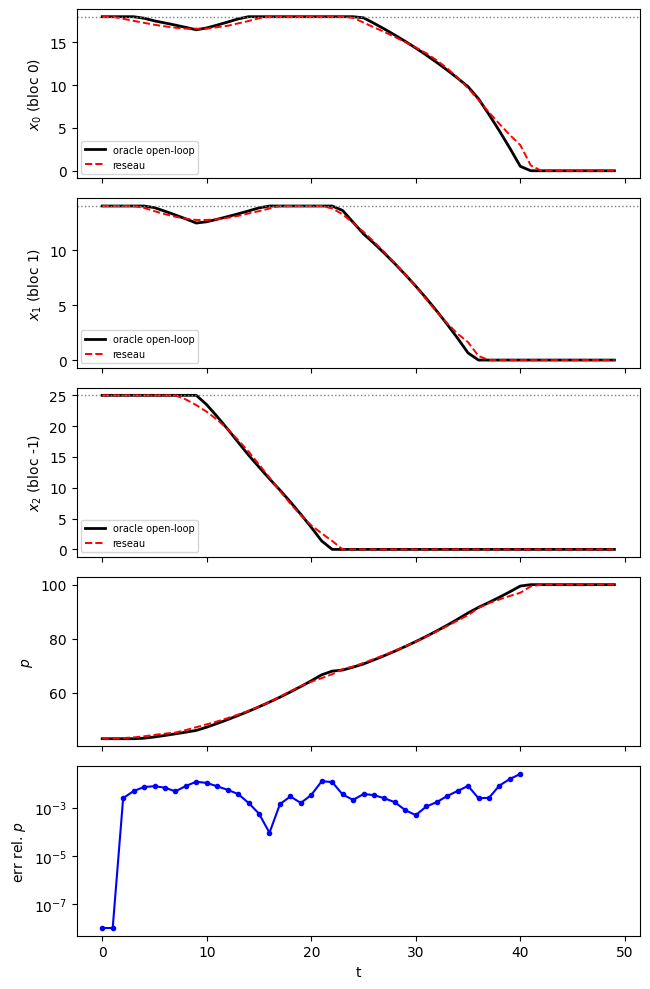


figures -> figs/m3_n3_etageA_rollout.png (+ .npz)
[E] run logue dans runs_m3.csv (8 lignes)

tolerance large ; err_p=2.48e-02 > 1%


/tmp/ipykernel_197820/3839051550.py:1406: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  if os.path.exists(p_csv): df = pd.concat([pd.read_csv(p_csv), df], ignore_index=True)


In [3]:
# M3 : N agents (oligopolistes / cartellistes / frange), T periodes, capacite active, PINN.
#
# ============================================================================
# ETAT DU DOSSIER (post RUN 13a corrige / RUN 13b)
#
# LE CAS N=1 STRATEGIQUE EST CLOS. Benchekroun & Withagen (2012, Games and Economic
# Behavior 76(2), 355-374) demontrent que les issues du jeu cartel-frange en boucle
# ouverte et en boucle fermee COINCIDENT quand la frange est preneuse de prix (jeu a la
# Salant 1976). La litterature sur l'incoherence temporelle porte sur l'equilibre de von
# STACKELBERG, ou le cartel internalise la reaction INSTANTANEE de la frange (dx_f/dx_c).
# Ce fichier implemente h_i = p - beta*Lam_i - c_i - delta*lambda'_i : du Nash-Cournot.
# Donc feedback = 0 a N=1 strategique est le resultat ATTENDU. Verifie deux fois :
#   - PINN, STEP 8 : |feedback_0|/lambda_0 = 0.02% (etages A et B).
#   - Grille MPE corrigee : le sentier du CARTEL est reproduit a l'identique
#     (20/20 partout, 17.3/17.3 a t=30, 9.5/9.6 a t=35).
# Le "29.39% d'ecart CL/OL" du RUN 13a initial etait un ARTEFACT NUMERIQUE PUR : il
# oscillait entre 8% et 50% selon ng, et le residu de la boucle de meilleures reponses
# valait 30 barils (la capacite entiere de la frange) au 40e balayage.
#
# CAUSE RACINE, valable pour toute grille de ce type : lambda etait lu par difference
# finie sur un interpolant BILINEAIRE, dont la pente est constante par cellule. La carte
# de meilleure reponse devient une fonction en escalier et l'iteration cycle. Diagnostic
# decisif : le test MONO-AGENT (S_j = 0 pour tous les rivaux -> le jeu disparait, MPE ==
# controle optimal, l'oracle open-loop est la verite EXACTE). L'ancienne methode y donnait
# 100% d'erreur a ng=400. En 1D, la FOC avec derivee ANALYTIQUE d'un interpolant C1
# (PCHIP) tombe a 0.04% avec convergence monotone. En N>=2 le schema stable est la
# MAXIMISATION DIRECTE sur une grille d'actions, qui ne touche jamais a la derivee de
# l'interpolant. C'est ce qui est implemente ici.
#
# CE QUI CHANGE DANS CETTE VERSION
#   1. Calibration par defaut : N=3, DEUX oligopolistes singletons + une frange.
#      C'est la ou la divergence CL/OL existe. Benchekroun & Withagen etablissent aussi
#      que le Nash en boucle fermee a frange nombreuse ne converge PAS vers le
#      cartel-frange en boucle fermee : le raccourci "frange price-taker" n'est pas
#      innocent en boucle fermee, et personne ne l'a quantifie avec capacite liante.
#      Calibration retenue (balayage de l'oracle, cout nul) :
#        costs=10,12,20  kappas=18,14,25  stocks=620,410,400  blocs=0,1,-1
#        -> mu=(12.64,13.94,16.74), epuisement exact, actif t<=40/35/21,
#           kappa liante 15/12/10, et 20 DATES OU LES DEUX STRATEGIQUES SONT
#           SIMULTANEMENT INTERIEURS. C'est le support de J[k,j] != 0.
#   2. Grille MPE generalisee a N = 2 ou 3, decision par maximisation directe.
#   3. STEP 1b : ecran de calibration (verifie le recouvrement des regimes interieurs).
#   4. STEP 9 : BATTERIE DE COHERENCE SANS ORACLE. C'est le coeur de cette version.
#
# POURQUOI STEP 9. L'oracle open-loop reste exact a tout N : les etages A et B gardent
# leur validateur. Ce qui manque, c'est une verite pour l'etage C. La reponse n'est pas
# une grille plus fine mais le TEST DE DEVIATION A UN COUP : un profil de strategies est
# un equilibre si et seulement si aucun joueur ne gagne a devier une fois puis a reprendre
# sa politique. Cela ne demande AUCUN oracle, aucune grille, et c'est la definition meme
# de l'equilibre. Le meme test avec les rivaux GELES sur la trajectoire de reference donne
# la condition OPEN-LOOP ; avec les rivaux qui REPONDENT via leur politique, la condition
# MARKOVIENNE. L'ecart entre les deux gains EST la divergence CL/OL, mesuree sans grille.
#
# LE MODE D'ECHEC A NE PLUS REPETER. Ce n'est jamais le solveur : c'est de mesurer avec
# un instrument qu'on n'a pas d'abord valide contre une verite. COH, CROSS_NEG, err_p brut,
# lam_deflate et la grille MPE ont tous produit un faux diagnostic pour cette raison.
# REGLE : tout nouvel objet (gV hors-diagonale, J, feedback, grille) doit passer son
# propre test de verite AVANT de servir de mesure. C'est ce que STEP 9 systematise.
# ============================================================================
#
# Trois etages (toggles cross / sob_off), a lancer DANS CET ORDRE :
#   A. cross=False, sob_off=False -> systeme OPEN-LOOP a N joueurs.
#      L'oracle generalise est la VERITE, il doit etre retrouve.
#      Test de deviation attendu nul en mode FREEZE.
#   B. cross=False, sob_off=True  -> on entraine le gradient COMPLET dV_i/dS_j. Residu
#      mathematiquement redondant : l'equilibre ne bouge pas, l'oracle doit encore etre
#      retrouve. C'est le test du residu lui-meme.
#   C. cross=True,  sob_off=True  -> MPE. Le reseau s'ecarte de l'oracle open-loop et cet
#      ecart EST le resultat. L'oracle devient comparateur.
#      Test de deviation attendu nul en mode NON-FREEZE.
#
# COUT : sob_off/cross demandent 3*NAG backward passes avec create_graph.

import os, sys, time, json
import numpy as np
import torch, torch.nn as nn
import torch.nn.functional as F

torch.set_num_threads(4)
torch.set_default_dtype(torch.float64)

######## STEP 0  config
CFG = dict(
    tag="m3_n3_etageA", seed=0,
    sampler="mix",           # "mix" = tube+uniforme (defaut) | "tube_oracle" = bras degrade

    # --- ECONOMIE : listes paralleles, un element par AGENT -------------------
    # DEFAUT N=3 : deux oligopolistes singletons (blocs 0 et 1) + une frange (-1).
    #   20 dates ou a0 ET a1 sont simultanement interieurs -> J != 0 -> feedback non nul.
    # Non-regression M2 (N=2) : costs="10,20" kappas="20,30" stocks="700,450" blocs="0,-1"
    #   -> CLOS : coincidence CL/OL demontree et verifiee. Utile comme test de socle.
    costs  = "10,12,20",
    kappas = "18,14,25",
    stocks = "620,410,400",
    blocs  = "0,1,-1",       # entiers distincts = oligopolistes ; egaux = meme cartel ; -1 = frange
    alpha=100.0, beta=1.0, r=0.05, T=50,

    # --- ETAGES ---------------------------------------------------------------
    sob_off=False,           # entrainer dV_i/dS_j hors-diagonale
    cross=False,             # termes croises dans l'enveloppe (=> MPE). Exige sob_off.

    # --- TOGGLES DE BISSECTION (RUN 9). Ne jamais en bouger deux dans le meme run. ---
    sob_ok_mask=True,        # SOB_OK = lignes canoniques de A (False -> ones : RUN 6, casse)
    G_in_V=True,             # facteur G(t) dans la construction de V
    norm_G_bell=True,        # R_bell divise par G_t
    norm_G_lam=True,         # R_env/R_sob/R_lam divises par G_t
    vref_per_agent=False,    # VREF vectoriel alpha*S0_i au lieu du scalaire alpha*max(S0)

    # RUN 12 : cible Monte-Carlo TD(1) pour V, sur le bras TUBE PUR uniquement. VALIDE.
    #   SURVEILLANCE : field_int_med s'est degrade 0.913 -> 1.426 -> 1.770 depuis son
    #   introduction, pendant que les metriques de sentier s'amelioraient. Signature de
    #   surajustement au tube. A N=3 le champ est l'argument meme du PINN : si la
    #   degradation continue, tester use_vmc=False en isolation.
    use_vmc=True, w_vmc=1.0,

    # --- ETAPE 1b : ecran de calibration (cout : quelques secondes, aucun entrainement) ---
    run_screen=True,

    # --- ETAPE 2 : grille MPE (N = 2 ou 3). Cout ~O(ng^N * nx * nbr * T). --------
    #   N=2 : ng=160 nx=31 -> ~30 s.   N=3 : ng=32 nx=15 -> ~2-4 min.
    #   La grille n'est PAS le validateur principal (sa precision plafonne vers 0.5%
    #   en 2D et bien au-dela en 3D). C'est STEP 9 qui valide. La grille sert de
    #   controle croise independant.
    run_mpe_grid=False, mpe_ng=32, mpe_nx=15, mpe_nbr=6,

    # --- reseau ---------------------------------------------------------------
    width=128, emb_dim=16, depth=3,

    # --- loss / sampler -------------------------------------------------------
    w_sob=0.01, w_sob_off=0.1, frac_unif=0.05, frac_gauss=0.25, frac_decor=0.0, box=1.25,
    buf_paths=64, buf_every=50, buf_lo=0.70, buf_hi=1.25,

    # --- entrainement ---------------------------------------------------------
    iters=30000, batch=512, lr=1e-3, lbfgs_outer=3,
    # NOTE : a l'etage B, L-BFGS rend systematiquement loss_pre == loss_post (Wolfe
    # echoue au premier pas) et coute ~300 s pour rien. Mettre lbfgs_outer=0 des que
    # sob_off=True. A l'etage A il travaille reellement, on le garde.

    diag_every=0,            # instrumentation R9bis : decomposition loss + |grad| par residu

    # --- eval -----------------------------------------------------------------
    snap_eps=1e-4, n_field=40, or_nbis=30, or_nouter=15,
    t_decouple="10,20,30", make_figs=True,

    # --- STEP 9 : batterie de coherence SANS ORACLE ---------------------------
    run_step9=True,
    dev_eps_rel=0.15,        # amplitude de deviation, en fraction de la capacite du pas
    dev_n_eps=13,            # points de la grille de deviation (impair : 0 au centre)
    dev_n_dates=5,           # dates sondees
    fd_rel=5e-3,             # pas relatif des differences finies (gV, J)
)

for a in sys.argv[1:]:
    if "=" not in a: continue
    k, v = a.split("=", 1)
    if k not in CFG: continue
    CFG[k] = (v.lower() in ("1", "true")) if isinstance(CFG[k], bool) else type(CFG[k])(v)

alpha, beta, r, T = CFG["alpha"], CFG["beta"], CFG["r"], CFG["T"]
delta = 1.0/(1.0+r)
C_np   = np.array([float(u) for u in CFG["costs"].split(",")])
KAP_np = np.array([float(u) for u in CFG["kappas"].split(",")])
S0_np  = np.array([float(u) for u in CFG["stocks"].split(",")])
BLOC   = np.array([int(u)   for u in CFG["blocs"].split(",")])
NAG = len(C_np)
assert len(KAP_np) == len(S0_np) == len(BLOC) == NAG, "listes d'agents de longueurs differentes"

# masque de conduite : A[i,j] = 1 ssi i et j sont dans le meme bloc (>=0). Frange : ligne nulle.
# cartelliste -> Lambda_i = Q^C (somme du bloc) ; oligopoliste -> Lambda_i = x_i ; frange -> 0.
A_np = np.zeros((NAG, NAG))
for i in range(NAG):
    if BLOC[i] < 0: continue
    for j in range(NAG):
        if BLOC[j] == BLOC[i]: A_np[i, j] = 1.0
IS_FRINGE = BLOC < 0

# SOB_OK : masque de R_lam SEULEMENT (l'identite dV_i/dS_i = lambda_i). Cette identite
# n'est valide que si coef[i,i] = 0, c'est-a-dire pour un OLIGOPOLISTE SINGLETON a
# l'optimum interieur (theoreme de l'enveloppe : le terme de choix propre s'annule).
#   singleton interieur : coef_ii = p - c_i - beta*x_i - delta*GV2_ii = 0
#   cartelliste         : coef_ii = beta*(Q^C - x_i) != 0
#   frange              : coef_ii = -beta*x_f        != 0
# R_sob, l'enveloppe universelle derivee de Bellman, n'a jamais eu de masque et n'en veut
# pas. RUN 6 (SOB_OK = ones) imposait deux equations incompatibles au meme objet. Ne pas
# y revenir.
SOB_OK = (torch.tensor((A_np == np.eye(NAG)).all(1).astype(float))
          if CFG["sob_ok_mask"] else torch.ones(NAG))

if CFG["cross"] and not CFG["sob_off"]:
    print("[!] cross=True force sob_off=True (le feedback depend de dV_i/dS_k)")
    CFG["sob_off"] = True

torch.manual_seed(CFG["seed"]); np.random.seed(CFG["seed"])
A    = torch.tensor(A_np)
COST = torch.tensor(C_np)
KAP  = torch.tensor(KAP_np)
S0V  = torch.tensor(S0_np)
DEN  = beta*(1.0 + torch.diagonal(A))   # pas de Newton du clamp : dh_i/dx_i = -beta(1+A_ii).
                                        # Ce n'est PAS un parametre de conduite : la conduite
                                        # est entierement dans Lambda = A x.
OFF  = 1.0 - torch.eye(NAG)             # masque k != i
VREF = (alpha*S0V) if CFG["vref_per_agent"] else (alpha*S0_np.max())
LREF = alpha                            # rente bornee par le choke price
XREF = torch.minimum(KAP, S0V)          # echelle des QUANTITES (pas des stocks)
W_SOB, W_SOFF = CFG["w_sob"], CFG["w_sob_off"]
FRAC_UNIF, FRAC_GAUSS, BOX, SNAP_EPS = CFG["frac_unif"], CFG["frac_gauss"], CFG["box"], CFG["snap_eps"]

# STRAT[i] = 1 pour un agent STRATEGIQUE (ligne non nulle dans A), 0 pour la frange.
# Une frange preneuse de prix n'a pas de terme de feedback. VALIDE au RUN 13b.
STRAT = torch.tensor((~IS_FRINGE).astype(float))
STRAT_IDX = [i for i in range(NAG) if not IS_FRINGE[i]]

print(f"STEP 0 : {NAG} agents | blocs={list(BLOC)} | strategiques={STRAT_IDX} "
      f"| frange={list(np.nonzero(IS_FRINGE)[0])}")
print(f"         A =\n{A_np.astype(int)}")

def growth_t(ti):
    """G(t) = (1+r)^(t-(T-1)) : vaut 1 a la derniere date de decision, ~0.09 en t=0.
       C'est EXACTEMENT le facteur de croissance de Hotelling : lambda_i(t) = mu_i(1+r)^t.
       Ecrire lam = softplus(l)*LREF*G ramene donc la cible de la tete co-etat a une
       CONSTANTE en t le long du sentier. Preconditionnement exact, adosse a la theorie."""
    return (1.0+r)**(ti.double() - (T-1))

######### STEP 1  oracle open-loop a N joueurs   [INCHANGE, valide analytiquement]

# rentes initiales mu_i, lambda_i(t) = mu_i*(1+r)^t. A rentes donnees, chaque periode est un
# equilibre STATIQUE a couts effectifs c_i + lambda_i(t) (gere les coins nativement).
# On cherche N scalaires au lieu de N*T inconnues et 3^(N*T) regimes.
# Trois boucles : (a) point fixe de meilleures reponses intra-periode, vectorise sur t ;
# (b) methode de tir : bissection sur mu_i pour atteindre Sigma_t x_i = S_i (le cumul est
# strictement decroissant en mu_i) ; (c) Gauss-Seidel sur les agents, car les mu sont
# couples par le prix. Cout LINEAIRE en N, contre O(nbis^N) pour des bissections imbriquees.
NITER_BR = 60

def static_period_N(ceff, kap):
    """ceff [T_,NAG] -> x [T_,NAG]. h_i = 0 donne
       x_i = [alpha - c_i - beta*somme_{j!=i}(1+A_ij)x_j] / (beta*(1+A_ii)), puis clip [0,kappa_i]."""
    x = np.zeros_like(ceff)
    idx = np.arange(NAG)
    for _ in range(NITER_BR):
        for i in range(NAG):
            o = idx[idx != i]
            num = alpha - ceff[:, i] - beta*((1.0 + A_np[i, o])*x[:, o]).sum(1)
            x[:, i] = np.clip(num/(beta*(1.0 + A_np[i, i])), 0.0, kap[i])
    return x

def totals_N(mu, T_, kap, C=None):
    C = C_np if C is None else C
    g = (1.0+r)**np.arange(T_)
    return static_period_N(C[None, :] + mu[None, :]*g[:, None], kap)

def solve_oracle_N(S_, T_, kap=None, nbis=None, nouter=None, C=None):
    kap = KAP_np if kap is None else kap
    nbis = CFG["or_nbis"] if nbis is None else nbis
    nouter = CFG["or_nouter"] if nouter is None else nouter
    mu = np.zeros(NAG); conv = np.inf
    for _ in range(nouter):
        mu_old = mu.copy()
        for i in range(NAG):
            m0 = mu.copy(); m0[i] = 0.0
            if totals_N(m0, T_, kap, C)[:, i].sum() <= S_[i]:   # stock non contraignant
                mu[i] = 0.0; continue
            lo, hi = 0.0, alpha
            for _ in range(nbis):
                m = .5*(lo+hi); mt = mu.copy(); mt[i] = m
                if totals_N(mt, T_, kap, C)[:, i].sum() > S_[i]: lo = m
                else: hi = m
            mu[i] = .5*(lo+hi)
        conv = np.max(np.abs(mu-mu_old))
        if conv < 1e-10: break
    solve_oracle_N.last_conv = float(conv)      # Gauss-Seidel non certifie : on le journalise
    x = totals_N(mu, T_, kap, C)
    return mu, x, alpha - beta*x.sum(1)
solve_oracle_N.last_conv = np.nan

t_or = time.time()
mu_a, xa, pa = solve_oracle_N(S0_np, T, nbis=60, nouter=40)
print(f"STEP 1 oracle ok ({time.time()-t_or:.0f}s) : mu={np.round(mu_a,3)}  "
      f"(convergence Gauss-Seidel {solve_oracle_N.last_conv:.1e})")
for i in range(NAG):
    ai = xa[:, i] > 1e-9
    print(f"  agent {i} (bloc {BLOC[i]:2d}, c={C_np[i]:5.1f}, kap={KAP_np[i]:5.1f}) : "
          f"actif t<={int(np.max(np.nonzero(ai))) if ai.any() else -1}, "
          f"kappa liante {int((xa[:,i]>KAP_np[i]-1e-6).sum())}/{T}, "
          f"cumul {xa[:,i].sum():.1f}/{S0_np[i]:.1f}")
assert np.abs(xa.sum(0) - S0_np).max() < 1e-4, "epuisement viole"
_tlast = int(np.max(np.nonzero(xa.sum(1) > 1e-9)))
assert _tlast < T-1, f"horizon trop court (production encore en t={_tlast})"

# non-regression M2 (N=2 seulement) : l'oracle doit redonner mu=(12.821, 21.757).
if (NAG == 2 and np.allclose(C_np, [10., 20.]) and np.allclose(S0_np, [700., 450.])
        and np.allclose(KAP_np, [20., 30.]) and BLOC[1] < 0):
    assert abs(mu_a[0]-12.821) < 1e-2 and abs(mu_a[1]-21.757) < 1e-2, "oracle N incompatible avec M2"
    print("  [non-regression M2 : mu retrouve]")

SA_T = torch.tensor(S0_np[None, :] - np.concatenate([np.zeros((1, NAG)), np.cumsum(xa, 0)[:-1]], 0))

# regimes, par agent : interieur = ni a zero ni a kappa. C'est la SEULE zone ou lambda_i
# est identifie (ailleurs la FOC est inactive) et la seule ou dx_i/dS_j != 0.
INT = (xa > 1e-6) & (xa < KAP_np[None, :] - 1e-6)

# ============================================================================
# ETAPE 1b : ECRAN DE CALIBRATION. Cout nul, aucun entrainement.
#   Le feedback markovien vaut somme_{k!=i} coef[i,k]*J[k,j] avec J[k,j] = dx_k/dS_j.
#   J[k,j] est identiquement NUL si l'agent k est a un coin (x_k = 0 ou x_k = kappa_k) :
#   sa decision ne repond alors plus a l'etat. Il faut donc des dates ou DEUX AGENTS
#   STRATEGIQUES sont SIMULTANEMENT INTERIEURS, sinon l'etage C n'a rien a mesurer et
#   l'etage B entraine des objets multiplies par zero.
#   C'est exactement ce qui s'est passe a la calibration M2 : a0 colle a kappa pendant
#   toute la vie de la frange -> J[1,0] = 0 -> feedback = 0 par construction.
#   CRITERE : au moins ~10 dates de recouvrement pour une paire strategique.
# ============================================================================
def screen_regimes(x, kap=None):
    kap = KAP_np if kap is None else kap
    itr = (x > 1e-6) & (x < kap[None, :] - 1e-6)
    out = {}
    for a_ in range(len(STRAT_IDX)):
        for b_ in range(a_+1, len(STRAT_IDX)):
            i, j = STRAT_IDX[a_], STRAT_IDX[b_]
            out[(i, j)] = int((itr[:, i] & itr[:, j]).sum())
    return itr, out

if CFG["run_screen"]:
    _itr, _ov = screen_regimes(xa)
    print("\nETAPE 1b  ecran de calibration")
    for i in range(NAG):
        print(f"  agent {i} : interieur sur {int(_itr[:,i].sum()):2d} dates "
              f"| kappa {int((xa[:,i]>KAP_np[i]-1e-6).sum()):2d} | zero {int((xa[:,i]<=1e-6).sum()):2d}")
    if _ov:
        for (i, j), n in _ov.items():
            flag = "OK" if n >= 10 else "INSUFFISANT (feedback non identifie)"
            print(f"  recouvrement interieur strategiques ({i},{j}) : {n:2d} dates  -> {flag}")
    else:
        print("  [!] UN SEUL agent strategique : la coincidence CL/OL est un THEOREME")
        print("      (Benchekroun & Withagen 2012). L'etage C n'a rien a mesurer ici.")
        print("      Passer a >= 2 strategiques, p.ex. blocs='0,1,-1'.")

# ============================================================================
# ETAPE 2 : GRILLE MPE (induction retrograde, N = 2 ou 3). Independante de PyTorch.
#
#   DECISION INTRA-PERIODE : maximisation DIRECTE, sans aucune derivee de V.
#     obj_i(x_i) = (alpha - c_i - beta*somme_{j!=i}(1+A_ij)x_j)*x_i
#                  - (beta(1+A_ii)/2)*x_i^2 + delta*V_i(S - x)
#     d(obj_i)/dx_i = p - beta*Lambda_i - c_i - delta*dV_i/dS_i  =  h_i, EXACTEMENT,
#     et pour toute conduite. Frange : A_ii = A_ij = 0 -> derivee = p - c_f - delta*lam_f,
#     la condition de preneur de prix. C'est un potentiel, pas le profit : c'est ce qui
#     permet de traiter la frange par un argmax alors qu'elle ne maximise pas son profit.
#   Aucun terme de feedback a coder : il est contenu dans le V calcule, puisque
#   sigma_{-i}(S) depend de l'etat.
#
#   PORTE D'ACCEPTATION OBLIGATOIRE : le TEST MONO-AGENT. En mettant tous les stocks
#   rivaux a zero, le jeu disparait, MPE == controle optimal, et l'oracle open-loop est
#   la verite EXACTE. Toute difference est de l'erreur numerique pure. Sans ce test on ne
#   sait pas si un ecart CL/OL est de l'economie ou du bruit.
#   PRECISION ATTEINTE : ~0.5% en 2D a ng=160. Ce plafond vient de l'interpolation
#   multilineaire (pente en escalier). La grille est donc un CONTROLE CROISE, pas le
#   validateur principal : c'est STEP 9 qui valide.
# ============================================================================
def _interp_ml(Z, coords, grids):
    """Interpolation multilineaire sur grille reguliere. Z de forme (ng,)*N."""
    N = len(grids); ng = Z.shape[0]
    idx, fr = [], []
    for k in range(N):
        d = grids[k][1]
        aa = np.clip(coords[k]/d, 0.0, ng-1-1e-9)
        i0 = aa.astype(np.intp); idx.append(i0); fr.append(aa-i0)
    out = 0.0
    for corner in range(1 << N):
        w = 1.0; ii = []
        for k in range(N):
            b = (corner >> k) & 1
            w = w*(fr[k] if b else (1.0-fr[k]))
            ii.append(idx[k]+b)
        out = out + w*Z[tuple(ii)]
    return out

def mpe_grid(ng=None, nx=None, nbr=None):
    ng = ng or CFG["mpe_ng"]; nx = nx or CFG["mpe_nx"]; nbr = nbr or CFG["mpe_nbr"]
    assert NAG <= 3, "grille MPE : N <= 3 (le cout explose au-dela ; c'est l'argument du PINN)"
    grids = [np.linspace(0.0, S0_np[i], ng) for i in range(NAG)]
    G = np.meshgrid(*grids, indexing="ij")
    shp = G[0].shape
    V = [np.zeros(shp) for _ in range(NAG)]
    XPOL = np.zeros((T, NAG) + shp)
    u = np.linspace(0.0, 1.0, nx); resid = 0.0
    for t in reversed(range(T)):
        if t == T-1:
            # derniere date de decision : aucune continuation, on extrait tout le possible.
            # A ecrire explicitement : interpoler un tableau de zeros n'est pas neutre
            # apres clip aux bords, et cela introduisait une pente parasite.
            x = [np.minimum(KAP_np[i], G[i]) for i in range(NAG)]
        else:
            x = [np.zeros(shp) for _ in range(NAG)]
            for it_br in range(nbr):
                xold = [xx.copy() for xx in x]
                for i in range(NAG):
                    hi = np.minimum(KAP_np[i], G[i])
                    cand = u.reshape((1,)*NAG + (nx,))*hi[..., None]
                    coords = []
                    for k in range(NAG):
                        base = (G[i][..., None] - cand) if k == i else (G[k]-x[k])[..., None]
                        coords.append(np.ascontiguousarray(
                            np.broadcast_to(base, cand.shape)).ravel())
                    cont = _interp_ml(V[i], coords, grids).reshape(cand.shape)
                    lin = alpha - C_np[i] - beta*sum((1.0+A_np[i, k])*x[k]
                                                     for k in range(NAG) if k != i)
                    obj = (lin[..., None]*cand - 0.5*beta*(1.0+A_np[i, i])*cand**2
                           + delta*cont)
                    x[i] = np.take_along_axis(cand, obj.argmax(-1)[..., None], -1)[..., 0]
                if it_br == nbr-1:
                    resid = max(resid, max(float(np.abs(x[i]-xold[i]).max()) for i in range(NAG)))
        p = alpha - beta*sum(x)
        Sp = [np.ascontiguousarray(G[i]-x[i]).ravel() for i in range(NAG)]
        if t == T-1:
            V = [(p - C_np[i])*x[i] for i in range(NAG)]
        else:
            V = [(p - C_np[i])*x[i] + delta*_interp_ml(V[i], Sp, grids).reshape(shp)
                 for i in range(NAG)]
        for i in range(NAG): XPOL[t, i] = x[i]
    return grids, XPOL, resid

def mpe_rollout(grids, XPOL, S_init=None):
    """Deroule la politique MPE de la grille depuis S_init. -> X [T,NAG], P [T]."""
    S = np.array(S_init if S_init is not None else S0_np, dtype=float)
    X, P = [], []
    for t in range(T):
        co = [np.array([S[k]]) for k in range(NAG)]
        xt = np.array([float(_interp_ml(XPOL[t, i], co, grids)[0]) for i in range(NAG)])
        xt = np.clip(np.minimum(xt, S), 0.0, None)
        X.append(xt.copy()); P.append(alpha - beta*xt.sum()); S = S - xt
    return np.array(X), np.array(P)

# masque des dates d'extinction (+/-1), reutilise en STEP 5.
_ext = np.zeros(T, dtype=bool)
for i in range(NAG):
    _mi = np.nonzero(xa[:, i] > 1e-9)[0]
    if _mi.size: _ext[max(0, _mi[-1]-1):_mi[-1]+2] = True

MPE = {}
Xcl = Pcl = None
if CFG["run_mpe_grid"] and NAG <= 3:
    _tg = time.time()
    _grids, _XPOL, _rs = mpe_grid()
    # PORTE : verite mono-agent. Rivaux a stock nul -> plus de jeu -> l'oracle est exact.
    _Smono = S0_np.copy()
    for k in range(1, NAG): _Smono[k] = 0.0
    _, _xmo, _pmo = solve_oracle_N(_Smono, T, nbis=60, nouter=40)
    _amo = _xmo[:, 0] > 1e-9
    Xmo, Pmo = mpe_rollout(_grids, _XPOL, _Smono)
    _emp = float(np.abs(Pmo[_amo]-_pmo[_amo]).max()/_pmo.max())
    Xcl, Pcl = mpe_rollout(_grids, _XPOL)
    _a = xa.sum(1) > 1e-6; _keepg = _a & (~_ext)
    _e = np.abs(Pcl[_a]-pa[_a])/pa.max()
    MPE = dict(ng=CFG["mpe_ng"], br_resid=_rs, mono_err_p=_emp,
               gap_p=float(_e.max()),
               gap_p_noext=float(np.abs(Pcl[_keepg]-pa[_keepg]).max()/pa.max()),
               gap_p_q90=float(np.quantile(_e, .90)),
               gap_p0=float(abs(Pcl[0]-pa[0])/pa[0]), cum=Xcl.sum(0).tolist())
    print(f"\nETAPE 2  GRILLE MPE ({time.time()-_tg:.0f}s, ng={CFG['mpe_ng']}, nx={CFG['mpe_nx']})")
    print(f"  PORTE mono-agent (erreur numerique pure) : {_emp:.2%} "
          f"{'OK' if _emp < 5e-3 else '-> plancher de la grille, tout ecart CL/OL en dessous est du bruit'}")
    print(f"  residu BR intra-periode : {_rs:.3f} bbl")
    print(f"  epuisement CL {np.round(Xcl.sum(0),1)} / {S0_np}")
    print("   t  | " + " | ".join(f"a{i} CL/OL" for i in range(NAG)) + " |  p CL/OL")
    for tt in [0, T//5, 2*T//5, 3*T//5, _tlast]:
        s = " | ".join(f"{Xcl[tt,i]:5.1f}/{xa[tt,i]:5.1f}" for i in range(NAG))
        print(f"  {tt:3d} | {s} | {Pcl[tt]:6.2f}/{pa[tt]:6.2f}")
    print(f"  ECART CL/OL : max {MPE['gap_p']:.2%} | hors ext {MPE['gap_p_noext']:.2%} "
          f"| q90 {MPE['gap_p_q90']:.2%} | t=0 {MPE['gap_p0']:.2%}")
    print(f"  A COMPARER au plancher mono-agent {_emp:.2%}. En dessous, ce n'est pas de l'economie.")

#####  STEP 2  reseaux

# un reseau par agent, trois tetes (politique z, valeur w, co-etat l), tronc partage.
# Chaque reseau prend l'etat COMPLET S : c'est la definition du Markov, et c'est ce qui rend
# les derivees croisees dV_i/dS_j et dsigma_k/dS_j calculables par autodiff.
# NOTE DAG : le nombre de reseaux VALEUR utiles = nombre d'agents STRATEGIQUES, pas N.
# La tete valeur de la frange n'est lue par aucune equation une fois STRAT applique ; sa
# tete POLITIQUE, elle, est indispensable (J[f,.] entre dans le feedback des strategiques).
# - ancrage terminal EXACT par 1{t<T}
# - SiLU : le residu Sobolev a besoin de dV/dS non trivial ; le kink est deja dans
#   l'architecture via les min(), donc rien de non lisse a apprendre.
class Net(nn.Module):
    def __init__(s, width, emb_dim, depth):
        super().__init__()
        s.emb = nn.Embedding(T+1, emb_dim)          # T+1 : l'index t=T existe, neutralise par alive
        nn.init.normal_(s.emb.weight, std=0.1)
        layers, d = [], NAG + emb_dim
        for _ in range(depth):
            layers += [nn.Linear(d, width), nn.SiLU()]; d = width
        s.trunk = nn.Sequential(*layers)
        s.head_z = nn.Linear(width, 1); s.head_w = nn.Linear(width, 1); s.head_l = nn.Linear(width, 1)
    def forward(s, S, ti):
        h = s.trunk(torch.cat([S/S0V, s.emb(ti)], dim=-1))
        return s.head_z(h).squeeze(-1), s.head_w(h).squeeze(-1), s.head_l(h).squeeze(-1)

NETS = nn.ModuleList([Net(CFG["width"], CFG["emb_dim"], CFG["depth"]) for _ in range(NAG)])
PARAMS = list(NETS.parameters())

def forward_all(S, ti, snap=False):
    """S:[B,NAG] ti:[B] long -> x, V, lam tous [B,NAG]"""
    z, w, l = [], [], []
    for i in range(NAG):
        zi, wi, li = NETS[i](S, ti); z.append(zi); w.append(wi); l.append(li)
    z = torch.stack(z, -1); w = torch.stack(w, -1); l = torch.stack(l, -1)
    # x = min(min(S,kappa), softplus(z)) : atteint kappa EXACTEMENT (coin superieur franc),
    # garantit 0 <= x <= S par construction. La faisabilite n'est jamais a apprendre.
    x = torch.minimum(torch.minimum(S, KAP), F.softplus(z))
    if snap:                                        # EVAL uniquement (zone morte a l'entrainement)
        x = torch.where(x < SNAP_EPS, torch.zeros_like(x), x)
    alive = (ti < T).double().unsqueeze(-1)
    G = growth_t(ti).unsqueeze(-1) if CFG["G_in_V"] else torch.ones_like(alive)
    # V libre. Les deux ancrages testes sont morts et ne doivent pas revenir :
    #   * (S/S0V) : annule V_i et TOUS ses gradients sur l'hyperplan S_i=0, donc detruit
    #     l'ancre terminale de la chaine arriere de R_sob/R_soff.
    #   * (* S)   : impose V_i = lambda_i*S_i, i.e. courbure nulle en S, alors que la
    #     courbure est l'objet meme que l'etage B doit apprendre (mesure : facteur 1.7).
    V   = alive*F.softplus(w) * VREF*G
    lam = alive*F.softplus(l)*LREF*G
    return x, V, lam

#####  STEP 3  residus

# FOC -> politique ; enveloppe -> co-etat ; Bellman -> valeur ; Sobolev -> lie les deux.
# Chaque agent n'a que SA PROPRE FOC. Ce qui fabrique l'equilibre : p n'est PAS detache
# (le gradient du residu de i remonte dans les reseaux de tous les autres) et chaque reseau
# lit l'etat complet. Tout le reste est de la regression supervisee sur cible bootstrap
# detachee : schema semi-gradient.
# R_foc est EXACT et non approche : h_i etant affine en x_i de pente -beta(1+A_ii), le pas
# x + h/DEN atterrit sur la racine exacte, et le clamp projette. R_foc = 0 <=> x est la
# meilleure reponse contrainte exacte etant donne (p, Lambda, lambda').
def residuals(S, ti):
    S = S.detach().requires_grad_(True)
    x, V, lam = forward_all(S, ti)
    p = alpha - beta*x.sum(-1, keepdim=True)
    Lam = x @ A.T
    S2 = S - x
    _, V2, lam2 = forward_all(S2, ti+1)
    lam2d = lam2.detach()
    cap = torch.minimum(S, KAP)

    h = p - beta*Lam - COST - delta*lam2d
    R_foc = x - torch.clamp(x + h/DEN, torch.zeros_like(x), cap)

    gV = torch.stack([torch.autograd.grad(V[:, i].sum(), S, create_graph=True)[0]
                      for i in range(NAG)], dim=1)

    # Multiplier par 0.0 preserve le lien au graphe d'autodifferenciation
    feedback = x * 0.0
    R_soff = gV * 0.0
    R_sob = x * 0.0

    if CFG["sob_off"]:
        J   = torch.stack([torch.autograd.grad(x[:, k].sum(), S, create_graph=True)[0]
                           for k in range(NAG)], dim=1)

        # --------------------------------------------------------------------
        # OPTION : J analytique par theoreme des fonctions implicites.
        #   dh_i/dS_j = 0 avec h_i = p - beta*Lam_i - c_i - delta*lambda_i(S-x) donne
        #     [delta*L - beta*B] J = delta*L,   L[i,k] = dlambda'_i/dS'_k,  B = 1 + A
        #   J ne depend alors que des derivees PREMIERES de la tete lambda (supervisee par
        #   R_env, cible dure) au lieu des derivees de la tete z (supervisee seulement
        #   implicitement via R_foc). Verification N=1, A=1 : J = |dL|/(|dL|+2beta) dans (0,1).
        #   BUG CORRIGE : la reduction masquait les COLONNES contraintes mais pas les
        #   LIGNES, donc l'equation d'un agent a un coin contaminait la resolution des
        #   lignes libres avant d'etre ecrasee par Jfix. Masquer LES DEUX.
        #   RESERVE : ce J est le J D'EQUILIBRE ; hors equilibre (pendant l'entrainement)
        #   il differe du dx/dS effectif du reseau, donc la cible de R_soff devient
        #   partiellement heterogene a l'objet regresse.
        #   ORDRE : n'activer qu'APRES le diagnostic 9f (magnitude de gV).
        # L2 = torch.stack([torch.autograd.grad(lam2[:, i].sum(), S2, create_graph=True)[0]
        #                   for i in range(NAG)], dim=1)
        # Mj   = delta*L2 - beta*(1.0 + A)
        # Jfix = torch.zeros_like(Mj)
        # at_k = (x >= KAP - 1e-6)
        # at_S = (x >= S   - 1e-6)
        # Jfix = torch.where(at_S.unsqueeze(-1), torch.eye(NAG).expand_as(Mj), Jfix)
        # free = (~(at_k | at_S)).double()                       # [B,NAG]
        # rhs  = delta*L2 - torch.einsum('bik,bkj->bij', Mj*(1.0-free).unsqueeze(1), Jfix)
        # Mred = free.unsqueeze(-1)*Mj*free.unsqueeze(1) + torch.diag_embed(1.0-free)
        # J    = torch.linalg.solve(Mred, rhs)*free.unsqueeze(-1) + Jfix
        # --------------------------------------------------------------------

        GV2 = torch.stack([torch.autograd.grad(V2[:, i].sum(), S2, create_graph=True)[0]
                           for i in range(NAG)], dim=1)
        # coef[i,k] = d(pi_i)/d(x_k) - delta*dV_i'/dS_k'
        #           = -beta*x_i - delta*GV2[i,k]  (k!=i)   |   + (p - c_i)  (k=i)
        coef = -beta*x.unsqueeze(-1) - delta*GV2 + torch.diag_embed(p - COST)

        # M_full  : dV_i/dS_j = delta*GV2[i,j] + M_full[i,j]. Somme sur TOUS les k.
        # M_cross : somme sur k != i seulement. Le terme diagonal coef_ii*J_ii n'est PAS du
        #           feedback, c'est le coin de conduite.
        M_full  = torch.einsum('bik,bkj->bij', coef,     J)
        M_cross = torch.einsum('bik,bkj->bij', coef*OFF, J)

        feedback = torch.diagonal(M_cross, dim1=1, dim2=2)
        R_soff   = (gV - (delta*GV2 + M_full).detach())*OFF
        # P-C : cette cible est AUTO-REFERENTIELLE (construite depuis le V du reseau
        # lui-meme, ancre terminale degeneree a 0). CONFIRME EMPIRIQUEMENT au RUN 13b :
        # a1 dV/dS a 28.91% contre un ecart theorique attendu de 2.5-5%. R_sob converge
        # vers un point fixe auto-coherent mais faux la ou il est le seul residu actif.
        # Attaque : cibles pathwise mesurees (STEP 9f -> R_gv).
        R_sob = torch.diagonal(gV, dim1=1, dim2=2) - (delta*torch.diagonal(GV2, dim1=1, dim2=2)
                                            + torch.diagonal(M_full, dim1=1, dim2=2)).detach()

        # Une frange PRENEUSE DE PRIX n'a pas de terme de feedback. Une fois feedback_f = 0,
        # GV2[f,:] n'entre plus dans aucune equation. VALIDE au RUN 13b.
        R_soff   = R_soff * STRAT.view(1, -1, 1)
        feedback = feedback * STRAT

    bind = (x >= KAP - 1e-4).detach()
    tgt = torch.where(bind, delta*lam2d,
                      torch.maximum(p.detach()-beta*Lam.detach()-COST, delta*lam2d))
    # Injection du MPE : UNE ligne. Le feedback entre dans la cible du CO-ETAT, puis se
    # propage a la politique via le terme delta*lambda' de la FOC. Correct dans les deux
    # branches : en zone kappa J_ii = 0, a l'interieur coef_ii = 0 pour un singleton, donc
    # dV_i/dS_i = delta*lambda'_i + feedback_i dans les deux cas.
    if CFG["cross"]: tgt = tgt + feedback.detach()
    R_env = lam - tgt

    R_bell = V - ((p.detach()-COST)*x.detach() + delta*V2.detach())

    R_lam = (torch.diagonal(gV, dim1=1, dim2=2) - lam) * SOB_OK

    return R_foc, R_env, R_bell, R_sob, R_soff, R_lam, V

def loss_from_res(R, ti, Vtgt=None, msk=None, parts=False):
    # UNE loss, somme sur tous les agents, un seul optimiseur conjoint.
    R_foc, R_env, R_bell, R_sob, R_soff, R_lam, V = R
    G_t = growth_t(ti).unsqueeze(-1)
    GB = G_t if CFG["norm_G_bell"] else torch.ones_like(G_t)
    GL = G_t if CFG["norm_G_lam"]  else torch.ones_like(G_t)
    c_foc  =        ((R_foc /XREF      )**2).sum(-1)
    c_env  =        ((R_env /(LREF*GL) )**2).sum(-1)
    c_bell =        ((R_bell/(VREF*GB) )**2).sum(-1)
    c_sob  = W_SOB *((R_sob /(LREF*GL) )**2).sum(-1)
    c_lam  = W_SOB *((R_lam /(LREF*GL) )**2).sum(-1)
    L = c_foc + c_env + c_bell + c_sob + c_lam
    c_soff = torch.zeros_like(L)
    if CFG["sob_off"]:
        c_soff = W_SOFF*((R_soff/(LREF*GL.unsqueeze(-1)))**2).sum((-1, -2))
        L = L + c_soff

    # Cible Monte-Carlo TD(1) pour V, sur le tube. R_bell est un residu a UN pas : il peut
    # etre minuscule pendant que V derive de 25% (V est un bootstrap a 20-40 pas avec une
    # unique ancre en T). Le buffer fait deja 64 rollouts complets : la cible est gratuite,
    # exacte, sans oracle, et valide a l'etage C (V^MC est la valeur de la politique
    # COURANTE, quelle qu'elle soit). msk = 1 uniquement sur le bras tube pur.
    # ATTENTION : STEP 6 compare V_net(S0,0) au profit du rollout depuis S0, soit
    # exactement l'objet regresse ici -> Bellman MC devient QUASI-TAUTOLOGIQUE.
    c_vmc = torch.zeros_like(L)
    if CFG["use_vmc"] and (Vtgt is not None) and (msk is not None):
        c_vmc = CFG["w_vmc"]*(((V - Vtgt.detach())/(VREF*GB))**2).sum(-1)*msk
        L = L + c_vmc

    if parts:
        d = dict(foc=c_foc, env=c_env, bell=c_bell, sob=c_sob, lam=c_lam,
                 soff=c_soff, vmc=c_vmc)
        return L.mean(), {k: v.mean().item() for k, v in d.items()}
    return L.mean()

# normes de gradient par residu. Sans ces chiffres on pilote a l'aveugle.
def grad_norms(Sb, tb, Vtgt=None, msk=None):
    R = residuals(Sb, tb)
    G_t = growth_t(tb).unsqueeze(-1)
    GB = G_t if CFG["norm_G_bell"] else torch.ones_like(G_t)
    GL = G_t if CFG["norm_G_lam"]  else torch.ones_like(G_t)
    comps = dict(
        foc  =        ((R[0]/XREF     )**2).sum(-1).mean(),
        env  =        ((R[1]/(LREF*GL))**2).sum(-1).mean(),
        bell =        ((R[2]/(VREF*GB))**2).sum(-1).mean(),
        sob  = W_SOB *((R[3]/(LREF*GL))**2).sum(-1).mean(),
        lam  = W_SOB *((R[5]/(LREF*GL))**2).sum(-1).mean(),
    )
    if CFG["sob_off"]:
        comps["soff"] = (W_SOFF*((R[4]/(LREF*GL.unsqueeze(-1)))**2).sum((-1, -2))).mean()
    if CFG["use_vmc"] and (Vtgt is not None) and (msk is not None):
        comps["vmc"] = (CFG["w_vmc"]*(((R[6]-Vtgt.detach())/(VREF*GB))**2).sum(-1)*msk).mean()
    out = {}
    for k, v in comps.items():
        if float(v) == 0.0: out[k] = 0.0; continue
        g = torch.autograd.grad(v, PARAMS, retain_graph=True, allow_unused=True)
        out[k] = float(torch.sqrt(sum((gi**2).sum() for gi in g if gi is not None)))
    return out

##### STEP 4  sampler + entrainement

# tube (buffer de la politique COURANTE : voisinage transverse, force de rappel du rollout)
# + petit ancrage uniforme (structure globale). Le tube-oracle a bruit nul ne donnait aucun
# champ transverse => loss 1e-6 et trajectoire fausse a 16%.
# LA LOSS NE VALIDE RIEN : une loss 65x pire a battu l'autre d'un facteur 2.5 sur le rollout.
# A N grand l'ancrage uniforme couvre de moins en moins (volume exponentiel) : c'est le TUBE
# qui rend le DEQN faisable la ou une grille ne l'est pas.
_BUF = None
_VBUF = None
def refresh_buffer(n=None):
    global _BUF, _VBUF
    n = n or CFG["buf_paths"]
    with torch.no_grad():
        S = (CFG["buf_lo"] + (CFG["buf_hi"]-CFG["buf_lo"])*torch.rand(n, NAG))*S0V
        SS, TT, XX, PP = [], [], [], []
        for t in range(T):
            ti = torch.full((n,), t, dtype=torch.long)
            SS.append(S.clone()); TT.append(ti)
            x, _, _ = forward_all(S, ti)
            XX.append(x.clone()); PP.append(alpha - beta*x.sum(-1, keepdim=True))
            S = S - x
        _BUF = (torch.cat(SS, 0), torch.cat(TT, 0), n)
        # accumulation ARRIERE du profit actualise le long du rollout DEJA calcule.
        # V^MC_i(S_t,t) = somme_{s>=t} delta^(s-t) (p_s - c_i) x_is , tronquee en T.
        Vmc, VV = torch.zeros(n, NAG), [None]*T
        for t in reversed(range(T)):
            Vmc = (PP[t] - COST)*XX[t] + delta*Vmc
            VV[t] = Vmc.clone()
        _VBUF = torch.cat(VV, 0)

def sample_states(B):
    if CFG["sampler"] == "tube_oracle":
        idx = torch.randint(0, T, (B,))
        return SA_T[idx], idx, torch.zeros(B, NAG), torch.zeros(B)

    n_u = int(CFG["frac_unif"] * B)
    n_j = int(CFG["frac_gauss"] * B)
    n_d = int(CFG.get("frac_decor", 0.0) * B)
    n_b = B - n_u - n_j - n_d

    S_u = torch.rand(n_u, NAG) * S0V * BOX                      # 1. global uniforme
    t_u = torch.randint(0, T, (n_u,))

    idx_j = torch.randint(0, _BUF[0].shape[0], (n_j,))          # 2. jitter local
    S_j = torch.clamp(_BUF[0][idx_j] + torch.randn(n_j, NAG) * 0.05 * S0V, min=0.0)
    t_j = _BUF[1][idx_j]

    idx_b = torch.randint(0, _BUF[0].shape[0], (n_b,))          # 3. tube pur
    S_b = _BUF[0][idx_b]; t_b = _BUF[1][idx_b]

    # 4. bras decorrelant (brise la collinearite S_0 <-> t). Le confondant est ETABLI mais
    # ce bras ne le casse pas : la cible de gV[i,j] est construite depuis le V du reseau
    # lui-meme. Point fixe auto-referentiel, qu'aucun echantillonnage ne casse.
    # -> frac_decor=0.0 par defaut ; le bras reste inerte mais present.
    idx_d = torch.randint(0, _BUF[0].shape[0], (n_d,))
    S_d = _BUF[0][idx_d].clone()
    agent_idx = torch.randint(0, NAG, (n_d,))
    if n_d: S_d[torch.arange(n_d), agent_idx] = torch.rand(n_d) * S0V[agent_idx] * BOX
    t_d = _BUF[1][idx_d]

    # la cible MC n'est VALIDE QUE sur le bras 3 (tube pur, etat non perturbe).
    Vt = torch.cat([torch.zeros(n_u, NAG), torch.zeros(n_j, NAG),
                    (_VBUF[idx_b] if _VBUF is not None else torch.zeros(n_b, NAG)),
                    torch.zeros(n_d, NAG)], 0)
    mk = torch.cat([torch.zeros(n_u), torch.zeros(n_j),
                    torch.ones(n_b),  torch.zeros(n_d)], 0)
    return (torch.cat([S_u, S_j, S_b, S_d], 0), torch.cat([t_u, t_j, t_b, t_d], 0), Vt, mk)

print(f"\nSTEP 4 : Adam (NAG={NAG}, cross={CFG['cross']}, sob_off={CFG['sob_off']}, "
      f"vmc={CFG['use_vmc']})...")
opt = torch.optim.Adam(PARAMS, lr=CFG["lr"])
t0 = time.time(); refresh_buffer(); loss_hist = []
for it in range(CFG["iters"]):
    if it == CFG["iters"]*4//10:
        for g in opt.param_groups: g["lr"] = 3e-4
    if it == CFG["iters"]*6//10:
        for g in opt.param_groups: g["lr"] = 1e-4
    if CFG["sampler"] == "mix" and it % CFG["buf_every"] == 0: refresh_buffer()
    opt.zero_grad()
    Sb, tb, Vb, mb = sample_states(CFG["batch"])
    L = loss_from_res(residuals(Sb, tb), tb, Vb, mb)
    L.backward(); opt.step()
    if it % 100 == 0: loss_hist.append((it, L.item()))
    if it % 3000 == 0: print(f"  it={it:5d} loss={L.item():.3e} ({time.time()-t0:.0f}s)", flush=True)
    if CFG["diag_every"] and it % CFG["diag_every"] == 0:
        Sd, td, Vd, md = sample_states(CFG["batch"])
        _, pc = loss_from_res(residuals(Sd, td), td, Vd, md, parts=True)
        gn = grad_norms(Sd, td, Vd, md)
        print("        parts " + " ".join(f"{k}={v:.2e}" for k, v in pc.items()), flush=True)
        print("        |grad| " + " ".join(f"{k}={v:.2e}" for k, v in gn.items()), flush=True)

print("STEP 4 : L-BFGS (collocation fixe)...")
Lpost = loss_hist[-1][1] if loss_hist else float("nan")
for outer in range(CFG["lbfgs_outer"]):
    if CFG["sampler"] == "mix": refresh_buffer(256)
    Sb, tb, Vb, mb = sample_states(6000)
    Sb = torch.cat([Sb, S0V.expand(100, NAG)], 0)   # ancre S0 dans le jeu fixe
    tb = torch.cat([tb, torch.zeros(100, dtype=torch.long)], 0)
    Vb = torch.cat([Vb, torch.zeros(100, NAG)], 0)
    mb = torch.cat([mb, torch.zeros(100)], 0)
    opt2 = torch.optim.LBFGS(PARAMS, lr=1.0, max_iter=400, history_size=60,
                             tolerance_grad=1e-15, tolerance_change=1e-16,
                             line_search_fn="strong_wolfe")
    def closure():
        opt2.zero_grad(); Lf = loss_from_res(residuals(Sb, tb), tb, Vb, mb); Lf.backward(); return Lf
    L = opt2.step(closure); Lpost = closure().item(); loss_hist.append((CFG["iters"]+outer, Lpost))
    print(f"  outer={outer} loss_pre={L.item():.3e} loss_post={Lpost:.3e} ({time.time()-t0:.0f}s)", flush=True)
LOSS_FINAL = Lpost

###### STEP 5  rollout vs oracle

def rollout(S_init, snap=True):
    S = S_init.clone().reshape(1, NAG); X, P = [], []
    with torch.no_grad():
        for t in range(T):
            x, _, _ = forward_all(S, torch.tensor([t]), snap=snap)
            X.append(x[0].clone().numpy()); P.append((alpha - beta*x.sum()).item())
            S = S - x
    return np.array(X), np.array(P), S[0].numpy()

X, P, Send = rollout(S0V)
act = xa.sum(1) > 1e-6
err_p = np.abs(P[act]-pa[act]).max()/pa.max()
err_x = np.abs(X[act]-xa[act]).max()/KAP_np.max()
print(f"\nSTEP 5 rollout vs oracle open-loop "
      f"({'COMPARATEUR (MPE)' if CFG['cross'] else 'VALIDATEUR'})")
print("  t  | " + " | ".join(f"a{i} res/or" for i in range(NAG)) + " |  p res/or")
for tt in [0, T//5, 2*T//5, 3*T//5, _tlast]:
    s = " | ".join(f"{X[tt,i]:5.1f}/{xa[tt,i]:5.1f}" for i in range(NAG))
    print(f" {tt:3d} | {s} | {P[tt]:6.2f}/{pa[tt]:6.2f}")
print(f"  epuisement {np.round(X.sum(0),1)} / {S0_np}")
print(f"  err_max(actives) x={err_x:.2e}  p={err_p:.2e}")

ep = np.abs(P[act]-pa[act])/pa.max(); ia = np.nonzero(act)[0]
top = np.argsort(ep)[::-1][:4]
print("  4 pires dates :", ", ".join(f"t={ia[i]}({ep[i]*100:.1f}%)" for i in top))

# METRIQUES ROBUSTES : err_p est un MAX, donc pilote par la seule date d'extinction, ou
# le biais structurel de date d'extinction domine. err_p_noext exclut les dates
# d'extinction +/-1 ; err_p_q90 est insensible a un point isole.
# ATTENTION A L'ESTIMAND : la "cible M2 de 9e-3" etait un err_p COMPLET. La comparer a
# err_p_noext flatte mecaniquement le run.
_keep = act & (~_ext)
ERRP_NOEXT = float(np.abs(P[_keep]-pa[_keep]).max()/pa.max()) if _keep.any() else float("nan")
ERRP_Q90 = float(np.quantile(ep, 0.90))
print(f"  err_p hors dates d'extinction = {ERRP_NOEXT:.2e}   |   err_p q90 = {ERRP_Q90:.2e}")

# Hotelling : marge STRATEGIQUE h_i = p - beta*Lambda_i - c_i, deflatee -> doit etre PLATE
# a la hauteur mu_i. La PLATITUDE (cv) est un test SANS ORACLE ; le NIVEAU utilise mu.
# Ne porte que sur les dates INTERIEURES, seules ou lambda est identifie.
# A cross=True la courbe n'est plus plate, et l'ecart a la platitude EST le feedback.
Lam_r = X @ A_np.T
hall = (P[:, None] - beta*Lam_r - C_np[None, :])/((1.0+r)**np.arange(T))[:, None]
HOT = {}
for i in range(NAG):
    mi = (X[:, i] > 1e-3) & (X[:, i] < KAP_np[i]-1e-3)
    if mi.sum() > 1:
        HOT[i] = (hall[mi, i].std()/abs(hall[mi, i].mean()), hall[mi, i].mean())
        print(f"  Hotelling a{i} : cv={HOT[i][0]:.2e} sur {int(mi.sum())} dates | "
              f"niveau {HOT[i][1]:.2f} vs mu={mu_a[i]:.2f}")

###### STEP 5a  rente par date
lam_true = mu_a[None, :]*((1.0+r)**np.arange(T))[:, None]
with torch.no_grad():
    _, _, lam_net = forward_all(SA_T, torch.arange(T))
rel_lam = np.abs(lam_net.numpy()-lam_true)/np.maximum(lam_true, 1e-9)
act_nag = xa > 1e-6      # masque 2D : dates actives de CHAQUE agent (pas un masque global)
LAM_MED = float(np.median(rel_lam[act_nag]))
LAM_MAX = float(rel_lam[act_nag].max())
print(f"\nSTEP 5a rente le long du sentier : err rel mediane {LAM_MED:.2%}, max {LAM_MAX:.2%}")
for i in range(NAG):
    m = xa[:, i] > 1e-6
    if m.any():
        print(f"  a{i}: med {np.median(rel_lam[m, i]):.2%} max {rel_lam[m, i].max():.2%}")

###### STEP 5e  la rente par ses DEUX representations, sur le TUBE
# 5a mesure la tete lambda. Ici dV_i/dS_i, meme verite, meme echantillon.
# ATTENTION AUX AGENTS NON SINGLETONS (SOB_OK=0) : pour la frange, dV_f/dS_f n'est PAS
# lambda_f. L'ecart structurel vaut beta*x_f*J_ff/lambda_f, soit 2.5% a 5%. Un ecart de
# 29% (mesure au RUN 13b) n'est donc PAS explique par la conduite : c'est une erreur reelle.
Sg = SA_T.clone().requires_grad_(True); tg = torch.arange(T)
_, Vg, _ = forward_all(Sg, tg)
gd = torch.diagonal(torch.stack([torch.autograd.grad(Vg[:, i].sum(), Sg, retain_graph=True)[0]
                                 for i in range(NAG)], dim=1), dim1=1, dim2=2).detach().numpy()
rel_g = np.abs(gd - lam_true)/np.maximum(lam_true, 1e-9)
print("\nSTEP 5e rente : dV/dS (tube) vs tete lambda, contre oracle")
for i in range(NAG):
    m = xa[:, i] > 1e-6
    if m.any():
        print(f"  a{i}: dV/dS med {np.median(rel_g[m,i]):.2%} max {rel_g[m,i].max():.2%}"
              f"  |  tete lam med {np.median(rel_lam[m,i]):.2%}  (SOB_OK={int(SOB_OK[i])})")
# profil temporel de la rente DEFLATEE : doit etre plate a la hauteur mu.
# NON INTERPRETABLE en zone kappa (FOC inactive, lambda non identifie).
lt = lam_net.numpy()/((1.0+r)**np.arange(T))[:, None]
for i in range(NAG):
    m = np.nonzero(xa[:, i] > 1e-6)[0]
    if len(m) > 6:
        q = [m[0], m[len(m)//4], m[len(m)//2], m[3*len(m)//4], m[-1]]
        print(f"  a{i} lam_deflate " + " ".join(f"t{t}:{lt[t,i]:.2f}" for t in q)
              + f"   (mu={mu_a[i]:.2f})")

###### STEP 5b  champ, STRATIFIE
# field_int_med est la metrique de champ la plus fiable (seule a suivre err_p monotonement
# sur les runs 5-8). Historique : 0.913 -> 1.426 (vmc) -> 1.770 (sob_off). DEGRADATION
# MONOTONE pendant que le sentier s'ameliore : surajustement au tube. A N=3 le champ est
# l'argument meme du PINN, il faut arreter cette derive.
print(f"\nSTEP 5b champ (oracle tronque, n={CFG['n_field']})")
rng = np.random.default_rng(0)
Sf_ = rng.uniform(0.05, 1.10, (CFG["n_field"], NAG))*S0_np
tf_ = rng.integers(0, T-1, CFG["n_field"])
buck = {"kappa": [], "interieur": [], "zero": []}
t_f0 = time.time()
with torch.no_grad():
    for sv, tv in zip(Sf_, tf_):
        _, xo, _ = solve_oracle_N(sv, T-int(tv))
        xn, _, _ = forward_all(torch.tensor(sv).reshape(1, NAG), torch.tensor([int(tv)]), snap=True)
        for i in range(NAG):
            reg = ("kappa" if xo[0, i] >= KAP_np[i]-1e-6
                   else ("zero" if xo[0, i] <= 1e-9 else "interieur"))
            buck[reg].append(abs(xn[0, i].item()-xo[0, i]))
FIELD = {}
for reg, d in buck.items():
    if not d: continue
    d = np.array(d); FIELD[reg] = (float(np.median(d)), float(np.quantile(d, .9)))
    print(f"  {reg:9s} n={len(d):4d} | err med {FIELD[reg][0]:.3f} q90 {FIELD[reg][1]:.3f} bbl")
print(f"  ({time.time()-t_f0:.0f}s)")
FI = FIELD.get("interieur", (np.nan, np.nan))

###### STEP 5c  recuperation hors-sentier
# distingue une POLITIQUE sigma(S) d'une sequence memorisee : partir d'ailleurs et
# retomber sur l'oracle recalcule depuis ce point.
print("\nSTEP 5c recuperation hors-sentier")
REC = {}
for fac in (0.8, 1.2):
    Xp, Pp, _ = rollout(S0V*fac)
    _, xo, po = solve_oracle_N(S0_np*fac, T, nbis=60, nouter=40)
    a_ = xo.sum(1) > 1e-6
    REC[fac] = float(np.abs(Pp[a_]-po[a_]).max()/po.max())
    print(f"  S0x{fac} : err_p={REC[fac]:.2e}")

####### STEP 5d  decouplage 1-pas
# action du reseau A L'ETAT ORACLE de la date t, puis continuation ORACLE.
# Petit => la decision locale est bonne, l'erreur du rollout vient de la derive d'etat.
# Choisir des dates ou un agent est INTERIEUR : la ou tout le monde est colle a kappa, la
# decision est exacte par architecture et le test est degenere.
print("\nSTEP 5d decouplage 1-pas (etat oracle)")
DEC = {}
for ts in [int(u) for u in CFG["t_decouple"].split(",")]:
    if ts >= _tlast: continue
    Ss = SA_T[ts].reshape(1, NAG)
    with torch.no_grad():
        xs, _, _ = forward_all(Ss, torch.tensor([ts]), snap=True)
    xs = xs[0].numpy()
    _, _, ptail = solve_oracle_N(Ss[0].numpy()-xs, T-ts-1, nbis=60, nouter=40)
    ph = np.concatenate(([alpha - beta*xs.sum()], ptail))
    ao = xa[ts:].sum(1) > 1e-6
    DEC[ts] = float(np.abs(ph[ao]-pa[ts:][ao]).max()/pa.max())
    print(f"  t={ts:2d} : err_p={DEC[ts]:.2e}")

####### STEP 6  Bellman Monte-Carlo
# coherence de la VALEUR, SANS ORACLE : V_i(S0,0) predit contre le profit actualise
# REELLEMENT realise. Survit tel quel a l'etage C.
# QUASI-TAUTOLOGIQUE quand use_vmc=True : c'est exactement l'objet regresse sur le tube.
with torch.no_grad():
    _, V0, _ = forward_all(S0V.reshape(1, NAG), torch.tensor([0]))
d_t = delta**np.arange(T)
V_mc = np.array([float(np.sum(d_t*(P - C_np[i])*X[:, i])) for i in range(NAG)])
V_net = V0[0].numpy()
V_or = np.array([float(np.sum(d_t*(pa - C_np[i])*xa[:, i])) for i in range(NAG)])
print("  paiement realise vs oracle : " + " ".join(f"a{i} {(V_mc[i]/V_or[i]-1):+.3%}"
                                                   for i in range(NAG)))
BELL = float(np.max(np.abs(V_net-V_mc)/np.maximum(np.abs(V_mc), 1e-9)))
print(f"\nSTEP 6 Bellman MC : ecart max {BELL:.2%}")
for i in range(NAG):
    print(f"  a{i} : V_net={V_net[i]:9.1f} vs realise={V_mc[i]:9.1f}")

####### STEP 7  enveloppe + gradients croises
# COH est identiquement |R_lam|/lambda : il mesure l'erreur de la TETE LAMBDA, pas celle
# du gradient. Son estimand change avec SOB_OK : ne jamais comparer deux COH sous masques
# differents.
# AVERTISSEMENT CAPITAL : le SIGNE ne dit RIEN de la MAGNITUDE, et le feedback est un
# PRODUIT coef[i,k]*J[k,j]. 98% de signes corrects sont compatibles avec un facteur 3
# d'erreur en amplitude. La magnitude est mesuree en STEP 9f, pas ici.
Sp = (torch.rand(2000, NAG)*S0V*1.1).requires_grad_(True)
tp = torch.randint(0, T-1, (2000,))
_, Vp, lamp = forward_all(Sp, tp)
gVp = torch.stack([torch.autograd.grad(Vp[:, i].sum(), Sp, retain_graph=True)[0]
                   for i in range(NAG)], dim=1)

COH = (((torch.diagonal(gVp, dim1=1, dim2=2) - lamp).abs()
        / (lamp.abs() + 1e-6))[:, SOB_OK > 0]).median().item()

# filtre d'amplitude : on ignore les regions ou la derivee croisee est physiquement ~0.
# Sans ce filtre, CROSS_NEG comptait le signe d'une derivee nulle : quatre runs perdus.
off_mask = OFF.unsqueeze(0).expand_as(gVp) > 0
scale = lamp.detach().abs().unsqueeze(-1).expand_as(gVp)[off_mask] + 1e-9
offv = gVp[off_mask]
sig  = offv.abs() > 0.05 * scale
CROSS_NEG = (offv[sig] < 0).double().mean().item() if sig.any() else 0.0

print(f"\nSTEP 7 |dV_i/dS_i - lambda_i|/lambda = {COH:.2%}")
print(f"        dV_i/dS_j < 0 sur {CROSS_NEG:.0%} des cas significatifs (boite)")
for i in range(NAG):
    ci = ((gVp[:, i, i] - lamp[:, i]).abs()/(lamp[:, i].abs()+1e-6)).median().item()
    print(f"        COH a{i} = {ci:.2%}  (SOB_OK={int(SOB_OK[i])})")
for i in range(NAG):
    for j in range(NAG):
        if i == j: continue
        sig_ij = gVp[:, i, j].abs() > 0.05 * (lamp[:, i].detach().abs() + 1e-9)
        c_neg = (gVp[:, i, j][sig_ij] < 0).double().mean().item() if sig_ij.any() else 0.0
        print(f"        Boite (i={i}, j={j}) : {c_neg:.0%} negatifs (sur {int(sig_ij.sum())} pts)")

# mesure stricte sur le TUBE (seule zone d'interet pour le MPE)
St = SA_T.clone().requires_grad_(True)
tt = torch.arange(T)
_, Vt, _ = forward_all(St, tt)
gVt = torch.stack([torch.autograd.grad(Vt[:, i].sum(), St, retain_graph=True)[0]
                   for i in range(NAG)], dim=1)
for i in range(NAG):
    for j in range(NAG):
        if i == j: continue
        act_ij = (xa[:, i] > 1e-6) & (xa[:, j] > 1e-6)
        if act_ij.any():
            c_neg_t = (gVt[act_ij, i, j] < 0).double().mean().item()
            print(f"        Tube  (i={i}, j={j}) : {c_neg_t:.0%} negatifs (sur {int(act_ij.sum())} dates)")

####### STEP 8  taille du terme croise
# A cross=False c'est le terme OMIS, donc l'erreur de specification de l'open-loop.
# ATTENTION : a l'etage A, GV2 hors-diagonale n'est entraine par RIEN. A l'etage B il l'est,
# mais par une cible auto-referentielle. Et c'est une derivee LOCALE du premier ordre,
# identiquement nulle a un coin : elle ne capture pas les deplacements de date de bascule
# de regime, que la grille capture. Les deux grandeurs ne sont pas comparables une pour une.
FB = np.nan; FB_SIGN = np.nan
try:
    Sr = SA_T[:_tlast].clone().requires_grad_(True)
    tr = torch.arange(_tlast)
    xr, Vr, lamr = forward_all(Sr, tr)
    Sr2 = Sr - xr
    _, Vr2, _ = forward_all(Sr2, tr+1)
    Jr = torch.stack([torch.autograd.grad(xr[:, k].sum(), Sr, create_graph=True)[0]
                      for k in range(NAG)], dim=1)
    GV2r = torch.stack([torch.autograd.grad(Vr2[:, i].sum(), Sr2, create_graph=True)[0]
                        for i in range(NAG)], dim=1)
    pr = alpha - beta*xr.sum(-1, keepdim=True)
    coefr = -beta*xr.unsqueeze(-1) - delta*GV2r + torch.diag_embed(pr - COST)
    Mr = torch.einsum('bik,bkj->bij', coefr*OFF, Jr)   # feedback = somme k != i UNIQUEMENT
    fbs = torch.diagonal(Mr, dim1=1, dim2=2)*STRAT
    fb = fbs.abs().detach().numpy()
    rel = fb/np.maximum(np.abs(lamr.detach().numpy()), 1e-9)
    FB = float(np.median(rel[rel > 0])) if (rel > 0).any() else 0.0
    # le SIGNE decide si l'agent closed-loop est plus ou moins conservateur que l'open-loop.
    _fbs = fbs.detach().numpy()
    FB_SIGN = float(np.mean(_fbs[np.abs(_fbs) > 1e-9] < 0)) if (np.abs(_fbs) > 1e-9).any() else np.nan
    print(f"\nSTEP 8 |feedback_i| / lambda_i sur le sentier : mediane {FB:.2%}, max {rel.max():.2%}")
    print(f"        feedback < 0 sur {FB_SIGN:.0%} des points non nuls")
    for i in range(NAG):
        ri = rel[:, i]; ri = ri[ri > 0]
        if ri.size:
            print(f"  a{i} (STRAT={int(STRAT[i])}) : mediane {np.median(ri):.2%} max {ri.max():.2%}")
except Exception as e:
    print(f"\n[STEP 8 ignore : {e}]")

# diagnostic desagrege de lambda : interieur vs zone kappa. Cout nul.
# Un desaccord fort en zone kappa n'est PAS une regression : lambda n'y est pas identifie
# (FOC inactive). Les controles qui font foi : Hotelling interieur et dV/dS sur le tube.
for i in STRAT_IDX:
    m_int = INT[:, i]; m_kap = xa[:, i] >= KAP_np[i]-1e-3
    if m_int.any():
        print(f"  lam a{i} interieur : med {100*np.median(rel_lam[m_int,i]):.2f}%  "
              f"max {100*rel_lam[m_int,i].max():.2f}%  |  dV/dS interieur "
              f"{100*np.median(rel_g[m_int,i]):.2f}%", end="")
    if m_kap.any():
        print(f"  |  zone kappa {100*np.median(rel_lam[m_kap,i]):.2f}%")
    else:
        print()

# ============================================================================
# STEP 9 : BATTERIE DE COHERENCE **SANS ORACLE**
#
#   C'est le validateur destine a survivre a la disparition de l'oracle (etage C, puis
#   N > 3 ou aucune grille n'existe). Chaque test ci-dessous se suffit a lui-meme : il ne
#   compare le reseau qu'a des quantites qu'il produit lui-meme, ou a des identites que
#   tout equilibre doit satisfaire.
#
#   REGLE DE LECTURE : un reseau irreprochable sur 9a-9g n'est pas garanti correct, mais
#   un reseau qui echoue a l'un d'eux est certainement faux. C'est une batterie de
#   FALSIFICATION, pas une preuve.
# ============================================================================
STEP9 = {}
if CFG["run_step9"]:
    print("\n" + "="*70)
    print("STEP 9  COHERENCE SANS ORACLE")
    print("="*70)

    # ---- 9a  FAISABILITE ----------------------------------------------------
    # x >= 0, x <= kappa, x <= S, et stock final >= 0. Garanti par l'architecture
    # (min(min(S,kappa), softplus)), donc un echec ici est un bug de cablage, pas
    # d'apprentissage. Test a cout nul qu'il faut garder pour cette raison meme.
    feas = dict(neg=float(X.min()), over_kap=float((X - KAP_np[None, :]).max()),
                send=float(Send.min()), unext=float((S0_np - X.sum(0)).max()))
    print(f"\n 9a faisabilite : min(x)={feas['neg']:.2e}  max(x-kappa)={feas['over_kap']:.2e}"
          f"  min(S_T)={feas['send']:.2e}  stock non extrait max={feas['unext']:.3f}")
    print(f"    {'OK' if feas['neg']>-1e-12 and feas['over_kap']<1e-9 and feas['send']>-1e-9 else 'ECHEC'}"
          f"  (le stock non extrait est une PERTE : valeur terminale nulle)")
    STEP9["feas_unext"] = feas["unext"]

    # ---- 9b  EULER / HOTELLING, SANS mu -------------------------------------
    # A l'interieur, h_i = p - beta*Lambda_i - c_i doit croitre EXACTEMENT au taux r.
    # On teste le RATIO h_i(t+1)/h_i(t) contre (1+r) sur les dates interieures
    # CONSECUTIVES. Aucun mu, aucun oracle : c'est la condition d'arbitrage elle-meme.
    # A l'etage C ce ratio s'ecarte de (1+r), et l'ecart EST le feedback.
    print("\n 9b Euler/Hotelling sans oracle : h_i(t+1)/h_i(t) doit valoir 1+r =", f"{1+r:.3f}")
    EUL = {}
    hall_raw = P[:, None] - beta*(X @ A_np.T) - C_np[None, :]
    for i in range(NAG):
        mi = (X[:, i] > 1e-3) & (X[:, i] < KAP_np[i]-1e-3)
        idx = np.nonzero(mi)[0]
        pair = [k for k in idx if (k+1) in idx and hall_raw[k, i] > 1e-6]
        if len(pair) < 2: continue
        rat = hall_raw[np.array(pair)+1, i]/hall_raw[np.array(pair), i]
        EUL[i] = (float(np.median(np.abs(rat/(1+r)-1))), float(np.abs(rat/(1+r)-1).max()))
        print(f"    a{i} : ecart median {EUL[i][0]:.2%}  max {EUL[i][1]:.2%}  "
              f"sur {len(pair)} paires interieures consecutives")
    STEP9["euler_med"] = float(np.median([v[0] for v in EUL.values()])) if EUL else np.nan

    # ---- 9c  BELLMAN, PAR AGENT ET HORS-SENTIER -----------------------------
    # V_i(S,t) contre le profit actualise realise en deroulant la politique depuis (S,t).
    # Evalue sur des etats TIRES AU HASARD, pas seulement sur S0 : c'est ce qui le rend
    # non tautologique meme avec use_vmc=True (la cible MC ne vit que sur le tube).
    def mc_value(Sb, tb):
        """Sb [M,NAG], tb [M] -> V^MC [M,NAG] sous la politique COURANTE."""
        with torch.no_grad():
            S = Sb.clone(); XS, PS = [], []
            for t in range(T):
                live = ((tb + t) < T).double().unsqueeze(-1)
                x, _, _ = forward_all(S, torch.clamp(tb + t, max=T), snap=True)
                x = x*live
                XS.append(x.clone()); PS.append(alpha - beta*x.sum(-1, keepdim=True))
                S = S - x
            Vmc = torch.zeros(Sb.shape[0], NAG)
            for t in reversed(range(T)):
                Vmc = (PS[t] - COST)*XS[t] + delta*Vmc
        return Vmc
    _rng9 = np.random.default_rng(1)
    Sb9 = torch.tensor(_rng9.uniform(0.15, 1.10, (128, NAG))*S0_np)
    tb9 = torch.tensor(_rng9.integers(0, T-2, 128))
    with torch.no_grad():
        _, Vnet9, _ = forward_all(Sb9, tb9)
    Vmc9 = mc_value(Sb9, tb9)
    relb = (Vnet9 - Vmc9).abs()/Vmc9.abs().clamp(min=1e-6)
    print("\n 9c Bellman hors-sentier (V_net vs profit realise, 128 etats aleatoires)")
    for i in range(NAG):
        print(f"    a{i} : med {relb[:,i].median():.2%}  q90 {relb[:,i].quantile(.9):.2%}")
    STEP9["bell_off_med"] = float(relb.median())

    # ---- 9d  TEST DE DEVIATION A UN COUP  [LE TEST D'EQUILIBRE] -------------
    #   DEFINITION de l'equilibre : aucun joueur ne gagne a devier une fois puis a
    #   reprendre sa politique. On perturbe x_i(t0) de eps, on continue avec les
    #   politiques apprises, et on compare le profit actualise de i a celui de eps = 0.
    #   Le gain maximal doit etre ~0 (a l'ordre de la resolution en eps).
    #
    #   freeze=True  : les RIVAUX gardent leurs quantites de la trajectoire de reference
    #                  -> condition d'equilibre OPEN-LOOP. Doit etre nulle aux etages A/B.
    #   freeze=False : les rivaux REPONDENT via leur politique sigma_k(S)
    #                  -> condition d'equilibre MARKOVIEN. Doit etre nulle a l'etage C.
    #   L'ECART ENTRE LES DEUX GAINS EST LA DIVERGENCE CL/OL, mesuree sans aucune grille
    #   ni oracle. C'est le second estimateur, independant de la grille.
    #
    #   Un gain positif significatif en freeze=True a l'etage A signale soit une politique
    #   non optimale, soit une valeur mal ancree. Un gain de l'ordre de 1e-4 est le bruit
    #   de discretisation en eps.
    def deviation_gain(t_probe, freeze=True, eps_rel=None, n_eps=None):
        eps_rel = CFG["dev_eps_rel"] if eps_rel is None else eps_rel
        n_eps   = CFG["dev_n_eps"]   if n_eps   is None else n_eps
        with torch.no_grad():
            S = S0V.clone().reshape(1, NAG); XB = []
            for t in range(T):
                xb, _, _ = forward_all(S, torch.tensor([t]), snap=True)
                XB.append(xb[0].clone()); S = S - xb
            XB = torch.stack(XB)                                   # [T,NAG] reference
            SB = S0V.unsqueeze(0) - torch.cat([torch.zeros(1, NAG),
                                               torch.cumsum(XB, 0)[:-1]], 0)
            out = np.full((len(t_probe), NAG), np.nan)
            M = n_eps; mid = n_eps//2
            for a_, t0 in enumerate(t_probe):
                for i in range(NAG):
                    capi = float(torch.minimum(SB[t0, i], KAP[i]))
                    if capi <= 1e-6: continue
                    e = torch.linspace(-eps_rel*capi, eps_rel*capi, M)
                    S = SB[t0].expand(M, NAG).clone()
                    prof = torch.zeros(M)
                    for t in range(t0, T):
                        ti = torch.full((M,), t, dtype=torch.long)
                        xp, _, _ = forward_all(S, ti, snap=True)
                        x = xp.clone()
                        if freeze:
                            for k in range(NAG):
                                if k != i: x[:, k] = XB[t, k]
                        if t == t0:
                            x[:, i] = torch.clamp(XB[t0, i] + e, min=0.0)
                        x = torch.minimum(torch.minimum(x, S), KAP)
                        p = alpha - beta*x.sum(-1)
                        prof = prof + (delta**(t-t0))*(p - COST[i])*x[:, i]
                        S = S - x
                    base = float(prof[mid])
                    out[a_, i] = float((prof.max() - prof[mid]))/max(abs(base), 1e-9)
            return out, XB

    # dates sondees : celles ou le maximum d'agents STRATEGIQUES sont interieurs.
    _score = INT[:, STRAT_IDX].sum(1) if STRAT_IDX else INT.sum(1)
    _cands = np.nonzero(_score >= max(1, _score.max()))[0]
    if _cands.size >= CFG["dev_n_dates"]:
        t_probe = list(np.linspace(_cands[0], _cands[-1], CFG["dev_n_dates"]).astype(int))
    else:
        t_probe = list(np.linspace(0, max(1, _tlast-1), CFG["dev_n_dates"]).astype(int))
    t_probe = sorted(set(int(u) for u in t_probe))
    print(f"\n 9d test de deviation a un coup (dates {t_probe}, "
          f"eps = +/-{CFG['dev_eps_rel']:.0%} de la capacite du pas)")
    DEV_F, _XB = deviation_gain(t_probe, freeze=True)
    DEV_M, _   = deviation_gain(t_probe, freeze=False)
    print("      gain relatif max ; FREEZE = condition open-loop, MARKOV = condition MPE")
    print("    t   | " + " | ".join(f"a{i} freeze / markov" for i in range(NAG)))
    for a_, t0 in enumerate(t_probe):
        s = " | ".join(f"{DEV_F[a_,i]:9.2e} /{DEV_M[a_,i]:9.2e}" for i in range(NAG))
        print(f"   {t0:3d} | {s}")
    DEVF = float(np.nanmax(DEV_F[:, STRAT_IDX])) if STRAT_IDX else float(np.nanmax(DEV_F))
    DEVM = float(np.nanmax(DEV_M[:, STRAT_IDX])) if STRAT_IDX else float(np.nanmax(DEV_M))
    print(f"    max sur les strategiques : freeze {DEVF:.2e}  |  markov {DEVM:.2e}")
    if not CFG["cross"]:
        print(f"    ETAGE {'B' if CFG['sob_off'] else 'A'} : c'est FREEZE qui doit etre nul.")
        print(f"    DIVERGENCE CL/OL implicite = {abs(DEVM-DEVF):.2e} "
              f"(gain markovien laisse sur la table par la solution open-loop)")
    else:
        print(f"    ETAGE C : c'est MARKOV qui doit etre nul.")
        print(f"    DIVERGENCE CL/OL implicite = {abs(DEVF-DEVM):.2e}")
    STEP9["dev_freeze"] = DEVF; STEP9["dev_markov"] = DEVM

    # ---- 9e  SYMETRIE -------------------------------------------------------
    # Si deux agents ont des parametres identiques, leurs politiques DOIVENT coincider.
    # Test sans oracle, tres discriminant : il attrape tout bug de cablage asymetrique.
    # Inactif si aucune paire symetrique dans la calibration.
    SYM = np.nan
    _pairs = [(i, j) for i in range(NAG) for j in range(i+1, NAG)
              if abs(C_np[i]-C_np[j]) < 1e-9 and abs(KAP_np[i]-KAP_np[j]) < 1e-9
              and abs(S0_np[i]-S0_np[j]) < 1e-9 and BLOC[i] != BLOC[j]]
    if _pairs:
        Ss = torch.tensor(_rng9.uniform(0.15, 1.05, (256, NAG))*S0_np)
        ts = torch.tensor(_rng9.integers(0, T-1, 256))
        with torch.no_grad():
            xs, _, _ = forward_all(Ss, ts, snap=True)
            d = []
            for (i, j) in _pairs:
                Sw = Ss.clone(); Sw[:, [i, j]] = Ss[:, [j, i]]
                xw, _, _ = forward_all(Sw, ts, snap=True)
                d.append(((xs[:, i]-xw[:, j]).abs()/XREF[i]).median().item())
        SYM = float(np.max(d))
        print(f"\n 9e symetrie (paires {_pairs}) : ecart median max {SYM:.2%} de la capacite")
    else:
        print("\n 9e symetrie : aucune paire d'agents symetriques dans cette calibration (test inactif)")
    STEP9["sym"] = SYM

    # ---- 9f  MAGNITUDE de gV contre une cible PATHWISE MESUREE --------------
    #   gV_target[i,j] = (V_i^MC(S + D e_j, t) - V_i^MC(S - D e_j, t)) / (2D), la politique
    #   COURANTE etant deroulee jusqu'a T. C'est exactement la derivee totale markovienne,
    #   reponses de politique comprises. Cible MESUREE, non auto-referentielle : c'est
    #   l'attaque de P-C (la cible de R_soff est construite depuis le V du reseau lui-meme).
    #   PREMIERE mesure de MAGNITUDE de gV du projet. Le signe (98-100% negatifs) n'en
    #   disait rien, et le feedback est un PRODUIT.
    #   CRITERE : < 10% sur les couples (i,j) strategiques. Au-dela, l'etage C est premature.
    #   freeze=True gele les rivaux -> gradient OPEN-LOOP. La difference des deux versions
    #   est un TROISIEME estimateur de la divergence CL/OL.
    def gv_target_fd(S0b, t0b, dlt=None, freeze=False):
        """S0b [M,NAG], t0b [M] -> [M,NAG,NAG] cible de dV_i/dS_j, difference CENTREE."""
        dlt = (CFG["fd_rel"]*S0V) if dlt is None else dlt
        M = S0b.shape[0]
        blocks = [S0b]
        for j in range(NAG):
            ej = torch.zeros(NAG); ej[j] = 1.0
            blocks += [S0b + ej*dlt, torch.clamp(S0b - ej*dlt, min=0.0)]
        base = torch.cat(blocks, 0)
        tb = t0b.repeat(2*NAG+1)
        if not freeze:
            Vmc = mc_value(base, tb)
        else:
            # rivaux GELES sur la trajectoire NON perturbee : chaque colonne j a son propre
            # masque, d'ou la boucle explicite (non vectorisable en une expression).
            with torch.no_grad():
                Sref = S0b.clone(); XR = []
                for t in range(T):
                    live = ((t0b + t) < T).double().unsqueeze(-1)
                    xr_, _, _ = forward_all(Sref, torch.clamp(t0b + t, max=T), snap=True)
                    xr_ = xr_*live; XR.append(xr_.clone()); Sref = Sref - xr_
                Vmc = torch.zeros(base.shape[0], NAG)
                for j in range(NAG):
                    for sgn, off in ((+1, 1+2*j), (-1, 2+2*j)):
                        S = base[off*M:(off+1)*M].clone()
                        XS, PS = [], []
                        for t in range(T):
                            live = ((t0b + t) < T).double().unsqueeze(-1)
                            xp, _, _ = forward_all(S, torch.clamp(t0b + t, max=T), snap=True)
                            x = xp*live
                            for k in range(NAG):
                                if k != j: x[:, k] = XR[t][:, k]
                            x = torch.minimum(x, S)
                            XS.append(x.clone()); PS.append(alpha - beta*x.sum(-1, keepdim=True))
                            S = S - x
                        v = torch.zeros(M, NAG)
                        for t in reversed(range(T)):
                            v = (PS[t] - COST)*XS[t] + delta*v
                        Vmc[off*M:(off+1)*M] = v
                Vmc[:M] = mc_value(base[:M], t0b)
        out = torch.zeros(M, NAG, NAG)
        for j in range(NAG):
            out[:, :, j] = (Vmc[(1+2*j)*M:(2+2*j)*M] - Vmc[(2+2*j)*M:(3+2*j)*M])/(2*dlt[j])
        return out

    n9 = min(_tlast, 30)
    S9 = SA_T[:n9].clone().requires_grad_(True); t9 = torch.arange(n9)
    _, V9, _ = forward_all(S9, t9)
    gV9 = torch.stack([torch.autograd.grad(V9[:, i].sum(), S9, retain_graph=True)[0]
                       for i in range(NAG)], dim=1).detach()
    GT_cl = gv_target_fd(SA_T[:n9], torch.arange(n9), freeze=False)
    print("\n 9f magnitude de gV contre cible pathwise mesuree (tube, differences centrees)")
    GVERR = {}
    for i in range(NAG):
        for j in range(NAG):
            m = (xa[:n9, i] > 1e-6) & (xa[:n9, j] > 1e-6)
            if m.sum() < 3: continue
            num = (gV9[m, i, j] - GT_cl[m, i, j]).abs()
            den = GT_cl[m, i, j].abs().clamp(min=1e-6)
            v = float((num/den).median())
            GVERR[(i, j)] = v
            tag = "diag" if i == j else ("CROISE STRAT" if (i in STRAT_IDX and j != i) else "croise")
            print(f"    gV({i},{j}) [{tag:12s}] : err med {v:6.1%}   "
                  f"| reseau {float(gV9[m,i,j].median()):9.3f}  cible {float(GT_cl[m,i,j].median()):9.3f}")
    _crit = [v for (i, j), v in GVERR.items() if i != j and i in STRAT_IDX]
    STEP9["gv_cross_err"] = float(np.max(_crit)) if _crit else np.nan
    if _crit:
        print(f"    CRITERE : max sur les croises strategiques = {max(_crit):.1%} "
              f"{'OK (< 10%)' if max(_crit) < 0.10 else '-> ETAGE C PREMATURE, basculer R_soff sur cette cible'}")

    # ---- 9g  MAGNITUDE de J contre differences finies sur la politique ------
    # J = dx_k/dS_j par autodiff, contre (x_k(S+D e_j) - x_k(S-D e_j))/(2D) du reseau
    # lui-meme. Ne teste pas l'economie mais le CABLAGE de l'autodiff, qui n'a jamais ete
    # verifie alors que J entre directement dans le feedback.
    with torch.no_grad():
        dl = CFG["fd_rel"]*S0V
        Jfd = torch.zeros(n9, NAG, NAG)
        for j in range(NAG):
            ej = torch.zeros(NAG); ej[j] = 1.0
            xp_, _, _ = forward_all(SA_T[:n9] + ej*dl, t9)
            xm_, _, _ = forward_all(torch.clamp(SA_T[:n9] - ej*dl, min=0.0), t9)
            Jfd[:, :, j] = (xp_ - xm_)/(2*dl[j])
    S9b = SA_T[:n9].clone().requires_grad_(True)
    x9, _, _ = forward_all(S9b, t9)
    Jad = torch.stack([torch.autograd.grad(x9[:, k].sum(), S9b, retain_graph=True)[0]
                       for k in range(NAG)], dim=1).detach()
    mfree = torch.tensor(INT[:n9].astype(float))          # J n'est non nul qu'a l'interieur
    num = (Jad - Jfd).abs(); den = Jfd.abs().clamp(min=1e-4)
    print("\n 9g coherence de J (autodiff vs differences finies sur la politique)")
    for k in range(NAG):
        m = mfree[:, k] > 0
        if m.sum() < 3: continue
        print(f"    J({k},:) sur {int(m.sum())} dates interieures : err med "
              f"{float((num[m,k,:]/den[m,k,:]).median()):.1%}  "
              f"|J| med {float(Jad[m,k,:].abs().median()):.4f}")
    STEP9["J_err"] = float((num[mfree.sum(1) > 0]/den[mfree.sum(1) > 0]).median())

    print("\n  SYNTHESE STEP 9 (tout sans oracle) : "
          + " | ".join(f"{k}={v:.2e}" for k, v in STEP9.items() if v == v))
    print("="*70)

###### figures
if CFG["make_figs"]:
    try:
        import matplotlib.pyplot as plt
        os.makedirs("figs", exist_ok=True); tag = CFG["tag"]
        fig, axs = plt.subplots(NAG+2, 1, figsize=(6.6, 2.0*(NAG+2)), sharex=True)
        for i in range(NAG):
            axs[i].plot(xa[:, i], "k-", lw=2, label="oracle open-loop")
            axs[i].plot(X[:, i], "r--", lw=1.4, label="reseau")
            if MPE: axs[i].plot(Xcl[:, i], "g-.", lw=1.2, label="grille MPE")
            axs[i].axhline(KAP_np[i], color="gray", ls=":", lw=1)
            axs[i].set_ylabel(f"$x_{i}$ (bloc {BLOC[i]})"); axs[i].legend(fontsize=7)
        axs[NAG].plot(pa, "k-", lw=2); axs[NAG].plot(P, "r--", lw=1.4)
        if MPE: axs[NAG].plot(Pcl, "g-.", lw=1.2)
        axs[NAG].set_ylabel("$p$")
        axs[NAG+1].semilogy(ia, np.maximum(ep, 1e-8), "b.-")
        axs[NAG+1].set_ylabel("err rel. $p$"); axs[NAG+1].set_xlabel("t")
        fig.tight_layout(); fig.savefig(f"figs/{tag}_rollout.png", dpi=160)
        np.savez(f"figs/{tag}_curves.npz", loss=np.array(loss_hist), X=X, P=P, xa=xa, pa=pa,
                 err_p=err_p, A=A_np, mu=mu_a)
        plt.show()
        print(f"\nfigures -> figs/{tag}_rollout.png (+ .npz)")
    except Exception as e:
        print(f"\n[figures ignorees : {e}]")

##### log CSV
row = dict(CFG)
row.update(run_id=time.strftime("%Y%m%d-%H%M%S"), secs=round(time.time()-t0), nag=NAG,
           loss=LOSS_FINAL, err_p=err_p, err_x=err_x,
           err_p_noext=ERRP_NOEXT, err_p_q90=ERRP_Q90,
           lam_path_med=LAM_MED, lam_path_max=LAM_MAX,
           field_int_med=FI[0], field_int_q90=FI[1],
           rec_08=REC.get(0.8), rec_12=REC.get(1.2),
           bellman_gap=BELL, coh=COH, cross_neg=CROSS_NEG, feedback_rel=FB,
           feedback_neg_frac=FB_SIGN,
           mpe_ng=MPE.get("ng"), mpe_br_resid=MPE.get("br_resid"),
           mpe_mono_err_p=MPE.get("mono_err_p"),
           mpe_gap_p=MPE.get("gap_p"), mpe_gap_p_noext=MPE.get("gap_p_noext"),
           mpe_gap_p_q90=MPE.get("gap_p_q90"), mpe_gap_p0=MPE.get("gap_p0"),
           mu_oracle=json.dumps(list(np.round(mu_a, 4))))
row.update({f"s9_{k}": v for k, v in STEP9.items()})
row.update({f"dec_t{k}": v for k, v in DEC.items()})
row.update({f"hot_cv_a{i}": v[0] for i, v in HOT.items()})
try:
    import pandas as pd
    p_csv = "runs_m3.csv"
    df = pd.DataFrame([row])
    if os.path.exists(p_csv): df = pd.concat([pd.read_csv(p_csv), df], ignore_index=True)
    df.to_csv(p_csv, index=False)
    print(f"[E] run logue dans {p_csv} ({len(df)} lignes)")
except Exception as e:
    print(f"[E] pandas indisponible ({e}) ; ligne brute :\n{json.dumps(row, default=str)}")

if not CFG["cross"]:
    # etages A et B : l'oracle est la VERITE. Verdict imprime, pas d'assert : STEP 9 est
    # deja passe et ses chiffres ne doivent pas etre perdus sur un run sous-entraine.
    if err_p >= 5e-2:
        print(f"\n[!] ECHEC : rollout tres loin de l'oracle open-loop ({err_p:.2e}). "
              f"Run sous-entraine ou regression.")
    else:
        print("\nVALIDATION OK" if err_p < 1e-2 else f"\ntolerance large ; err_p={err_p:.2e} > 1%")
else:
    print(f"\nETAGE C (MPE) : ecart a l'open-loop = {err_p:.2%} sur le prix. "
          f"Ce n'est pas une erreur, c'est la mesure de la difference entre les deux concepts.")
    print(f"  Le juge est STEP 9d : le gain de deviation MARKOVIEN doit etre nul.")
    if MPE:
        print(f"  Controle croise grille : ecart CL/OL = {MPE['gap_p_noext']:.2%} "
              f"(plancher numerique mono-agent {MPE['mono_err_p']:.2%}).")

STEP 0 : 3 agents | blocs=[np.int64(0), np.int64(1), np.int64(-1)] | strategiques=[0, 1] | frange=[np.int64(2)]
         A =
[[1 0 0]
 [0 1 0]
 [0 0 0]]
STEP 1 oracle ok (15s) : mu=[12.637 13.938 16.743]  (convergence Gauss-Seidel 7.3e-11)
  agent 0 (bloc  0, c= 10.0, kap= 18.0) : actif t<=40, kappa liante 15/50, cumul 620.0/620.0
  agent 1 (bloc  1, c= 12.0, kap= 14.0) : actif t<=35, kappa liante 12/50, cumul 410.0/410.0
  agent 2 (bloc -1, c= 20.0, kap= 25.0) : actif t<=21, kappa liante 10/50, cumul 400.0/400.0

ETAPE 1b  ecran de calibration
  agent 0 : interieur sur 26 dates | kappa 15 | zero  9
  agent 1 : interieur sur 24 dates | kappa 12 | zero 14
  agent 2 : interieur sur 12 dates | kappa 10 | zero 28
  recouvrement interieur strategiques (0,1) : 20 dates  -> OK

STEP 4 : Adam (NAG=3, cross=False, sob_off=False, vmc=True)...
  it=    0 loss=4.312e+01 (0s)
  it= 3000 loss=8.064e-02 (187s)
  it= 6000 loss=5.867e-02 (373s)
  it= 9000 loss=4.942e-02 (557s)
  it=12000 loss=2.456e-02

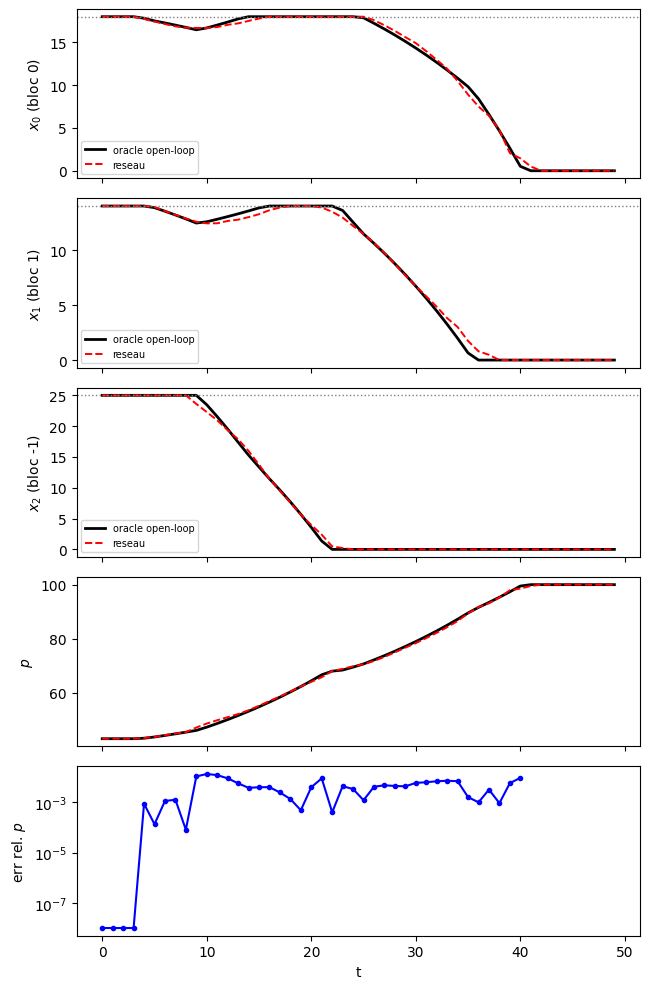


figures -> figs/m3_n3_A2_envhard_rollout.png (+ .npz)
[E] run logue dans runs_m3.csv (10 lignes)

tolerance large ; err_p=1.34e-02 > 1%


/tmp/ipykernel_217622/706424236.py:1525: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  if os.path.exists(p_csv): df = pd.concat([pd.read_csv(p_csv), df], ignore_index=True)


In [1]:
# M3 : N agents (oligopolistes / cartellistes / frange), T periodes, capacite active, PINN.
#
# ============================================================================
# ETAT DU DOSSIER (post RUN 13a corrige / RUN 13b)
#
# LE CAS N=1 STRATEGIQUE EST CLOS. Benchekroun & Withagen (2012, Games and Economic
# Behavior 76(2), 355-374) demontrent que les issues du jeu cartel-frange en boucle
# ouverte et en boucle fermee COINCIDENT quand la frange est preneuse de prix (jeu a la
# Salant 1976). La litterature sur l'incoherence temporelle porte sur l'equilibre de von
# STACKELBERG, ou le cartel internalise la reaction INSTANTANEE de la frange (dx_f/dx_c).
# Ce fichier implemente h_i = p - beta*Lam_i - c_i - delta*lambda'_i : du Nash-Cournot.
# Donc feedback = 0 a N=1 strategique est le resultat ATTENDU. Verifie deux fois :
#   - PINN, STEP 8 : |feedback_0|/lambda_0 = 0.02% (etages A et B).
#   - Grille MPE corrigee : le sentier du CARTEL est reproduit a l'identique
#     (20/20 partout, 17.3/17.3 a t=30, 9.5/9.6 a t=35).
# Le "29.39% d'ecart CL/OL" du RUN 13a initial etait un ARTEFACT NUMERIQUE PUR : il
# oscillait entre 8% et 50% selon ng, et le residu de la boucle de meilleures reponses
# valait 30 barils (la capacite entiere de la frange) au 40e balayage.
#
# CAUSE RACINE, valable pour toute grille de ce type : lambda etait lu par difference
# finie sur un interpolant BILINEAIRE, dont la pente est constante par cellule. La carte
# de meilleure reponse devient une fonction en escalier et l'iteration cycle. Diagnostic
# decisif : le test MONO-AGENT (S_j = 0 pour tous les rivaux -> le jeu disparait, MPE ==
# controle optimal, l'oracle open-loop est la verite EXACTE). L'ancienne methode y donnait
# 100% d'erreur a ng=400. En 1D, la FOC avec derivee ANALYTIQUE d'un interpolant C1
# (PCHIP) tombe a 0.04% avec convergence monotone. En N>=2 le schema stable est la
# MAXIMISATION DIRECTE sur une grille d'actions, qui ne touche jamais a la derivee de
# l'interpolant. C'est ce qui est implemente ici.
#
# CE QUI CHANGE DANS CETTE VERSION
#   1. Calibration par defaut : N=3, DEUX oligopolistes singletons + une frange.
#      C'est la ou la divergence CL/OL existe. Benchekroun & Withagen etablissent aussi
#      que le Nash en boucle fermee a frange nombreuse ne converge PAS vers le
#      cartel-frange en boucle fermee : le raccourci "frange price-taker" n'est pas
#      innocent en boucle fermee, et personne ne l'a quantifie avec capacite liante.
#      Calibration retenue (balayage de l'oracle, cout nul) :
#        costs=10,12,20  kappas=18,14,25  stocks=620,410,400  blocs=0,1,-1
#        -> mu=(12.64,13.94,16.74), epuisement exact, actif t<=40/35/21,
#           kappa liante 15/12/10, et 20 DATES OU LES DEUX STRATEGIQUES SONT
#           SIMULTANEMENT INTERIEURS. C'est le support de J[k,j] != 0.
#   2. Grille MPE generalisee a N = 2 ou 3, decision par maximisation directe.
#   3. STEP 1b : ecran de calibration (verifie le recouvrement des regimes interieurs).
#   4. STEP 9 : BATTERIE DE COHERENCE SANS ORACLE. C'est le coeur de cette version.
#
# POURQUOI STEP 9. L'oracle open-loop reste exact a tout N : les etages A et B gardent
# leur validateur. Ce qui manque, c'est une verite pour l'etage C. La reponse n'est pas
# une grille plus fine mais le TEST DE DEVIATION A UN COUP : un profil de strategies est
# un equilibre si et seulement si aucun joueur ne gagne a devier une fois puis a reprendre
# sa politique. Cela ne demande AUCUN oracle, aucune grille, et c'est la definition meme
# de l'equilibre. Le meme test avec les rivaux GELES sur la trajectoire de reference donne
# la condition OPEN-LOOP ; avec les rivaux qui REPONDENT via leur politique, la condition
# MARKOVIENNE. L'ecart entre les deux gains EST la divergence CL/OL, mesuree sans grille.
#
# LE MODE D'ECHEC A NE PLUS REPETER. Ce n'est jamais le solveur : c'est de mesurer avec
# un instrument qu'on n'a pas d'abord valide contre une verite. COH, CROSS_NEG, err_p brut,
# lam_deflate et la grille MPE ont tous produit un faux diagnostic pour cette raison.
# REGLE : tout nouvel objet (gV hors-diagonale, J, feedback, grille) doit passer son
# propre test de verite AVANT de servir de mesure. C'est ce que STEP 9 systematise.
# ============================================================================
#
# Trois etages (toggles cross / sob_off), a lancer DANS CET ORDRE :
#   A. cross=False, sob_off=False -> systeme OPEN-LOOP a N joueurs.
#      L'oracle generalise est la VERITE, il doit etre retrouve.
#      Test de deviation attendu nul en mode FREEZE.
#   B. cross=False, sob_off=True  -> on entraine le gradient COMPLET dV_i/dS_j. Residu
#      mathematiquement redondant : l'equilibre ne bouge pas, l'oracle doit encore etre
#      retrouve. C'est le test du residu lui-meme.
#   C. cross=True,  sob_off=True  -> MPE. Le reseau s'ecarte de l'oracle open-loop et cet
#      ecart EST le resultat. L'oracle devient comparateur.
#      Test de deviation attendu nul en mode NON-FREEZE.
#
# COUT : sob_off/cross demandent 3*NAG backward passes avec create_graph.

import os, sys, time, json
import numpy as np
import torch, torch.nn as nn
import torch.nn.functional as F

torch.set_num_threads(4)
torch.set_default_dtype(torch.float64)

######## STEP 0  config
CFG = dict(
    tag="m3_n3_A2_envhard", seed=0,
    sampler="mix",           # "mix" = tube+uniforme (defaut) | "tube_oracle" = bras degrade

    # --- ECONOMIE : listes paralleles, un element par AGENT -------------------
    # DEFAUT N=3 : deux oligopolistes singletons (blocs 0 et 1) + une frange (-1).
    #   20 dates ou a0 ET a1 sont simultanement interieurs -> J != 0 -> feedback non nul.
    # Non-regression M2 (N=2) : costs="10,20" kappas="20,30" stocks="700,450" blocs="0,-1"
    #   -> CLOS : coincidence CL/OL demontree et verifiee. Utile comme test de socle.
    costs  = "10,12,20",
    kappas = "18,14,25",
    stocks = "620,410,400",
    blocs  = "0,1,-1",       # entiers distincts = oligopolistes ; egaux = meme cartel ; -1 = frange
    alpha=100.0, beta=1.0, r=0.05, T=50,

    # --- ETAGES ---------------------------------------------------------------
    sob_off=False,           # entrainer dV_i/dS_j hors-diagonale
    cross=False,             # termes croises dans l'enveloppe (=> MPE). Exige sob_off.

    # --- TOGGLES DE BISSECTION (RUN 9). Ne jamais en bouger deux dans le meme run. ---
    sob_ok_mask=True,        # SOB_OK = lignes canoniques de A (False -> ones : RUN 6, casse)
    G_in_V=True,             # facteur G(t) dans la construction de V
    norm_G_bell=True,        # R_bell divise par G_t
    norm_G_lam=True,         # R_env/R_sob/R_lam divises par G_t
    vref_per_agent=False,    # VREF vectoriel alpha*S0_i au lieu du scalaire alpha*max(S0)

    # RUN 12 : cible Monte-Carlo TD(1) pour V, sur le bras TUBE PUR uniquement. VALIDE.
    #   SURVEILLANCE : field_int_med s'est degrade 0.913 -> 1.426 -> 1.770 depuis son
    #   introduction, pendant que les metriques de sentier s'amelioraient. Signature de
    #   surajustement au tube. A N=3 le champ est l'argument meme du PINN : si la
    #   degradation continue, tester use_vmc=False en isolation.
    use_vmc=True, w_vmc=1.0,

    # RUN A2 : cible DURE pour lambda en regime INTERIEUR, au lieu de max(dur, delta*lam').
    #   Le max est un CLIQUET VERS LE HAUT : si le reseau surestime lambda', alors
    #   delta*lam' > p - beta*Lam - c et le max selectionne le BOOTSTRAP, donc la cible
    #   dure mesuree est court-circuitee EXACTEMENT quand elle serait utile.
    #   C'est le mecanisme du biais positif systematique mesure a l'etage A N=3 : niveau
    #   Hotelling 12.91/14.15/16.91 contre mu = 12.64/13.94/16.74, les TROIS agents
    #   surestiment, et lam_deflate derive de facon monotone en remontant le temps depuis
    #   l'ancre d'extinction. Un biais unidirectionnel avec un operateur unidirectionnel
    #   dans la cible.
    #   Le regime est deja connu EXACTEMENT par `bind` (exact par architecture) : on
    #   l'utilise au lieu du max. Le clamp a 0 remplace la protection que le max offrait
    #   en debut d'entrainement, quand p - beta*Lam - c peut etre negatif.
    #   Mettre False pour retrouver l'ancien comportement (bissection).
    env_hard=True,

    # ETAPE 8b : ecran de feedback sur l'ORACLE seul (post STEP 8). ~1 min, aucun reseau.
    run_fb_screen=True, fb_h=1e-2,

    # --- ETAPE 1b : ecran de calibration (cout : quelques secondes, aucun entrainement) ---
    run_screen=True,

    # --- ETAPE 2 : grille MPE (N = 2 ou 3). Cout ~O(ng^N * nx * nbr * T). --------
    #   N=2 : ng=160 nx=31 -> ~30 s.   N=3 : ng=32 nx=15 -> ~2-4 min.
    #   La grille n'est PAS le validateur principal (sa precision plafonne vers 0.5%
    #   en 2D et bien au-dela en 3D). C'est STEP 9 qui valide. La grille sert de
    #   controle croise independant.
    run_mpe_grid=False, mpe_ng=32, mpe_nx=15, mpe_nbr=6,

    # --- reseau ---------------------------------------------------------------
    width=128, emb_dim=16, depth=3,

    # --- loss / sampler -------------------------------------------------------
    w_sob=0.01, w_sob_off=0.1, frac_unif=0.05, frac_gauss=0.25, frac_decor=0.0, box=1.25,
    buf_paths=64, buf_every=50, buf_lo=0.70, buf_hi=1.25,

    # --- entrainement ---------------------------------------------------------
    iters=30000, batch=512, lr=1e-3, lbfgs_outer=3,
    # NOTE : a l'etage B, L-BFGS rend systematiquement loss_pre == loss_post (Wolfe
    # echoue au premier pas) et coute ~300 s pour rien. Mettre lbfgs_outer=0 des que
    # sob_off=True. A l'etage A il travaille reellement, on le garde.

    diag_every=0,            # instrumentation R9bis : decomposition loss + |grad| par residu

    # --- eval -----------------------------------------------------------------
    snap_eps=1e-4, n_field=40, or_nbis=30, or_nouter=15,
    t_decouple="10,20,30", make_figs=True,

    # --- STEP 9 : batterie de coherence SANS ORACLE ---------------------------
    run_step9=True,
    dev_eps_rel=0.15,        # amplitude de deviation, en fraction de la capacite du pas
    dev_n_eps=13,            # points de la grille de deviation (impair : 0 au centre)
    dev_n_dates=5,           # dates sondees
    fd_rel=5e-3,             # pas relatif des differences finies (gV, J)
)

for a in sys.argv[1:]:
    if "=" not in a: continue
    k, v = a.split("=", 1)
    if k not in CFG: continue
    CFG[k] = (v.lower() in ("1", "true")) if isinstance(CFG[k], bool) else type(CFG[k])(v)

alpha, beta, r, T = CFG["alpha"], CFG["beta"], CFG["r"], CFG["T"]
delta = 1.0/(1.0+r)
C_np   = np.array([float(u) for u in CFG["costs"].split(",")])
KAP_np = np.array([float(u) for u in CFG["kappas"].split(",")])
S0_np  = np.array([float(u) for u in CFG["stocks"].split(",")])
BLOC   = np.array([int(u)   for u in CFG["blocs"].split(",")])
NAG = len(C_np)
assert len(KAP_np) == len(S0_np) == len(BLOC) == NAG, "listes d'agents de longueurs differentes"

# masque de conduite : A[i,j] = 1 ssi i et j sont dans le meme bloc (>=0). Frange : ligne nulle.
# cartelliste -> Lambda_i = Q^C (somme du bloc) ; oligopoliste -> Lambda_i = x_i ; frange -> 0.
A_np = np.zeros((NAG, NAG))
for i in range(NAG):
    if BLOC[i] < 0: continue
    for j in range(NAG):
        if BLOC[j] == BLOC[i]: A_np[i, j] = 1.0
IS_FRINGE = BLOC < 0

# SOB_OK : masque de R_lam SEULEMENT (l'identite dV_i/dS_i = lambda_i). Cette identite
# n'est valide que si coef[i,i] = 0, c'est-a-dire pour un OLIGOPOLISTE SINGLETON a
# l'optimum interieur (theoreme de l'enveloppe : le terme de choix propre s'annule).
#   singleton interieur : coef_ii = p - c_i - beta*x_i - delta*GV2_ii = 0
#   cartelliste         : coef_ii = beta*(Q^C - x_i) != 0
#   frange              : coef_ii = -beta*x_f        != 0
# R_sob, l'enveloppe universelle derivee de Bellman, n'a jamais eu de masque et n'en veut
# pas. RUN 6 (SOB_OK = ones) imposait deux equations incompatibles au meme objet. Ne pas
# y revenir.
SOB_OK = (torch.tensor((A_np == np.eye(NAG)).all(1).astype(float))
          if CFG["sob_ok_mask"] else torch.ones(NAG))

if CFG["cross"] and not CFG["sob_off"]:
    print("[!] cross=True force sob_off=True (le feedback depend de dV_i/dS_k)")
    CFG["sob_off"] = True

torch.manual_seed(CFG["seed"]); np.random.seed(CFG["seed"])
A    = torch.tensor(A_np)
COST = torch.tensor(C_np)
KAP  = torch.tensor(KAP_np)
S0V  = torch.tensor(S0_np)
DEN  = beta*(1.0 + torch.diagonal(A))   # pas de Newton du clamp : dh_i/dx_i = -beta(1+A_ii).
                                        # Ce n'est PAS un parametre de conduite : la conduite
                                        # est entierement dans Lambda = A x.
OFF  = 1.0 - torch.eye(NAG)             # masque k != i
VREF = (alpha*S0V) if CFG["vref_per_agent"] else (alpha*S0_np.max())
LREF = alpha                            # rente bornee par le choke price
XREF = torch.minimum(KAP, S0V)          # echelle des QUANTITES (pas des stocks)
W_SOB, W_SOFF = CFG["w_sob"], CFG["w_sob_off"]
FRAC_UNIF, FRAC_GAUSS, BOX, SNAP_EPS = CFG["frac_unif"], CFG["frac_gauss"], CFG["box"], CFG["snap_eps"]

# STRAT[i] = 1 pour un agent STRATEGIQUE (ligne non nulle dans A), 0 pour la frange.
# Une frange preneuse de prix n'a pas de terme de feedback. VALIDE au RUN 13b.
STRAT = torch.tensor((~IS_FRINGE).astype(float))
STRAT_IDX = [i for i in range(NAG) if not IS_FRINGE[i]]

print(f"STEP 0 : {NAG} agents | blocs={list(BLOC)} | strategiques={STRAT_IDX} "
      f"| frange={list(np.nonzero(IS_FRINGE)[0])}")
print(f"         A =\n{A_np.astype(int)}")

def growth_t(ti):
    """G(t) = (1+r)^(t-(T-1)) : vaut 1 a la derniere date de decision, ~0.09 en t=0.
       C'est EXACTEMENT le facteur de croissance de Hotelling : lambda_i(t) = mu_i(1+r)^t.
       Ecrire lam = softplus(l)*LREF*G ramene donc la cible de la tete co-etat a une
       CONSTANTE en t le long du sentier. Preconditionnement exact, adosse a la theorie."""
    return (1.0+r)**(ti.double() - (T-1))

######### STEP 1  oracle open-loop a N joueurs   [INCHANGE, valide analytiquement]

# rentes initiales mu_i, lambda_i(t) = mu_i*(1+r)^t. A rentes donnees, chaque periode est un
# equilibre STATIQUE a couts effectifs c_i + lambda_i(t) (gere les coins nativement).
# On cherche N scalaires au lieu de N*T inconnues et 3^(N*T) regimes.
# Trois boucles : (a) point fixe de meilleures reponses intra-periode, vectorise sur t ;
# (b) methode de tir : bissection sur mu_i pour atteindre Sigma_t x_i = S_i (le cumul est
# strictement decroissant en mu_i) ; (c) Gauss-Seidel sur les agents, car les mu sont
# couples par le prix. Cout LINEAIRE en N, contre O(nbis^N) pour des bissections imbriquees.
NITER_BR = 60

def static_period_N(ceff, kap):
    """ceff [T_,NAG] -> x [T_,NAG]. h_i = 0 donne
       x_i = [alpha - c_i - beta*somme_{j!=i}(1+A_ij)x_j] / (beta*(1+A_ii)), puis clip [0,kappa_i]."""
    x = np.zeros_like(ceff)
    idx = np.arange(NAG)
    for _ in range(NITER_BR):
        for i in range(NAG):
            o = idx[idx != i]
            num = alpha - ceff[:, i] - beta*((1.0 + A_np[i, o])*x[:, o]).sum(1)
            x[:, i] = np.clip(num/(beta*(1.0 + A_np[i, i])), 0.0, kap[i])
    return x

def totals_N(mu, T_, kap, C=None):
    C = C_np if C is None else C
    g = (1.0+r)**np.arange(T_)
    return static_period_N(C[None, :] + mu[None, :]*g[:, None], kap)

def solve_oracle_N(S_, T_, kap=None, nbis=None, nouter=None, C=None):
    kap = KAP_np if kap is None else kap
    nbis = CFG["or_nbis"] if nbis is None else nbis
    nouter = CFG["or_nouter"] if nouter is None else nouter
    mu = np.zeros(NAG); conv = np.inf
    for _ in range(nouter):
        mu_old = mu.copy()
        for i in range(NAG):
            m0 = mu.copy(); m0[i] = 0.0
            if totals_N(m0, T_, kap, C)[:, i].sum() <= S_[i]:   # stock non contraignant
                mu[i] = 0.0; continue
            lo, hi = 0.0, alpha
            for _ in range(nbis):
                m = .5*(lo+hi); mt = mu.copy(); mt[i] = m
                if totals_N(mt, T_, kap, C)[:, i].sum() > S_[i]: lo = m
                else: hi = m
            mu[i] = .5*(lo+hi)
        conv = np.max(np.abs(mu-mu_old))
        if conv < 1e-10: break
    solve_oracle_N.last_conv = float(conv)      # Gauss-Seidel non certifie : on le journalise
    x = totals_N(mu, T_, kap, C)
    return mu, x, alpha - beta*x.sum(1)
solve_oracle_N.last_conv = np.nan

t_or = time.time()
mu_a, xa, pa = solve_oracle_N(S0_np, T, nbis=60, nouter=40)
print(f"STEP 1 oracle ok ({time.time()-t_or:.0f}s) : mu={np.round(mu_a,3)}  "
      f"(convergence Gauss-Seidel {solve_oracle_N.last_conv:.1e})")
for i in range(NAG):
    ai = xa[:, i] > 1e-9
    print(f"  agent {i} (bloc {BLOC[i]:2d}, c={C_np[i]:5.1f}, kap={KAP_np[i]:5.1f}) : "
          f"actif t<={int(np.max(np.nonzero(ai))) if ai.any() else -1}, "
          f"kappa liante {int((xa[:,i]>KAP_np[i]-1e-6).sum())}/{T}, "
          f"cumul {xa[:,i].sum():.1f}/{S0_np[i]:.1f}")
assert np.abs(xa.sum(0) - S0_np).max() < 1e-4, "epuisement viole"
_tlast = int(np.max(np.nonzero(xa.sum(1) > 1e-9)))
assert _tlast < T-1, f"horizon trop court (production encore en t={_tlast})"

# non-regression M2 (N=2 seulement) : l'oracle doit redonner mu=(12.821, 21.757).
if (NAG == 2 and np.allclose(C_np, [10., 20.]) and np.allclose(S0_np, [700., 450.])
        and np.allclose(KAP_np, [20., 30.]) and BLOC[1] < 0):
    assert abs(mu_a[0]-12.821) < 1e-2 and abs(mu_a[1]-21.757) < 1e-2, "oracle N incompatible avec M2"
    print("  [non-regression M2 : mu retrouve]")

SA_T = torch.tensor(S0_np[None, :] - np.concatenate([np.zeros((1, NAG)), np.cumsum(xa, 0)[:-1]], 0))

# regimes, par agent : interieur = ni a zero ni a kappa. C'est la SEULE zone ou lambda_i
# est identifie (ailleurs la FOC est inactive) et la seule ou dx_i/dS_j != 0.
INT = (xa > 1e-6) & (xa < KAP_np[None, :] - 1e-6)

# ============================================================================
# ETAPE 1b : ECRAN DE CALIBRATION. Cout nul, aucun entrainement.
#   Le feedback markovien vaut somme_{k!=i} coef[i,k]*J[k,j] avec J[k,j] = dx_k/dS_j.
#   J[k,j] est identiquement NUL si l'agent k est a un coin (x_k = 0 ou x_k = kappa_k) :
#   sa decision ne repond alors plus a l'etat. Il faut donc des dates ou DEUX AGENTS
#   STRATEGIQUES sont SIMULTANEMENT INTERIEURS, sinon l'etage C n'a rien a mesurer et
#   l'etage B entraine des objets multiplies par zero.
#   C'est exactement ce qui s'est passe a la calibration M2 : a0 colle a kappa pendant
#   toute la vie de la frange -> J[1,0] = 0 -> feedback = 0 par construction.
#   CRITERE : au moins ~10 dates de recouvrement pour une paire strategique.
# ============================================================================
def screen_regimes(x, kap=None):
    kap = KAP_np if kap is None else kap
    itr = (x > 1e-6) & (x < kap[None, :] - 1e-6)
    out = {}
    for a_ in range(len(STRAT_IDX)):
        for b_ in range(a_+1, len(STRAT_IDX)):
            i, j = STRAT_IDX[a_], STRAT_IDX[b_]
            out[(i, j)] = int((itr[:, i] & itr[:, j]).sum())
    return itr, out

if CFG["run_screen"]:
    _itr, _ov = screen_regimes(xa)
    print("\nETAPE 1b  ecran de calibration")
    for i in range(NAG):
        print(f"  agent {i} : interieur sur {int(_itr[:,i].sum()):2d} dates "
              f"| kappa {int((xa[:,i]>KAP_np[i]-1e-6).sum()):2d} | zero {int((xa[:,i]<=1e-6).sum()):2d}")
    if _ov:
        for (i, j), n in _ov.items():
            flag = "OK" if n >= 10 else "INSUFFISANT (feedback non identifie)"
            print(f"  recouvrement interieur strategiques ({i},{j}) : {n:2d} dates  -> {flag}")
    else:
        print("  [!] UN SEUL agent strategique : la coincidence CL/OL est un THEOREME")
        print("      (Benchekroun & Withagen 2012). L'etage C n'a rien a mesurer ici.")
        print("      Passer a >= 2 strategiques, p.ex. blocs='0,1,-1'.")

# ============================================================================
# ETAPE 2 : GRILLE MPE (induction retrograde, N = 2 ou 3). Independante de PyTorch.
#
#   DECISION INTRA-PERIODE : maximisation DIRECTE, sans aucune derivee de V.
#     obj_i(x_i) = (alpha - c_i - beta*somme_{j!=i}(1+A_ij)x_j)*x_i
#                  - (beta(1+A_ii)/2)*x_i^2 + delta*V_i(S - x)
#     d(obj_i)/dx_i = p - beta*Lambda_i - c_i - delta*dV_i/dS_i  =  h_i, EXACTEMENT,
#     et pour toute conduite. Frange : A_ii = A_ij = 0 -> derivee = p - c_f - delta*lam_f,
#     la condition de preneur de prix. C'est un potentiel, pas le profit : c'est ce qui
#     permet de traiter la frange par un argmax alors qu'elle ne maximise pas son profit.
#   Aucun terme de feedback a coder : il est contenu dans le V calcule, puisque
#   sigma_{-i}(S) depend de l'etat.
#
#   PORTE D'ACCEPTATION OBLIGATOIRE : le TEST MONO-AGENT. En mettant tous les stocks
#   rivaux a zero, le jeu disparait, MPE == controle optimal, et l'oracle open-loop est
#   la verite EXACTE. Toute difference est de l'erreur numerique pure. Sans ce test on ne
#   sait pas si un ecart CL/OL est de l'economie ou du bruit.
#   PRECISION ATTEINTE : ~0.5% en 2D a ng=160. Ce plafond vient de l'interpolation
#   multilineaire (pente en escalier). La grille est donc un CONTROLE CROISE, pas le
#   validateur principal : c'est STEP 9 qui valide.
# ============================================================================
def _interp_ml(Z, coords, grids):
    """Interpolation multilineaire sur grille reguliere. Z de forme (ng,)*N."""
    N = len(grids); ng = Z.shape[0]
    idx, fr = [], []
    for k in range(N):
        d = grids[k][1]
        aa = np.clip(coords[k]/d, 0.0, ng-1-1e-9)
        i0 = aa.astype(np.intp); idx.append(i0); fr.append(aa-i0)
    out = 0.0
    for corner in range(1 << N):
        w = 1.0; ii = []
        for k in range(N):
            b = (corner >> k) & 1
            w = w*(fr[k] if b else (1.0-fr[k]))
            ii.append(idx[k]+b)
        out = out + w*Z[tuple(ii)]
    return out

def mpe_grid(ng=None, nx=None, nbr=None):
    ng = ng or CFG["mpe_ng"]; nx = nx or CFG["mpe_nx"]; nbr = nbr or CFG["mpe_nbr"]
    assert NAG <= 3, "grille MPE : N <= 3 (le cout explose au-dela ; c'est l'argument du PINN)"
    grids = [np.linspace(0.0, S0_np[i], ng) for i in range(NAG)]
    G = np.meshgrid(*grids, indexing="ij")
    shp = G[0].shape
    V = [np.zeros(shp) for _ in range(NAG)]
    XPOL = np.zeros((T, NAG) + shp)
    u = np.linspace(0.0, 1.0, nx); resid = 0.0
    for t in reversed(range(T)):
        if t == T-1:
            # derniere date de decision : aucune continuation, on extrait tout le possible.
            # A ecrire explicitement : interpoler un tableau de zeros n'est pas neutre
            # apres clip aux bords, et cela introduisait une pente parasite.
            x = [np.minimum(KAP_np[i], G[i]) for i in range(NAG)]
        else:
            x = [np.zeros(shp) for _ in range(NAG)]
            for it_br in range(nbr):
                xold = [xx.copy() for xx in x]
                for i in range(NAG):
                    hi = np.minimum(KAP_np[i], G[i])
                    cand = u.reshape((1,)*NAG + (nx,))*hi[..., None]
                    coords = []
                    for k in range(NAG):
                        base = (G[i][..., None] - cand) if k == i else (G[k]-x[k])[..., None]
                        coords.append(np.ascontiguousarray(
                            np.broadcast_to(base, cand.shape)).ravel())
                    cont = _interp_ml(V[i], coords, grids).reshape(cand.shape)
                    lin = alpha - C_np[i] - beta*sum((1.0+A_np[i, k])*x[k]
                                                     for k in range(NAG) if k != i)
                    obj = (lin[..., None]*cand - 0.5*beta*(1.0+A_np[i, i])*cand**2
                           + delta*cont)
                    x[i] = np.take_along_axis(cand, obj.argmax(-1)[..., None], -1)[..., 0]
                if it_br == nbr-1:
                    resid = max(resid, max(float(np.abs(x[i]-xold[i]).max()) for i in range(NAG)))
        p = alpha - beta*sum(x)
        Sp = [np.ascontiguousarray(G[i]-x[i]).ravel() for i in range(NAG)]
        if t == T-1:
            V = [(p - C_np[i])*x[i] for i in range(NAG)]
        else:
            V = [(p - C_np[i])*x[i] + delta*_interp_ml(V[i], Sp, grids).reshape(shp)
                 for i in range(NAG)]
        for i in range(NAG): XPOL[t, i] = x[i]
    return grids, XPOL, resid

def mpe_rollout(grids, XPOL, S_init=None):
    """Deroule la politique MPE de la grille depuis S_init. -> X [T,NAG], P [T]."""
    S = np.array(S_init if S_init is not None else S0_np, dtype=float)
    X, P = [], []
    for t in range(T):
        co = [np.array([S[k]]) for k in range(NAG)]
        xt = np.array([float(_interp_ml(XPOL[t, i], co, grids)[0]) for i in range(NAG)])
        xt = np.clip(np.minimum(xt, S), 0.0, None)
        X.append(xt.copy()); P.append(alpha - beta*xt.sum()); S = S - xt
    return np.array(X), np.array(P)

# masque des dates d'extinction (+/-1), reutilise en STEP 5.
_ext = np.zeros(T, dtype=bool)
for i in range(NAG):
    _mi = np.nonzero(xa[:, i] > 1e-9)[0]
    if _mi.size: _ext[max(0, _mi[-1]-1):_mi[-1]+2] = True

MPE = {}
Xcl = Pcl = None
if CFG["run_mpe_grid"] and NAG <= 3:
    _tg = time.time()
    _grids, _XPOL, _rs = mpe_grid()
    # PORTE : verite mono-agent. Rivaux a stock nul -> plus de jeu -> l'oracle est exact.
    _Smono = S0_np.copy()
    for k in range(1, NAG): _Smono[k] = 0.0
    _, _xmo, _pmo = solve_oracle_N(_Smono, T, nbis=60, nouter=40)
    _amo = _xmo[:, 0] > 1e-9
    Xmo, Pmo = mpe_rollout(_grids, _XPOL, _Smono)
    _emp = float(np.abs(Pmo[_amo]-_pmo[_amo]).max()/_pmo.max())
    Xcl, Pcl = mpe_rollout(_grids, _XPOL)
    _a = xa.sum(1) > 1e-6; _keepg = _a & (~_ext)
    _e = np.abs(Pcl[_a]-pa[_a])/pa.max()
    MPE = dict(ng=CFG["mpe_ng"], br_resid=_rs, mono_err_p=_emp,
               gap_p=float(_e.max()),
               gap_p_noext=float(np.abs(Pcl[_keepg]-pa[_keepg]).max()/pa.max()),
               gap_p_q90=float(np.quantile(_e, .90)),
               gap_p0=float(abs(Pcl[0]-pa[0])/pa[0]), cum=Xcl.sum(0).tolist())
    print(f"\nETAPE 2  GRILLE MPE ({time.time()-_tg:.0f}s, ng={CFG['mpe_ng']}, nx={CFG['mpe_nx']})")
    print(f"  PORTE mono-agent (erreur numerique pure) : {_emp:.2%} "
          f"{'OK' if _emp < 5e-3 else '-> plancher de la grille, tout ecart CL/OL en dessous est du bruit'}")
    print(f"  residu BR intra-periode : {_rs:.3f} bbl")
    print(f"  epuisement CL {np.round(Xcl.sum(0),1)} / {S0_np}")
    print("   t  | " + " | ".join(f"a{i} CL/OL" for i in range(NAG)) + " |  p CL/OL")
    for tt in [0, T//5, 2*T//5, 3*T//5, _tlast]:
        s = " | ".join(f"{Xcl[tt,i]:5.1f}/{xa[tt,i]:5.1f}" for i in range(NAG))
        print(f"  {tt:3d} | {s} | {Pcl[tt]:6.2f}/{pa[tt]:6.2f}")
    print(f"  ECART CL/OL : max {MPE['gap_p']:.2%} | hors ext {MPE['gap_p_noext']:.2%} "
          f"| q90 {MPE['gap_p_q90']:.2%} | t=0 {MPE['gap_p0']:.2%}")
    print(f"  A COMPARER au plancher mono-agent {_emp:.2%}. En dessous, ce n'est pas de l'economie.")

#####  STEP 2  reseaux

# un reseau par agent, trois tetes (politique z, valeur w, co-etat l), tronc partage.
# Chaque reseau prend l'etat COMPLET S : c'est la definition du Markov, et c'est ce qui rend
# les derivees croisees dV_i/dS_j et dsigma_k/dS_j calculables par autodiff.
# NOTE DAG : le nombre de reseaux VALEUR utiles = nombre d'agents STRATEGIQUES, pas N.
# La tete valeur de la frange n'est lue par aucune equation une fois STRAT applique ; sa
# tete POLITIQUE, elle, est indispensable (J[f,.] entre dans le feedback des strategiques).
# - ancrage terminal EXACT par 1{t<T}
# - SiLU : le residu Sobolev a besoin de dV/dS non trivial ; le kink est deja dans
#   l'architecture via les min(), donc rien de non lisse a apprendre.
class Net(nn.Module):
    def __init__(s, width, emb_dim, depth):
        super().__init__()
        s.emb = nn.Embedding(T+1, emb_dim)          # T+1 : l'index t=T existe, neutralise par alive
        nn.init.normal_(s.emb.weight, std=0.1)
        layers, d = [], NAG + emb_dim
        for _ in range(depth):
            layers += [nn.Linear(d, width), nn.SiLU()]; d = width
        s.trunk = nn.Sequential(*layers)
        s.head_z = nn.Linear(width, 1); s.head_w = nn.Linear(width, 1); s.head_l = nn.Linear(width, 1)
    def forward(s, S, ti):
        h = s.trunk(torch.cat([S/S0V, s.emb(ti)], dim=-1))
        return s.head_z(h).squeeze(-1), s.head_w(h).squeeze(-1), s.head_l(h).squeeze(-1)

NETS = nn.ModuleList([Net(CFG["width"], CFG["emb_dim"], CFG["depth"]) for _ in range(NAG)])
PARAMS = list(NETS.parameters())

def forward_all(S, ti, snap=False):
    """S:[B,NAG] ti:[B] long -> x, V, lam tous [B,NAG]"""
    z, w, l = [], [], []
    for i in range(NAG):
        zi, wi, li = NETS[i](S, ti); z.append(zi); w.append(wi); l.append(li)
    z = torch.stack(z, -1); w = torch.stack(w, -1); l = torch.stack(l, -1)
    # x = min(min(S,kappa), softplus(z)) : atteint kappa EXACTEMENT (coin superieur franc),
    # garantit 0 <= x <= S par construction. La faisabilite n'est jamais a apprendre.
    x = torch.minimum(torch.minimum(S, KAP), F.softplus(z))
    if snap:                                        # EVAL uniquement (zone morte a l'entrainement)
        x = torch.where(x < SNAP_EPS, torch.zeros_like(x), x)
    alive = (ti < T).double().unsqueeze(-1)
    G = growth_t(ti).unsqueeze(-1) if CFG["G_in_V"] else torch.ones_like(alive)
    # V libre. Les deux ancrages testes sont morts et ne doivent pas revenir :
    #   * (S/S0V) : annule V_i et TOUS ses gradients sur l'hyperplan S_i=0, donc detruit
    #     l'ancre terminale de la chaine arriere de R_sob/R_soff.
    #   * (* S)   : impose V_i = lambda_i*S_i, i.e. courbure nulle en S, alors que la
    #     courbure est l'objet meme que l'etage B doit apprendre (mesure : facteur 1.7).
    V   = alive*F.softplus(w) * VREF*G
    lam = alive*F.softplus(l)*LREF*G
    return x, V, lam

#####  STEP 3  residus

# FOC -> politique ; enveloppe -> co-etat ; Bellman -> valeur ; Sobolev -> lie les deux.
# Chaque agent n'a que SA PROPRE FOC. Ce qui fabrique l'equilibre : p n'est PAS detache
# (le gradient du residu de i remonte dans les reseaux de tous les autres) et chaque reseau
# lit l'etat complet. Tout le reste est de la regression supervisee sur cible bootstrap
# detachee : schema semi-gradient.
# R_foc est EXACT et non approche : h_i etant affine en x_i de pente -beta(1+A_ii), le pas
# x + h/DEN atterrit sur la racine exacte, et le clamp projette. R_foc = 0 <=> x est la
# meilleure reponse contrainte exacte etant donne (p, Lambda, lambda').
def residuals(S, ti):
    S = S.detach().requires_grad_(True)
    x, V, lam = forward_all(S, ti)
    p = alpha - beta*x.sum(-1, keepdim=True)
    Lam = x @ A.T
    S2 = S - x
    _, V2, lam2 = forward_all(S2, ti+1)
    lam2d = lam2.detach()
    cap = torch.minimum(S, KAP)

    h = p - beta*Lam - COST - delta*lam2d
    R_foc = x - torch.clamp(x + h/DEN, torch.zeros_like(x), cap)

    gV = torch.stack([torch.autograd.grad(V[:, i].sum(), S, create_graph=True)[0]
                      for i in range(NAG)], dim=1)

    # Multiplier par 0.0 preserve le lien au graphe d'autodifferenciation
    feedback = x * 0.0
    R_soff = gV * 0.0
    R_sob = x * 0.0

    if CFG["sob_off"]:
        J   = torch.stack([torch.autograd.grad(x[:, k].sum(), S, create_graph=True)[0]
                           for k in range(NAG)], dim=1)

        # --------------------------------------------------------------------
        # OPTION : J analytique par theoreme des fonctions implicites.
        #   dh_i/dS_j = 0 avec h_i = p - beta*Lam_i - c_i - delta*lambda_i(S-x) donne
        #     [delta*L - beta*B] J = delta*L,   L[i,k] = dlambda'_i/dS'_k,  B = 1 + A
        #   J ne depend alors que des derivees PREMIERES de la tete lambda (supervisee par
        #   R_env, cible dure) au lieu des derivees de la tete z (supervisee seulement
        #   implicitement via R_foc). Verification N=1, A=1 : J = |dL|/(|dL|+2beta) dans (0,1).
        #   BUG CORRIGE : la reduction masquait les COLONNES contraintes mais pas les
        #   LIGNES, donc l'equation d'un agent a un coin contaminait la resolution des
        #   lignes libres avant d'etre ecrasee par Jfix. Masquer LES DEUX.
        #   RESERVE : ce J est le J D'EQUILIBRE ; hors equilibre (pendant l'entrainement)
        #   il differe du dx/dS effectif du reseau, donc la cible de R_soff devient
        #   partiellement heterogene a l'objet regresse.
        #   ORDRE : n'activer qu'APRES le diagnostic 9f (magnitude de gV).
        # L2 = torch.stack([torch.autograd.grad(lam2[:, i].sum(), S2, create_graph=True)[0]
        #                   for i in range(NAG)], dim=1)
        # Mj   = delta*L2 - beta*(1.0 + A)
        # Jfix = torch.zeros_like(Mj)
        # at_k = (x >= KAP - 1e-6)
        # at_S = (x >= S   - 1e-6)
        # Jfix = torch.where(at_S.unsqueeze(-1), torch.eye(NAG).expand_as(Mj), Jfix)
        # free = (~(at_k | at_S)).double()                       # [B,NAG]
        # rhs  = delta*L2 - torch.einsum('bik,bkj->bij', Mj*(1.0-free).unsqueeze(1), Jfix)
        # Mred = free.unsqueeze(-1)*Mj*free.unsqueeze(1) + torch.diag_embed(1.0-free)
        # J    = torch.linalg.solve(Mred, rhs)*free.unsqueeze(-1) + Jfix
        # --------------------------------------------------------------------

        GV2 = torch.stack([torch.autograd.grad(V2[:, i].sum(), S2, create_graph=True)[0]
                           for i in range(NAG)], dim=1)
        # coef[i,k] = d(pi_i)/d(x_k) - delta*dV_i'/dS_k'
        #           = -beta*x_i - delta*GV2[i,k]  (k!=i)   |   + (p - c_i)  (k=i)
        coef = -beta*x.unsqueeze(-1) - delta*GV2 + torch.diag_embed(p - COST)

        # M_full  : dV_i/dS_j = delta*GV2[i,j] + M_full[i,j]. Somme sur TOUS les k.
        # M_cross : somme sur k != i seulement. Le terme diagonal coef_ii*J_ii n'est PAS du
        #           feedback, c'est le coin de conduite.
        M_full  = torch.einsum('bik,bkj->bij', coef,     J)
        M_cross = torch.einsum('bik,bkj->bij', coef*OFF, J)

        feedback = torch.diagonal(M_cross, dim1=1, dim2=2)
        R_soff   = (gV - (delta*GV2 + M_full).detach())*OFF
        # P-C : cette cible est AUTO-REFERENTIELLE (construite depuis le V du reseau
        # lui-meme, ancre terminale degeneree a 0). CONFIRME EMPIRIQUEMENT au RUN 13b :
        # a1 dV/dS a 28.91% contre un ecart theorique attendu de 2.5-5%. R_sob converge
        # vers un point fixe auto-coherent mais faux la ou il est le seul residu actif.
        # Attaque : cibles pathwise mesurees (STEP 9f -> R_gv).
        R_sob = torch.diagonal(gV, dim1=1, dim2=2) - (delta*torch.diagonal(GV2, dim1=1, dim2=2)
                                            + torch.diagonal(M_full, dim1=1, dim2=2)).detach()

        # Une frange PRENEUSE DE PRIX n'a pas de terme de feedback. Une fois feedback_f = 0,
        # GV2[f,:] n'entre plus dans aucune equation. VALIDE au RUN 13b.
        R_soff   = R_soff * STRAT.view(1, -1, 1)
        feedback = feedback * STRAT

    bind = (x >= KAP - 1e-4).detach()
    zero = (x <= SNAP_EPS).detach()
    hard = torch.clamp(p.detach()-beta*Lam.detach()-COST, min=0.0)
    if CFG["env_hard"]:
        # regime INTERIEUR -> cible DURE mesuree, sans bootstrap.
        # regimes kappa et zero -> enveloppe lambda = delta*lambda'.
        # Voir la note env_hard en STEP 0 : le max precedent etait un cliquet vers le haut.
        tgt = torch.where(bind | zero, delta*lam2d, hard)
    else:
        tgt = torch.where(bind, delta*lam2d, torch.maximum(hard, delta*lam2d))
    # Injection du MPE : UNE ligne. Le feedback entre dans la cible du CO-ETAT, puis se
    # propage a la politique via le terme delta*lambda' de la FOC. Correct dans les deux
    # branches : en zone kappa J_ii = 0, a l'interieur coef_ii = 0 pour un singleton, donc
    # dV_i/dS_i = delta*lambda'_i + feedback_i dans les deux cas.
    if CFG["cross"]: tgt = tgt + feedback.detach()
    R_env = lam - tgt

    R_bell = V - ((p.detach()-COST)*x.detach() + delta*V2.detach())

    R_lam = (torch.diagonal(gV, dim1=1, dim2=2) - lam) * SOB_OK

    return R_foc, R_env, R_bell, R_sob, R_soff, R_lam, V

def loss_from_res(R, ti, Vtgt=None, msk=None, parts=False):
    # UNE loss, somme sur tous les agents, un seul optimiseur conjoint.
    R_foc, R_env, R_bell, R_sob, R_soff, R_lam, V = R
    G_t = growth_t(ti).unsqueeze(-1)
    GB = G_t if CFG["norm_G_bell"] else torch.ones_like(G_t)
    GL = G_t if CFG["norm_G_lam"]  else torch.ones_like(G_t)
    c_foc  =        ((R_foc /XREF      )**2).sum(-1)
    c_env  =        ((R_env /(LREF*GL) )**2).sum(-1)
    c_bell =        ((R_bell/(VREF*GB) )**2).sum(-1)
    c_sob  = W_SOB *((R_sob /(LREF*GL) )**2).sum(-1)
    c_lam  = W_SOB *((R_lam /(LREF*GL) )**2).sum(-1)
    L = c_foc + c_env + c_bell + c_sob + c_lam
    c_soff = torch.zeros_like(L)
    if CFG["sob_off"]:
        c_soff = W_SOFF*((R_soff/(LREF*GL.unsqueeze(-1)))**2).sum((-1, -2))
        L = L + c_soff

    # Cible Monte-Carlo TD(1) pour V, sur le tube. R_bell est un residu a UN pas : il peut
    # etre minuscule pendant que V derive de 25% (V est un bootstrap a 20-40 pas avec une
    # unique ancre en T). Le buffer fait deja 64 rollouts complets : la cible est gratuite,
    # exacte, sans oracle, et valide a l'etage C (V^MC est la valeur de la politique
    # COURANTE, quelle qu'elle soit). msk = 1 uniquement sur le bras tube pur.
    # ATTENTION : STEP 6 compare V_net(S0,0) au profit du rollout depuis S0, soit
    # exactement l'objet regresse ici -> Bellman MC devient QUASI-TAUTOLOGIQUE.
    c_vmc = torch.zeros_like(L)
    if CFG["use_vmc"] and (Vtgt is not None) and (msk is not None):
        c_vmc = CFG["w_vmc"]*(((V - Vtgt.detach())/(VREF*GB))**2).sum(-1)*msk
        L = L + c_vmc

    if parts:
        d = dict(foc=c_foc, env=c_env, bell=c_bell, sob=c_sob, lam=c_lam,
                 soff=c_soff, vmc=c_vmc)
        return L.mean(), {k: v.mean().item() for k, v in d.items()}
    return L.mean()

# normes de gradient par residu. Sans ces chiffres on pilote a l'aveugle.
def grad_norms(Sb, tb, Vtgt=None, msk=None):
    R = residuals(Sb, tb)
    G_t = growth_t(tb).unsqueeze(-1)
    GB = G_t if CFG["norm_G_bell"] else torch.ones_like(G_t)
    GL = G_t if CFG["norm_G_lam"]  else torch.ones_like(G_t)
    comps = dict(
        foc  =        ((R[0]/XREF     )**2).sum(-1).mean(),
        env  =        ((R[1]/(LREF*GL))**2).sum(-1).mean(),
        bell =        ((R[2]/(VREF*GB))**2).sum(-1).mean(),
        sob  = W_SOB *((R[3]/(LREF*GL))**2).sum(-1).mean(),
        lam  = W_SOB *((R[5]/(LREF*GL))**2).sum(-1).mean(),
    )
    if CFG["sob_off"]:
        comps["soff"] = (W_SOFF*((R[4]/(LREF*GL.unsqueeze(-1)))**2).sum((-1, -2))).mean()
    if CFG["use_vmc"] and (Vtgt is not None) and (msk is not None):
        comps["vmc"] = (CFG["w_vmc"]*(((R[6]-Vtgt.detach())/(VREF*GB))**2).sum(-1)*msk).mean()
    out = {}
    for k, v in comps.items():
        if float(v) == 0.0: out[k] = 0.0; continue
        g = torch.autograd.grad(v, PARAMS, retain_graph=True, allow_unused=True)
        out[k] = float(torch.sqrt(sum((gi**2).sum() for gi in g if gi is not None)))
    return out

##### STEP 4  sampler + entrainement

# tube (buffer de la politique COURANTE : voisinage transverse, force de rappel du rollout)
# + petit ancrage uniforme (structure globale). Le tube-oracle a bruit nul ne donnait aucun
# champ transverse => loss 1e-6 et trajectoire fausse a 16%.
# LA LOSS NE VALIDE RIEN : une loss 65x pire a battu l'autre d'un facteur 2.5 sur le rollout.
# A N grand l'ancrage uniforme couvre de moins en moins (volume exponentiel) : c'est le TUBE
# qui rend le DEQN faisable la ou une grille ne l'est pas.
_BUF = None
_VBUF = None
def refresh_buffer(n=None):
    global _BUF, _VBUF
    n = n or CFG["buf_paths"]
    with torch.no_grad():
        S = (CFG["buf_lo"] + (CFG["buf_hi"]-CFG["buf_lo"])*torch.rand(n, NAG))*S0V
        SS, TT, XX, PP = [], [], [], []
        for t in range(T):
            ti = torch.full((n,), t, dtype=torch.long)
            SS.append(S.clone()); TT.append(ti)
            x, _, _ = forward_all(S, ti)
            XX.append(x.clone()); PP.append(alpha - beta*x.sum(-1, keepdim=True))
            S = S - x
        _BUF = (torch.cat(SS, 0), torch.cat(TT, 0), n)
        # accumulation ARRIERE du profit actualise le long du rollout DEJA calcule.
        # V^MC_i(S_t,t) = somme_{s>=t} delta^(s-t) (p_s - c_i) x_is , tronquee en T.
        Vmc, VV = torch.zeros(n, NAG), [None]*T
        for t in reversed(range(T)):
            Vmc = (PP[t] - COST)*XX[t] + delta*Vmc
            VV[t] = Vmc.clone()
        _VBUF = torch.cat(VV, 0)

def sample_states(B):
    if CFG["sampler"] == "tube_oracle":
        idx = torch.randint(0, T, (B,))
        return SA_T[idx], idx, torch.zeros(B, NAG), torch.zeros(B)

    n_u = int(CFG["frac_unif"] * B)
    n_j = int(CFG["frac_gauss"] * B)
    n_d = int(CFG.get("frac_decor", 0.0) * B)
    n_b = B - n_u - n_j - n_d

    S_u = torch.rand(n_u, NAG) * S0V * BOX                      # 1. global uniforme
    t_u = torch.randint(0, T, (n_u,))

    idx_j = torch.randint(0, _BUF[0].shape[0], (n_j,))          # 2. jitter local
    S_j = torch.clamp(_BUF[0][idx_j] + torch.randn(n_j, NAG) * 0.05 * S0V, min=0.0)
    t_j = _BUF[1][idx_j]

    idx_b = torch.randint(0, _BUF[0].shape[0], (n_b,))          # 3. tube pur
    S_b = _BUF[0][idx_b]; t_b = _BUF[1][idx_b]

    # 4. bras decorrelant (brise la collinearite S_0 <-> t). Le confondant est ETABLI mais
    # ce bras ne le casse pas : la cible de gV[i,j] est construite depuis le V du reseau
    # lui-meme. Point fixe auto-referentiel, qu'aucun echantillonnage ne casse.
    # -> frac_decor=0.0 par defaut ; le bras reste inerte mais present.
    idx_d = torch.randint(0, _BUF[0].shape[0], (n_d,))
    S_d = _BUF[0][idx_d].clone()
    agent_idx = torch.randint(0, NAG, (n_d,))
    if n_d: S_d[torch.arange(n_d), agent_idx] = torch.rand(n_d) * S0V[agent_idx] * BOX
    t_d = _BUF[1][idx_d]

    # la cible MC n'est VALIDE QUE sur le bras 3 (tube pur, etat non perturbe).
    Vt = torch.cat([torch.zeros(n_u, NAG), torch.zeros(n_j, NAG),
                    (_VBUF[idx_b] if _VBUF is not None else torch.zeros(n_b, NAG)),
                    torch.zeros(n_d, NAG)], 0)
    mk = torch.cat([torch.zeros(n_u), torch.zeros(n_j),
                    torch.ones(n_b),  torch.zeros(n_d)], 0)
    return (torch.cat([S_u, S_j, S_b, S_d], 0), torch.cat([t_u, t_j, t_b, t_d], 0), Vt, mk)

print(f"\nSTEP 4 : Adam (NAG={NAG}, cross={CFG['cross']}, sob_off={CFG['sob_off']}, "
      f"vmc={CFG['use_vmc']})...")
opt = torch.optim.Adam(PARAMS, lr=CFG["lr"])
t0 = time.time(); refresh_buffer(); loss_hist = []
for it in range(CFG["iters"]):
    if it == CFG["iters"]*4//10:
        for g in opt.param_groups: g["lr"] = 3e-4
    if it == CFG["iters"]*6//10:
        for g in opt.param_groups: g["lr"] = 1e-4
    if CFG["sampler"] == "mix" and it % CFG["buf_every"] == 0: refresh_buffer()
    opt.zero_grad()
    Sb, tb, Vb, mb = sample_states(CFG["batch"])
    L = loss_from_res(residuals(Sb, tb), tb, Vb, mb)
    L.backward(); opt.step()
    if it % 100 == 0: loss_hist.append((it, L.item()))
    if it % 3000 == 0: print(f"  it={it:5d} loss={L.item():.3e} ({time.time()-t0:.0f}s)", flush=True)
    if CFG["diag_every"] and it % CFG["diag_every"] == 0:
        Sd, td, Vd, md = sample_states(CFG["batch"])
        _, pc = loss_from_res(residuals(Sd, td), td, Vd, md, parts=True)
        gn = grad_norms(Sd, td, Vd, md)
        print("        parts " + " ".join(f"{k}={v:.2e}" for k, v in pc.items()), flush=True)
        print("        |grad| " + " ".join(f"{k}={v:.2e}" for k, v in gn.items()), flush=True)

print("STEP 4 : L-BFGS (collocation fixe)...")
Lpost = loss_hist[-1][1] if loss_hist else float("nan")
for outer in range(CFG["lbfgs_outer"]):
    if CFG["sampler"] == "mix": refresh_buffer(256)
    Sb, tb, Vb, mb = sample_states(6000)
    Sb = torch.cat([Sb, S0V.expand(100, NAG)], 0)   # ancre S0 dans le jeu fixe
    tb = torch.cat([tb, torch.zeros(100, dtype=torch.long)], 0)
    Vb = torch.cat([Vb, torch.zeros(100, NAG)], 0)
    mb = torch.cat([mb, torch.zeros(100)], 0)
    opt2 = torch.optim.LBFGS(PARAMS, lr=1.0, max_iter=400, history_size=60,
                             tolerance_grad=1e-15, tolerance_change=1e-16,
                             line_search_fn="strong_wolfe")
    def closure():
        opt2.zero_grad(); Lf = loss_from_res(residuals(Sb, tb), tb, Vb, mb); Lf.backward(); return Lf
    L = opt2.step(closure); Lpost = closure().item(); loss_hist.append((CFG["iters"]+outer, Lpost))
    print(f"  outer={outer} loss_pre={L.item():.3e} loss_post={Lpost:.3e} ({time.time()-t0:.0f}s)", flush=True)
LOSS_FINAL = Lpost

###### STEP 5  rollout vs oracle

def rollout(S_init, snap=True):
    S = S_init.clone().reshape(1, NAG); X, P = [], []
    with torch.no_grad():
        for t in range(T):
            x, _, _ = forward_all(S, torch.tensor([t]), snap=snap)
            X.append(x[0].clone().numpy()); P.append((alpha - beta*x.sum()).item())
            S = S - x
    return np.array(X), np.array(P), S[0].numpy()

X, P, Send = rollout(S0V)
act = xa.sum(1) > 1e-6
err_p = np.abs(P[act]-pa[act]).max()/pa.max()
err_x = np.abs(X[act]-xa[act]).max()/KAP_np.max()
print(f"\nSTEP 5 rollout vs oracle open-loop "
      f"({'COMPARATEUR (MPE)' if CFG['cross'] else 'VALIDATEUR'})")
print("  t  | " + " | ".join(f"a{i} res/or" for i in range(NAG)) + " |  p res/or")
for tt in [0, T//5, 2*T//5, 3*T//5, _tlast]:
    s = " | ".join(f"{X[tt,i]:5.1f}/{xa[tt,i]:5.1f}" for i in range(NAG))
    print(f" {tt:3d} | {s} | {P[tt]:6.2f}/{pa[tt]:6.2f}")
print(f"  epuisement {np.round(X.sum(0),1)} / {S0_np}")
print(f"  err_max(actives) x={err_x:.2e}  p={err_p:.2e}")

ep = np.abs(P[act]-pa[act])/pa.max(); ia = np.nonzero(act)[0]
top = np.argsort(ep)[::-1][:4]
print("  4 pires dates :", ", ".join(f"t={ia[i]}({ep[i]*100:.1f}%)" for i in top))

# METRIQUES ROBUSTES : err_p est un MAX, donc pilote par la seule date d'extinction, ou
# le biais structurel de date d'extinction domine. err_p_noext exclut les dates
# d'extinction +/-1 ; err_p_q90 est insensible a un point isole.
# ATTENTION A L'ESTIMAND : la "cible M2 de 9e-3" etait un err_p COMPLET. La comparer a
# err_p_noext flatte mecaniquement le run.
_keep = act & (~_ext)
ERRP_NOEXT = float(np.abs(P[_keep]-pa[_keep]).max()/pa.max()) if _keep.any() else float("nan")
ERRP_Q90 = float(np.quantile(ep, 0.90))
print(f"  err_p hors dates d'extinction = {ERRP_NOEXT:.2e}   |   err_p q90 = {ERRP_Q90:.2e}")

# Hotelling : marge STRATEGIQUE h_i = p - beta*Lambda_i - c_i, deflatee -> doit etre PLATE
# a la hauteur mu_i. La PLATITUDE (cv) est un test SANS ORACLE ; le NIVEAU utilise mu.
# Ne porte que sur les dates INTERIEURES, seules ou lambda est identifie.
# A cross=True la courbe n'est plus plate, et l'ecart a la platitude EST le feedback.
Lam_r = X @ A_np.T
hall = (P[:, None] - beta*Lam_r - C_np[None, :])/((1.0+r)**np.arange(T))[:, None]
HOT = {}
for i in range(NAG):
    mi = (X[:, i] > 1e-3) & (X[:, i] < KAP_np[i]-1e-3)
    if mi.sum() > 1:
        HOT[i] = (hall[mi, i].std()/abs(hall[mi, i].mean()), hall[mi, i].mean())
        print(f"  Hotelling a{i} : cv={HOT[i][0]:.2e} sur {int(mi.sum())} dates | "
              f"niveau {HOT[i][1]:.2f} vs mu={mu_a[i]:.2f}")

###### STEP 5a  rente par date
lam_true = mu_a[None, :]*((1.0+r)**np.arange(T))[:, None]
with torch.no_grad():
    _, _, lam_net = forward_all(SA_T, torch.arange(T))
rel_lam = np.abs(lam_net.numpy()-lam_true)/np.maximum(lam_true, 1e-9)
act_nag = xa > 1e-6      # masque 2D : dates actives de CHAQUE agent (pas un masque global)
LAM_MED = float(np.median(rel_lam[act_nag]))
LAM_MAX = float(rel_lam[act_nag].max())
print(f"\nSTEP 5a rente le long du sentier : err rel mediane {LAM_MED:.2%}, max {LAM_MAX:.2%}")
for i in range(NAG):
    m = xa[:, i] > 1e-6
    if m.any():
        print(f"  a{i}: med {np.median(rel_lam[m, i]):.2%} max {rel_lam[m, i].max():.2%}")

###### STEP 5e  la rente par ses DEUX representations, sur le TUBE
# 5a mesure la tete lambda. Ici dV_i/dS_i, meme verite, meme echantillon.
# ATTENTION AUX AGENTS NON SINGLETONS (SOB_OK=0) : pour la frange, dV_f/dS_f n'est PAS
# lambda_f : l'ecart structurel vaut beta*x_f*J_ff/lambda_f, le COIN DE CONDUITE.
# CORRECTION (etage A N=3) : ce coin a ete MESURE a ~13%, pas 2.5-5% comme estime d'abord.
# a2 donne 26.86% contre lam_true ici, mais 7.3% contre la cible pathwise de 9f. C'est
# donc 5e qui compare deux objets DIFFERENTS pour un non-singleton, pas le reseau qui se
# trompe. Pour la frange, lire 9f, pas 5e.
Sg = SA_T.clone().requires_grad_(True); tg = torch.arange(T)
_, Vg, _ = forward_all(Sg, tg)
gd = torch.diagonal(torch.stack([torch.autograd.grad(Vg[:, i].sum(), Sg, retain_graph=True)[0]
                                 for i in range(NAG)], dim=1), dim1=1, dim2=2).detach().numpy()
rel_g = np.abs(gd - lam_true)/np.maximum(lam_true, 1e-9)
print("\nSTEP 5e rente : dV/dS (tube) vs tete lambda, contre oracle")
for i in range(NAG):
    m = xa[:, i] > 1e-6
    if m.any():
        print(f"  a{i}: dV/dS med {np.median(rel_g[m,i]):.2%} max {rel_g[m,i].max():.2%}"
              f"  |  tete lam med {np.median(rel_lam[m,i]):.2%}  (SOB_OK={int(SOB_OK[i])})")
# profil temporel de la rente DEFLATEE : doit etre plate a la hauteur mu.
# NON INTERPRETABLE en zone kappa (FOC inactive, lambda non identifie).
lt = lam_net.numpy()/((1.0+r)**np.arange(T))[:, None]
for i in range(NAG):
    m = np.nonzero(xa[:, i] > 1e-6)[0]
    if len(m) > 6:
        q = [m[0], m[len(m)//4], m[len(m)//2], m[3*len(m)//4], m[-1]]
        print(f"  a{i} lam_deflate " + " ".join(f"t{t}:{lt[t,i]:.2f}" for t in q)
              + f"   (mu={mu_a[i]:.2f})")

###### STEP 5b  champ, STRATIFIE
# field_int_med est la metrique de champ la plus fiable (seule a suivre err_p monotonement
# sur les runs 5-8). Historique : 0.913 -> 1.426 (vmc) -> 1.770 (sob_off). DEGRADATION
# MONOTONE pendant que le sentier s'ameliore : surajustement au tube. A N=3 le champ est
# l'argument meme du PINN, il faut arreter cette derive.
print(f"\nSTEP 5b champ (oracle tronque, n={CFG['n_field']})")
rng = np.random.default_rng(0)
Sf_ = rng.uniform(0.05, 1.10, (CFG["n_field"], NAG))*S0_np
tf_ = rng.integers(0, T-1, CFG["n_field"])
buck = {"kappa": [], "interieur": [], "zero": []}
t_f0 = time.time()
with torch.no_grad():
    for sv, tv in zip(Sf_, tf_):
        _, xo, _ = solve_oracle_N(sv, T-int(tv))
        xn, _, _ = forward_all(torch.tensor(sv).reshape(1, NAG), torch.tensor([int(tv)]), snap=True)
        for i in range(NAG):
            reg = ("kappa" if xo[0, i] >= KAP_np[i]-1e-6
                   else ("zero" if xo[0, i] <= 1e-9 else "interieur"))
            buck[reg].append(abs(xn[0, i].item()-xo[0, i]))
FIELD = {}
for reg, d in buck.items():
    if not d: continue
    d = np.array(d); FIELD[reg] = (float(np.median(d)), float(np.quantile(d, .9)))
    print(f"  {reg:9s} n={len(d):4d} | err med {FIELD[reg][0]:.3f} q90 {FIELD[reg][1]:.3f} bbl")
print(f"  ({time.time()-t_f0:.0f}s)")
FI = FIELD.get("interieur", (np.nan, np.nan))

###### STEP 5c  recuperation hors-sentier
# distingue une POLITIQUE sigma(S) d'une sequence memorisee : partir d'ailleurs et
# retomber sur l'oracle recalcule depuis ce point.
print("\nSTEP 5c recuperation hors-sentier")
REC = {}
for fac in (0.8, 1.2):
    Xp, Pp, _ = rollout(S0V*fac)
    _, xo, po = solve_oracle_N(S0_np*fac, T, nbis=60, nouter=40)
    a_ = xo.sum(1) > 1e-6
    REC[fac] = float(np.abs(Pp[a_]-po[a_]).max()/po.max())
    print(f"  S0x{fac} : err_p={REC[fac]:.2e}")

####### STEP 5d  decouplage 1-pas
# action du reseau A L'ETAT ORACLE de la date t, puis continuation ORACLE.
# Petit => la decision locale est bonne, l'erreur du rollout vient de la derive d'etat.
# Choisir des dates ou un agent est INTERIEUR : la ou tout le monde est colle a kappa, la
# decision est exacte par architecture et le test est degenere.
print("\nSTEP 5d decouplage 1-pas (etat oracle)")
DEC = {}
for ts in [int(u) for u in CFG["t_decouple"].split(",")]:
    if ts >= _tlast: continue
    Ss = SA_T[ts].reshape(1, NAG)
    with torch.no_grad():
        xs, _, _ = forward_all(Ss, torch.tensor([ts]), snap=True)
    xs = xs[0].numpy()
    _, _, ptail = solve_oracle_N(Ss[0].numpy()-xs, T-ts-1, nbis=60, nouter=40)
    ph = np.concatenate(([alpha - beta*xs.sum()], ptail))
    ao = xa[ts:].sum(1) > 1e-6
    DEC[ts] = float(np.abs(ph[ao]-pa[ts:][ao]).max()/pa.max())
    print(f"  t={ts:2d} : err_p={DEC[ts]:.2e}")

####### STEP 6  Bellman Monte-Carlo
# coherence de la VALEUR, SANS ORACLE : V_i(S0,0) predit contre le profit actualise
# REELLEMENT realise. Survit tel quel a l'etage C.
# QUASI-TAUTOLOGIQUE quand use_vmc=True : c'est exactement l'objet regresse sur le tube.
with torch.no_grad():
    _, V0, _ = forward_all(S0V.reshape(1, NAG), torch.tensor([0]))
d_t = delta**np.arange(T)
V_mc = np.array([float(np.sum(d_t*(P - C_np[i])*X[:, i])) for i in range(NAG)])
V_net = V0[0].numpy()
V_or = np.array([float(np.sum(d_t*(pa - C_np[i])*xa[:, i])) for i in range(NAG)])
print("  paiement realise vs oracle : " + " ".join(f"a{i} {(V_mc[i]/V_or[i]-1):+.3%}"
                                                   for i in range(NAG)))
BELL = float(np.max(np.abs(V_net-V_mc)/np.maximum(np.abs(V_mc), 1e-9)))
print(f"\nSTEP 6 Bellman MC : ecart max {BELL:.2%}")
for i in range(NAG):
    print(f"  a{i} : V_net={V_net[i]:9.1f} vs realise={V_mc[i]:9.1f}")

####### STEP 7  enveloppe + gradients croises
# COH est identiquement |R_lam|/lambda : il mesure l'erreur de la TETE LAMBDA, pas celle
# du gradient. Son estimand change avec SOB_OK : ne jamais comparer deux COH sous masques
# differents.
# AVERTISSEMENT CAPITAL : le SIGNE ne dit RIEN de la MAGNITUDE, et le feedback est un
# PRODUIT coef[i,k]*J[k,j]. 98% de signes corrects sont compatibles avec un facteur 3
# d'erreur en amplitude. La magnitude est mesuree en STEP 9f, pas ici.
Sp = (torch.rand(2000, NAG)*S0V*1.1).requires_grad_(True)
tp = torch.randint(0, T-1, (2000,))
_, Vp, lamp = forward_all(Sp, tp)
gVp = torch.stack([torch.autograd.grad(Vp[:, i].sum(), Sp, retain_graph=True)[0]
                   for i in range(NAG)], dim=1)

COH = (((torch.diagonal(gVp, dim1=1, dim2=2) - lamp).abs()
        / (lamp.abs() + 1e-6))[:, SOB_OK > 0]).median().item()

# filtre d'amplitude : on ignore les regions ou la derivee croisee est physiquement ~0.
# Sans ce filtre, CROSS_NEG comptait le signe d'une derivee nulle : quatre runs perdus.
off_mask = OFF.unsqueeze(0).expand_as(gVp) > 0
scale = lamp.detach().abs().unsqueeze(-1).expand_as(gVp)[off_mask] + 1e-9
offv = gVp[off_mask]
sig  = offv.abs() > 0.05 * scale
CROSS_NEG = (offv[sig] < 0).double().mean().item() if sig.any() else 0.0

print(f"\nSTEP 7 |dV_i/dS_i - lambda_i|/lambda = {COH:.2%}")
print(f"        dV_i/dS_j < 0 sur {CROSS_NEG:.0%} des cas significatifs (boite)")
for i in range(NAG):
    ci = ((gVp[:, i, i] - lamp[:, i]).abs()/(lamp[:, i].abs()+1e-6)).median().item()
    print(f"        COH a{i} = {ci:.2%}  (SOB_OK={int(SOB_OK[i])})")
for i in range(NAG):
    for j in range(NAG):
        if i == j: continue
        sig_ij = gVp[:, i, j].abs() > 0.05 * (lamp[:, i].detach().abs() + 1e-9)
        c_neg = (gVp[:, i, j][sig_ij] < 0).double().mean().item() if sig_ij.any() else 0.0
        print(f"        Boite (i={i}, j={j}) : {c_neg:.0%} negatifs (sur {int(sig_ij.sum())} pts)")

# mesure stricte sur le TUBE (seule zone d'interet pour le MPE)
St = SA_T.clone().requires_grad_(True)
tt = torch.arange(T)
_, Vt, _ = forward_all(St, tt)
gVt = torch.stack([torch.autograd.grad(Vt[:, i].sum(), St, retain_graph=True)[0]
                   for i in range(NAG)], dim=1)
for i in range(NAG):
    for j in range(NAG):
        if i == j: continue
        act_ij = (xa[:, i] > 1e-6) & (xa[:, j] > 1e-6)
        if act_ij.any():
            c_neg_t = (gVt[act_ij, i, j] < 0).double().mean().item()
            print(f"        Tube  (i={i}, j={j}) : {c_neg_t:.0%} negatifs (sur {int(act_ij.sum())} dates)")

####### STEP 8  taille du terme croise
# A cross=False c'est le terme OMIS, donc l'erreur de specification de l'open-loop.
# ATTENTION : a l'etage A, GV2 hors-diagonale n'est entraine par RIEN. A l'etage B il l'est,
# mais par une cible auto-referentielle. Et c'est une derivee LOCALE du premier ordre,
# identiquement nulle a un coin : elle ne capture pas les deplacements de date de bascule
# de regime, que la grille capture. Les deux grandeurs ne sont pas comparables une pour une.
FB = np.nan; FB_SIGN = np.nan
try:
    Sr = SA_T[:_tlast].clone().requires_grad_(True)
    tr = torch.arange(_tlast)
    xr, Vr, lamr = forward_all(Sr, tr)
    Sr2 = Sr - xr
    _, Vr2, _ = forward_all(Sr2, tr+1)
    Jr = torch.stack([torch.autograd.grad(xr[:, k].sum(), Sr, create_graph=True)[0]
                      for k in range(NAG)], dim=1)
    GV2r = torch.stack([torch.autograd.grad(Vr2[:, i].sum(), Sr2, create_graph=True)[0]
                        for i in range(NAG)], dim=1)
    pr = alpha - beta*xr.sum(-1, keepdim=True)
    coefr = -beta*xr.unsqueeze(-1) - delta*GV2r + torch.diag_embed(pr - COST)
    Mr = torch.einsum('bik,bkj->bij', coefr*OFF, Jr)   # feedback = somme k != i UNIQUEMENT
    fbs = torch.diagonal(Mr, dim1=1, dim2=2)*STRAT
    fb = fbs.abs().detach().numpy()
    rel = fb/np.maximum(np.abs(lamr.detach().numpy()), 1e-9)
    FB = float(np.median(rel[rel > 0])) if (rel > 0).any() else 0.0
    # le SIGNE decide si l'agent closed-loop est plus ou moins conservateur que l'open-loop.
    _fbs = fbs.detach().numpy()
    FB_SIGN = float(np.mean(_fbs[np.abs(_fbs) > 1e-9] < 0)) if (np.abs(_fbs) > 1e-9).any() else np.nan
    print(f"\nSTEP 8 |feedback_i| / lambda_i sur le sentier : mediane {FB:.2%}, max {rel.max():.2%}")
    print(f"        feedback < 0 sur {FB_SIGN:.0%} des points non nuls")
    for i in range(NAG):
        ri = rel[:, i]; ri = ri[ri > 0]
        if ri.size:
            print(f"  a{i} (STRAT={int(STRAT[i])}) : mediane {np.median(ri):.2%} max {ri.max():.2%}")
except Exception as e:
    print(f"\n[STEP 8 ignore : {e}]")

# diagnostic desagrege de lambda : interieur vs zone kappa. Cout nul.
# Un desaccord fort en zone kappa n'est PAS une regression : lambda n'y est pas identifie
# (FOC inactive). Les controles qui font foi : Hotelling interieur et dV/dS sur le tube.
for i in STRAT_IDX:
    m_int = INT[:, i]; m_kap = xa[:, i] >= KAP_np[i]-1e-3
    if m_int.any():
        print(f"  lam a{i} interieur : med {100*np.median(rel_lam[m_int,i]):.2f}%  "
              f"max {100*rel_lam[m_int,i].max():.2f}%  |  dV/dS interieur "
              f"{100*np.median(rel_g[m_int,i]):.2f}%", end="")
    if m_kap.any():
        print(f"  |  zone kappa {100*np.median(rel_lam[m_kap,i]):.2f}%")
    else:
        print()

# dates de BASCULE kappa -> interieur : LA ou une erreur de lambda issue de la chaine
# kappa entre dans une decision reellement LIBRE. Partout ailleurs le clamp l'absorbe.
# Mesure a l'etage A N=3 : lam 9.11% / 5.58% mais dV/dS 2.26% / 4.06%. Le GRADIENT est
# bon la ou ca compte ; c'est la TETE lambda qui derive, et c'est elle qui entre dans la
# FOC via delta*lambda'. La contamination est donc reelle -> correctif env_hard.
SWITCH = {}
for i in STRAT_IDX:
    sw = np.nonzero(INT[1:, i] & ~INT[:-1, i])[0] + 1
    if sw.size:
        SWITCH[i] = (float(rel_lam[sw, i].max()), float(rel_g[sw, i].max()))
        print(f"  a{i} bascule kappa->int t={list(sw)} : lam err max {100*SWITCH[i][0]:.2f}%"
              f"  |  dV/dS err max {100*SWITCH[i][1]:.2f}%")

# ============================================================================
# ETAPE 8b : ECRAN DE FEEDBACK SUR L'ORACLE SEUL. Aucun reseau.
#   Repond a "l'etage C a-t-il un objet a mesurer ?" independamment de la qualite du PINN.
#   coef[i,k] = -beta*x_i - delta*dV_i/dS_k  et  J[k,i] = dx_k/dS_i, les deux par
#   differences CENTREES sur solve_oracle_N. feedback_i = somme_{k!=i} coef[i,k]*J[k,i].
#
#   LE CHIFFRE QUI COMPTE N'EST PAS fb/lambda A UNE DATE. La chaine d'enveloppe donne
#       lambda_i(0) = somme_t delta^t fb_i(t) + delta^T lambda_i(T)
#   donc l'ecart de RENTE entre closed-loop et open-loop est la SOMME ACTUALISEE des
#   feedbacks. Et comme lambda croit exactement au taux r, delta^t * fb_i(t) est CONSTANT
#   des lors que fb_i(t)/lambda_i(t) l'est : chaque date interieure contribue le MEME
#   montant, sans attenuation. Un feedback de 0.3% par date sur 20 dates de recouvrement
#   donne ~6% sur mu, pas 0.3%. C'est ce ratio CUMULE qu'il faut comparer au plancher de
#   bruit du solveur (err_p_noext).
#
#   BALAYER TOUTES LES DATES DE RECOUVREMENT : fb est identiquement nul des qu'un
#   strategique est a un coin. Trois dates tirees au hasard renvoient surtout des zeros
#   STRUCTURELS et sous-estiment massivement (mesure : t=0 et t=20 -> 0.00%, t=10 -> 0.29%).
#
#   CONSEQUENCE SUR T : reduire l'horizon reduit le nombre de dates de recouvrement, donc
#   reduit le signal PROPORTIONNELLEMENT. Ne pas raccourcir T pour gagner du temps de
#   calcul : c'est la seule quantite que le projet cherche a mesurer. Le biais de lambda,
#   lui, se corrige par env_hard, pas par T.
# ============================================================================
def feedback_screen(dates=None, h_rel=None, verbose=True):
    h_rel = CFG["fb_h"] if h_rel is None else h_rel
    if dates is None:
        need = 2 if len(STRAT_IDX) >= 2 else 1
        dates = list(np.nonzero(INT[:, STRAT_IDX].sum(1) >= need)[0])
    dt = delta**np.arange(T)
    cum = np.zeros(NAG); rows = []
    for t0 in dates:
        S0t = SA_T[t0].numpy(); Th = T - int(t0)
        if Th < 3: continue
        h = np.minimum(np.maximum(h_rel*S0_np, 1e-6), 0.4*np.maximum(S0t, 1e-9))
        _, x0, p0 = solve_oracle_N(S0t, Th, nbis=60, nouter=40)
        Jc = np.zeros((NAG, NAG)); dV = np.zeros((NAG, NAG))
        for k in range(NAG):
            if h[k] <= 1e-9: continue
            Sp = S0t.copy(); Sp[k] += h[k]
            Sm = S0t.copy(); Sm[k] -= h[k]          # borne symetrique : 2h reste exact
            _, xp, pp = solve_oracle_N(Sp, Th, nbis=60, nouter=40)
            _, xm, pm = solve_oracle_N(Sm, Th, nbis=60, nouter=40)
            Jc[:, k] = (xp[0] - xm[0])/(2*h[k])
            for i in range(NAG):
                dV[i, k] = (np.sum(dt[:Th]*(pp - C_np[i])*xp[:, i])
                            - np.sum(dt[:Th]*(pm - C_np[i])*xm[:, i]))/(2*h[k])
        coef = -beta*x0[0][:, None] - delta*dV
        fb = ((coef*(1.0-np.eye(NAG))) @ Jc).diagonal().copy()*STRAT.numpy()
        cum += dt[int(t0)]*fb                       # somme actualisee -> ecart sur mu
        rows.append((int(t0), fb/np.maximum(mu_a*(1.0+r)**int(t0), 1e-9)))
    rel_cum = cum/np.maximum(mu_a, 1e-9)
    if verbose:
        print("\nETAPE 8b  ecran de feedback (ORACLE seul, aucun reseau)")
        print(f"  {len(rows)} dates de recouvrement balayees, h_rel={h_rel:.1e}")
        for t0, rl in rows[::max(1, len(rows)//6)]:
            print(f"    t={t0:2d} fb/lambda = " + "  ".join(f"a{i} {rl[i]:+.3%}" for i in STRAT_IDX))
        print("  ECART CUMULE SUR LA RENTE (somme_t delta^t fb / mu) :")
        for i in STRAT_IDX:
            print(f"    a{i} : {rel_cum[i]:+.2%}")
        mx = max(abs(rel_cum[i]) for i in STRAT_IDX) if STRAT_IDX else 0.0
        print(f"  max |ecart| = {mx:.2%}   vs plancher de bruit du solveur {ERRP_NOEXT:.2%}")
        print("    " + ("SIGNAL EXPLOITABLE : l'etage C est falsifiable."
                        if mx > 3*ERRP_NOEXT else
                        "SIGNAL TROP FAIBLE : l'etage C sera infalsifiable. Recalibrer pour "
                        "AUGMENTER le recouvrement interieur (surtout PAS reduire T)."))
    return rel_cum, rows

FBSCR = np.full(NAG, np.nan)
if CFG["run_fb_screen"]:
    try:
        FBSCR, _fbrows = feedback_screen()
    except Exception as e:
        print(f"\n[ETAPE 8b ignoree : {e}]")

# ============================================================================
# STEP 9 : BATTERIE DE COHERENCE **SANS ORACLE**
#
#   C'est le validateur destine a survivre a la disparition de l'oracle (etage C, puis
#   N > 3 ou aucune grille n'existe). Chaque test ci-dessous se suffit a lui-meme : il ne
#   compare le reseau qu'a des quantites qu'il produit lui-meme, ou a des identites que
#   tout equilibre doit satisfaire.
#
#   REGLE DE LECTURE : un reseau irreprochable sur 9a-9g n'est pas garanti correct, mais
#   un reseau qui echoue a l'un d'eux est certainement faux. C'est une batterie de
#   FALSIFICATION, pas une preuve.
# ============================================================================
STEP9 = {}
if CFG["run_step9"]:
    print("\n" + "="*70)
    print("STEP 9  COHERENCE SANS ORACLE")
    print("="*70)

    # ---- 9a  FAISABILITE ----------------------------------------------------
    # x >= 0, x <= kappa, x <= S, et stock final >= 0. Garanti par l'architecture
    # (min(min(S,kappa), softplus)), donc un echec ici est un bug de cablage, pas
    # d'apprentissage. Test a cout nul qu'il faut garder pour cette raison meme.
    feas = dict(neg=float(X.min()), over_kap=float((X - KAP_np[None, :]).max()),
                send=float(Send.min()), unext=float((S0_np - X.sum(0)).max()))
    print(f"\n 9a faisabilite : min(x)={feas['neg']:.2e}  max(x-kappa)={feas['over_kap']:.2e}"
          f"  min(S_T)={feas['send']:.2e}  stock non extrait max={feas['unext']:.3f}")
    print(f"    {'OK' if feas['neg']>-1e-12 and feas['over_kap']<1e-9 and feas['send']>-1e-9 else 'ECHEC'}"
          f"  (le stock non extrait est une PERTE : valeur terminale nulle)")
    STEP9["feas_unext"] = feas["unext"]

    # ---- 9b  EULER / HOTELLING, SANS mu -------------------------------------
    # A l'interieur, h_i = p - beta*Lambda_i - c_i doit croitre EXACTEMENT au taux r.
    # On teste le RATIO h_i(t+1)/h_i(t) contre (1+r) sur les dates interieures
    # CONSECUTIVES. Aucun mu, aucun oracle : c'est la condition d'arbitrage elle-meme.
    # A l'etage C ce ratio s'ecarte de (1+r), et l'ecart EST le feedback.
    print("\n 9b Euler/Hotelling sans oracle : h_i(t+1)/h_i(t) doit valoir 1+r =", f"{1+r:.3f}")
    EUL = {}
    hall_raw = P[:, None] - beta*(X @ A_np.T) - C_np[None, :]
    for i in range(NAG):
        mi = (X[:, i] > 1e-3) & (X[:, i] < KAP_np[i]-1e-3)
        idx = np.nonzero(mi)[0]
        pair = [k for k in idx if (k+1) in idx and hall_raw[k, i] > 1e-6]
        if len(pair) < 2: continue
        rat = hall_raw[np.array(pair)+1, i]/hall_raw[np.array(pair), i]
        EUL[i] = (float(np.median(np.abs(rat/(1+r)-1))), float(np.abs(rat/(1+r)-1).max()))
        print(f"    a{i} : ecart median {EUL[i][0]:.2%}  max {EUL[i][1]:.2%}  "
              f"sur {len(pair)} paires interieures consecutives")
    STEP9["euler_med"] = float(np.median([v[0] for v in EUL.values()])) if EUL else np.nan

    # ---- 9c  BELLMAN, PAR AGENT ET HORS-SENTIER -----------------------------
    # V_i(S,t) contre le profit actualise realise en deroulant la politique depuis (S,t).
    # Evalue sur des etats TIRES AU HASARD, pas seulement sur S0 : c'est ce qui le rend
    # non tautologique meme avec use_vmc=True (la cible MC ne vit que sur le tube).
    def mc_value(Sb, tb):
        """Sb [M,NAG], tb [M] -> V^MC [M,NAG] sous la politique COURANTE."""
        with torch.no_grad():
            S = Sb.clone(); XS, PS = [], []
            for t in range(T):
                live = ((tb + t) < T).double().unsqueeze(-1)
                x, _, _ = forward_all(S, torch.clamp(tb + t, max=T), snap=True)
                x = x*live
                XS.append(x.clone()); PS.append(alpha - beta*x.sum(-1, keepdim=True))
                S = S - x
            Vmc = torch.zeros(Sb.shape[0], NAG)
            for t in reversed(range(T)):
                Vmc = (PS[t] - COST)*XS[t] + delta*Vmc
        return Vmc
    _rng9 = np.random.default_rng(1)
    Sb9 = torch.tensor(_rng9.uniform(0.15, 1.10, (128, NAG))*S0_np)
    tb9 = torch.tensor(_rng9.integers(0, T-2, 128))
    with torch.no_grad():
        _, Vnet9, _ = forward_all(Sb9, tb9)
    Vmc9 = mc_value(Sb9, tb9)
    relb = (Vnet9 - Vmc9).abs()/Vmc9.abs().clamp(min=1e-6)
    print("\n 9c Bellman hors-sentier (V_net vs profit realise, 128 etats aleatoires)")
    for i in range(NAG):
        print(f"    a{i} : med {relb[:,i].median():.2%}  q90 {relb[:,i].quantile(.9):.2%}")
    STEP9["bell_off_med"] = float(relb.median())

    # ---- 9d  TEST DE DEVIATION A UN COUP  [LE TEST D'EQUILIBRE] -------------
    #   DEFINITION de l'equilibre : aucun joueur ne gagne a devier une fois puis a
    #   reprendre sa politique. On perturbe x_i(t0) de eps, on continue avec les
    #   politiques apprises, et on compare le profit actualise de i a celui de eps = 0.
    #   Le gain maximal doit etre ~0 (a l'ordre de la resolution en eps).
    #
    #   freeze=True  : les RIVAUX gardent leurs quantites de la trajectoire de reference
    #                  -> condition d'equilibre OPEN-LOOP. Doit etre nulle aux etages A/B.
    #   freeze=False : les rivaux REPONDENT via leur politique sigma_k(S)
    #                  -> condition d'equilibre MARKOVIEN. Doit etre nulle a l'etage C.
    #   L'ECART ENTRE LES DEUX GAINS EST LA DIVERGENCE CL/OL, mesuree sans aucune grille
    #   ni oracle. C'est le second estimateur, independant de la grille.
    #
    #   Un gain positif significatif en freeze=True a l'etage A signale soit une politique
    #   non optimale, soit une valeur mal ancree. Un gain de l'ordre de 1e-4 est le bruit
    #   de discretisation en eps.
    def deviation_gain(t_probe, freeze=True, eps_rel=None, n_eps=None):
        eps_rel = CFG["dev_eps_rel"] if eps_rel is None else eps_rel
        n_eps   = CFG["dev_n_eps"]   if n_eps   is None else n_eps
        with torch.no_grad():
            S = S0V.clone().reshape(1, NAG); XB = []
            for t in range(T):
                xb, _, _ = forward_all(S, torch.tensor([t]), snap=True)
                XB.append(xb[0].clone()); S = S - xb
            XB = torch.stack(XB)                                   # [T,NAG] reference
            SB = S0V.unsqueeze(0) - torch.cat([torch.zeros(1, NAG),
                                               torch.cumsum(XB, 0)[:-1]], 0)
            out = np.full((len(t_probe), NAG), np.nan)
            M = n_eps; mid = n_eps//2
            for a_, t0 in enumerate(t_probe):
                for i in range(NAG):
                    capi = float(torch.minimum(SB[t0, i], KAP[i]))
                    if capi <= 1e-6: continue
                    e = torch.linspace(-eps_rel*capi, eps_rel*capi, M)
                    S = SB[t0].expand(M, NAG).clone()
                    prof = torch.zeros(M)
                    for t in range(t0, T):
                        ti = torch.full((M,), t, dtype=torch.long)
                        xp, _, _ = forward_all(S, ti, snap=True)
                        x = xp.clone()
                        if freeze:
                            for k in range(NAG):
                                if k != i: x[:, k] = XB[t, k]
                        if t == t0:
                            x[:, i] = torch.clamp(XB[t0, i] + e, min=0.0)
                        x = torch.minimum(torch.minimum(x, S), KAP)
                        p = alpha - beta*x.sum(-1)
                        prof = prof + (delta**(t-t0))*(p - COST[i])*x[:, i]
                        S = S - x
                    base = float(prof[mid])
                    out[a_, i] = float((prof.max() - prof[mid]))/max(abs(base), 1e-9)
            return out, XB

    # dates sondees : celles ou le maximum d'agents STRATEGIQUES sont interieurs.
    _score = INT[:, STRAT_IDX].sum(1) if STRAT_IDX else INT.sum(1)
    _cands = np.nonzero(_score >= max(1, _score.max()))[0]
    if _cands.size >= CFG["dev_n_dates"]:
        t_probe = list(np.linspace(_cands[0], _cands[-1], CFG["dev_n_dates"]).astype(int))
    else:
        t_probe = list(np.linspace(0, max(1, _tlast-1), CFG["dev_n_dates"]).astype(int))
    t_probe = sorted(set(int(u) for u in t_probe))
    print(f"\n 9d test de deviation a un coup (dates {t_probe}, "
          f"eps = +/-{CFG['dev_eps_rel']:.0%} de la capacite du pas)")
    DEV_F, _XB = deviation_gain(t_probe, freeze=True)
    DEV_M, _   = deviation_gain(t_probe, freeze=False)
    print("      gain relatif max ; FREEZE = condition open-loop, MARKOV = condition MPE")
    print("    t   | " + " | ".join(f"a{i} freeze / markov" for i in range(NAG)))
    for a_, t0 in enumerate(t_probe):
        s = " | ".join(f"{DEV_F[a_,i]:9.2e} /{DEV_M[a_,i]:9.2e}" for i in range(NAG))
        print(f"   {t0:3d} | {s}")
    DEVF = float(np.nanmax(DEV_F[:, STRAT_IDX])) if STRAT_IDX else float(np.nanmax(DEV_F))
    DEVM = float(np.nanmax(DEV_M[:, STRAT_IDX])) if STRAT_IDX else float(np.nanmax(DEV_M))
    print(f"    max sur les strategiques : freeze {DEVF:.2e}  |  markov {DEVM:.2e}")
    if not CFG["cross"]:
        print(f"    ETAGE {'B' if CFG['sob_off'] else 'A'} : c'est FREEZE qui doit etre nul.")
        print(f"    DIVERGENCE CL/OL implicite = {abs(DEVM-DEVF):.2e} "
              f"(gain markovien laisse sur la table par la solution open-loop)")
    else:
        print(f"    ETAGE C : c'est MARKOV qui doit etre nul.")
        print(f"    DIVERGENCE CL/OL implicite = {abs(DEVF-DEVM):.2e}")
    STEP9["dev_freeze"] = DEVF; STEP9["dev_markov"] = DEVM

    # ---- 9e  SYMETRIE -------------------------------------------------------
    # Si deux agents ont des parametres identiques, leurs politiques DOIVENT coincider.
    # Test sans oracle, tres discriminant : il attrape tout bug de cablage asymetrique.
    # Inactif si aucune paire symetrique dans la calibration.
    SYM = np.nan
    _pairs = [(i, j) for i in range(NAG) for j in range(i+1, NAG)
              if abs(C_np[i]-C_np[j]) < 1e-9 and abs(KAP_np[i]-KAP_np[j]) < 1e-9
              and abs(S0_np[i]-S0_np[j]) < 1e-9 and BLOC[i] != BLOC[j]]
    if _pairs:
        Ss = torch.tensor(_rng9.uniform(0.15, 1.05, (256, NAG))*S0_np)
        ts = torch.tensor(_rng9.integers(0, T-1, 256))
        with torch.no_grad():
            xs, _, _ = forward_all(Ss, ts, snap=True)
            d = []
            for (i, j) in _pairs:
                Sw = Ss.clone(); Sw[:, [i, j]] = Ss[:, [j, i]]
                xw, _, _ = forward_all(Sw, ts, snap=True)
                d.append(((xs[:, i]-xw[:, j]).abs()/XREF[i]).median().item())
        SYM = float(np.max(d))
        print(f"\n 9e symetrie (paires {_pairs}) : ecart median max {SYM:.2%} de la capacite")
    else:
        print("\n 9e symetrie : aucune paire d'agents symetriques dans cette calibration (test inactif)")
    STEP9["sym"] = SYM

    # ---- 9f  MAGNITUDE de gV contre une cible PATHWISE MESUREE --------------
    #   gV_target[i,j] = (V_i^MC(S + D e_j, t) - V_i^MC(S - D e_j, t)) / (2D), la politique
    #   COURANTE etant deroulee jusqu'a T. C'est exactement la derivee totale markovienne,
    #   reponses de politique comprises. Cible MESUREE, non auto-referentielle : c'est
    #   l'attaque de P-C (la cible de R_soff est construite depuis le V du reseau lui-meme).
    #   PREMIERE mesure de MAGNITUDE de gV du projet. Le signe (98-100% negatifs) n'en
    #   disait rien, et le feedback est un PRODUIT.
    #   CRITERE : < 10% sur les couples (i,j) strategiques. Au-dela, l'etage C est premature.
    #   freeze=True gele les rivaux -> gradient OPEN-LOOP. La difference des deux versions
    #   est un TROISIEME estimateur de la divergence CL/OL.
    def gv_target_fd(S0b, t0b, dlt=None, freeze=False):
        """S0b [M,NAG], t0b [M] -> [M,NAG,NAG] cible de dV_i/dS_j, difference CENTREE."""
        dlt = (CFG["fd_rel"]*S0V) if dlt is None else dlt
        M = S0b.shape[0]
        blocks = [S0b]
        for j in range(NAG):
            ej = torch.zeros(NAG); ej[j] = 1.0
            blocks += [S0b + ej*dlt, torch.clamp(S0b - ej*dlt, min=0.0)]
        base = torch.cat(blocks, 0)
        tb = t0b.repeat(2*NAG+1)
        if not freeze:
            Vmc = mc_value(base, tb)
        else:
            # rivaux GELES sur la trajectoire NON perturbee : chaque colonne j a son propre
            # masque, d'ou la boucle explicite (non vectorisable en une expression).
            with torch.no_grad():
                Sref = S0b.clone(); XR = []
                for t in range(T):
                    live = ((t0b + t) < T).double().unsqueeze(-1)
                    xr_, _, _ = forward_all(Sref, torch.clamp(t0b + t, max=T), snap=True)
                    xr_ = xr_*live; XR.append(xr_.clone()); Sref = Sref - xr_
                Vmc = torch.zeros(base.shape[0], NAG)
                for j in range(NAG):
                    for sgn, off in ((+1, 1+2*j), (-1, 2+2*j)):
                        S = base[off*M:(off+1)*M].clone()
                        XS, PS = [], []
                        for t in range(T):
                            live = ((t0b + t) < T).double().unsqueeze(-1)
                            xp, _, _ = forward_all(S, torch.clamp(t0b + t, max=T), snap=True)
                            x = xp*live
                            for k in range(NAG):
                                if k != j: x[:, k] = XR[t][:, k]
                            x = torch.minimum(x, S)
                            XS.append(x.clone()); PS.append(alpha - beta*x.sum(-1, keepdim=True))
                            S = S - x
                        v = torch.zeros(M, NAG)
                        for t in reversed(range(T)):
                            v = (PS[t] - COST)*XS[t] + delta*v
                        Vmc[off*M:(off+1)*M] = v
                Vmc[:M] = mc_value(base[:M], t0b)
        out = torch.zeros(M, NAG, NAG)
        for j in range(NAG):
            out[:, :, j] = (Vmc[(1+2*j)*M:(2+2*j)*M] - Vmc[(2+2*j)*M:(3+2*j)*M])/(2*dlt[j])
        return out

    n9 = min(_tlast, 30)
    S9 = SA_T[:n9].clone().requires_grad_(True); t9 = torch.arange(n9)
    _, V9, _ = forward_all(S9, t9)
    gV9 = torch.stack([torch.autograd.grad(V9[:, i].sum(), S9, retain_graph=True)[0]
                       for i in range(NAG)], dim=1).detach()
    GT_cl = gv_target_fd(SA_T[:n9], torch.arange(n9), freeze=False)
    print("\n 9f magnitude de gV contre cible pathwise mesuree (tube, differences centrees)")
    GVERR = {}
    for i in range(NAG):
        for j in range(NAG):
            m = (xa[:n9, i] > 1e-6) & (xa[:n9, j] > 1e-6)
            if m.sum() < 3: continue
            num = (gV9[m, i, j] - GT_cl[m, i, j]).abs()
            den = GT_cl[m, i, j].abs().clamp(min=1e-6)
            v = float((num/den).median())
            GVERR[(i, j)] = v
            tag = "diag" if i == j else ("CROISE STRAT" if (i in STRAT_IDX and j != i) else "croise")
            print(f"    gV({i},{j}) [{tag:12s}] : err med {v:6.1%}   "
                  f"| reseau {float(gV9[m,i,j].median()):9.3f}  cible {float(GT_cl[m,i,j].median()):9.3f}")
    _crit = [v for (i, j), v in GVERR.items() if i != j and i in STRAT_IDX]
    STEP9["gv_cross_err"] = float(np.max(_crit)) if _crit else np.nan
    if _crit:
        print(f"    CRITERE : max sur les croises strategiques = {max(_crit):.1%} "
              f"{'OK (< 10%)' if max(_crit) < 0.10 else '-> ETAGE C PREMATURE, basculer R_soff sur cette cible'}")

    # ---- 9g  MAGNITUDE de J contre differences finies sur la politique ------
    # J = dx_k/dS_j par autodiff, contre (x_k(S+D e_j) - x_k(S-D e_j))/(2D) du reseau
    # lui-meme. Ne teste pas l'economie mais le CABLAGE de l'autodiff, qui n'a jamais ete
    # verifie alors que J entre directement dans le feedback.
    with torch.no_grad():
        dl = CFG["fd_rel"]*S0V
        Jfd = torch.zeros(n9, NAG, NAG)
        for j in range(NAG):
            ej = torch.zeros(NAG); ej[j] = 1.0
            xp_, _, _ = forward_all(SA_T[:n9] + ej*dl, t9)
            xm_, _, _ = forward_all(torch.clamp(SA_T[:n9] - ej*dl, min=0.0), t9)
            Jfd[:, :, j] = (xp_ - xm_)/(2*dl[j])
    S9b = SA_T[:n9].clone().requires_grad_(True)
    x9, _, _ = forward_all(S9b, t9)
    Jad = torch.stack([torch.autograd.grad(x9[:, k].sum(), S9b, retain_graph=True)[0]
                       for k in range(NAG)], dim=1).detach()
    mfree = torch.tensor(INT[:n9].astype(float))          # J n'est non nul qu'a l'interieur
    num = (Jad - Jfd).abs(); den = Jfd.abs().clamp(min=1e-4)
    print("\n 9g coherence de J (autodiff vs differences finies sur la politique)")
    for k in range(NAG):
        m = mfree[:, k] > 0
        if m.sum() < 3: continue
        print(f"    J({k},:) sur {int(m.sum())} dates interieures : err med "
              f"{float((num[m,k,:]/den[m,k,:]).median()):.1%}  "
              f"|J| med {float(Jad[m,k,:].abs().median()):.4f}")
    STEP9["J_err"] = float((num[mfree.sum(1) > 0]/den[mfree.sum(1) > 0]).median())

    print("\n  SYNTHESE STEP 9 (tout sans oracle) : "
          + " | ".join(f"{k}={v:.2e}" for k, v in STEP9.items() if v == v))
    print("="*70)

###### figures
if CFG["make_figs"]:
    try:
        import matplotlib.pyplot as plt
        os.makedirs("figs", exist_ok=True); tag = CFG["tag"]
        fig, axs = plt.subplots(NAG+2, 1, figsize=(6.6, 2.0*(NAG+2)), sharex=True)
        for i in range(NAG):
            axs[i].plot(xa[:, i], "k-", lw=2, label="oracle open-loop")
            axs[i].plot(X[:, i], "r--", lw=1.4, label="reseau")
            if MPE: axs[i].plot(Xcl[:, i], "g-.", lw=1.2, label="grille MPE")
            axs[i].axhline(KAP_np[i], color="gray", ls=":", lw=1)
            axs[i].set_ylabel(f"$x_{i}$ (bloc {BLOC[i]})"); axs[i].legend(fontsize=7)
        axs[NAG].plot(pa, "k-", lw=2); axs[NAG].plot(P, "r--", lw=1.4)
        if MPE: axs[NAG].plot(Pcl, "g-.", lw=1.2)
        axs[NAG].set_ylabel("$p$")
        axs[NAG+1].semilogy(ia, np.maximum(ep, 1e-8), "b.-")
        axs[NAG+1].set_ylabel("err rel. $p$"); axs[NAG+1].set_xlabel("t")
        fig.tight_layout(); fig.savefig(f"figs/{tag}_rollout.png", dpi=160)
        np.savez(f"figs/{tag}_curves.npz", loss=np.array(loss_hist), X=X, P=P, xa=xa, pa=pa,
                 err_p=err_p, A=A_np, mu=mu_a)
        plt.show()
        print(f"\nfigures -> figs/{tag}_rollout.png (+ .npz)")
    except Exception as e:
        print(f"\n[figures ignorees : {e}]")

##### log CSV
row = dict(CFG)
row.update(run_id=time.strftime("%Y%m%d-%H%M%S"), secs=round(time.time()-t0), nag=NAG,
           loss=LOSS_FINAL, err_p=err_p, err_x=err_x,
           err_p_noext=ERRP_NOEXT, err_p_q90=ERRP_Q90,
           lam_path_med=LAM_MED, lam_path_max=LAM_MAX,
           field_int_med=FI[0], field_int_q90=FI[1],
           rec_08=REC.get(0.8), rec_12=REC.get(1.2),
           bellman_gap=BELL, coh=COH, cross_neg=CROSS_NEG, feedback_rel=FB,
           feedback_neg_frac=FB_SIGN,
           fb_cum_max=(float(np.nanmax(np.abs(FBSCR[STRAT_IDX]))) if STRAT_IDX else np.nan),
           mpe_ng=MPE.get("ng"), mpe_br_resid=MPE.get("br_resid"),
           mpe_mono_err_p=MPE.get("mono_err_p"),
           mpe_gap_p=MPE.get("gap_p"), mpe_gap_p_noext=MPE.get("gap_p_noext"),
           mpe_gap_p_q90=MPE.get("gap_p_q90"), mpe_gap_p0=MPE.get("gap_p0"),
           mu_oracle=json.dumps(list(np.round(mu_a, 4))))
row.update({f"s9_{k}": v for k, v in STEP9.items()})
row.update({f"sw_lam_a{i}": v[0] for i, v in SWITCH.items()})
row.update({f"sw_dv_a{i}":  v[1] for i, v in SWITCH.items()})
row.update({f"dec_t{k}": v for k, v in DEC.items()})
row.update({f"hot_cv_a{i}": v[0] for i, v in HOT.items()})
try:
    import pandas as pd
    p_csv = "runs_m3.csv"
    df = pd.DataFrame([row])
    if os.path.exists(p_csv): df = pd.concat([pd.read_csv(p_csv), df], ignore_index=True)
    df.to_csv(p_csv, index=False)
    print(f"[E] run logue dans {p_csv} ({len(df)} lignes)")
except Exception as e:
    print(f"[E] pandas indisponible ({e}) ; ligne brute :\n{json.dumps(row, default=str)}")

if not CFG["cross"]:
    # etages A et B : l'oracle est la VERITE. Verdict imprime, pas d'assert : STEP 9 est
    # deja passe et ses chiffres ne doivent pas etre perdus sur un run sous-entraine.
    if err_p >= 5e-2:
        print(f"\n[!] ECHEC : rollout tres loin de l'oracle open-loop ({err_p:.2e}). "
              f"Run sous-entraine ou regression.")
    else:
        print("\nVALIDATION OK" if err_p < 1e-2 else f"\ntolerance large ; err_p={err_p:.2e} > 1%")
else:
    print(f"\nETAGE C (MPE) : ecart a l'open-loop = {err_p:.2%} sur le prix. "
          f"Ce n'est pas une erreur, c'est la mesure de la difference entre les deux concepts.")
    print(f"  Le juge est STEP 9d : le gain de deviation MARKOVIEN doit etre nul.")
    if MPE:
        print(f"  Controle croise grille : ecart CL/OL = {MPE['gap_p_noext']:.2%} "
              f"(plancher numerique mono-agent {MPE['mono_err_p']:.2%}).")

STEP 0 : 3 agents | blocs=[np.int64(0), np.int64(1), np.int64(-1)] | strategiques=[0, 1] | frange=[np.int64(2)]
         A =
[[1 0 0]
 [0 1 0]
 [0 0 0]]
STEP 1 oracle ok (15s) : mu=[12.637 13.938 16.743]  (convergence Gauss-Seidel 7.3e-11)
  agent 0 (bloc  0, c= 10.0, kap= 18.0) : actif t<=40, kappa liante 15/50, cumul 620.0/620.0
  agent 1 (bloc  1, c= 12.0, kap= 14.0) : actif t<=35, kappa liante 12/50, cumul 410.0/410.0
  agent 2 (bloc -1, c= 20.0, kap= 25.0) : actif t<=21, kappa liante 10/50, cumul 400.0/400.0

ETAPE 1b  ecran de calibration
  agent 0 : interieur sur 26 dates | kappa 15 | zero  9
  agent 1 : interieur sur 24 dates | kappa 12 | zero 14
  agent 2 : interieur sur 12 dates | kappa 10 | zero 28
  recouvrement interieur strategiques (0,1) : 20 dates  -> OK

STEP 4 : Adam (NAG=3, cross=True, sob_off=True, vmc=True)...
  supervision du gradient : PATHWISE (256 pts, rafraichie tous les 400 pas, batch 128)
  it=    0 loss=4.312e+01 (1s)
  it= 3000 loss=8.756e-02 (357s)
  it= 

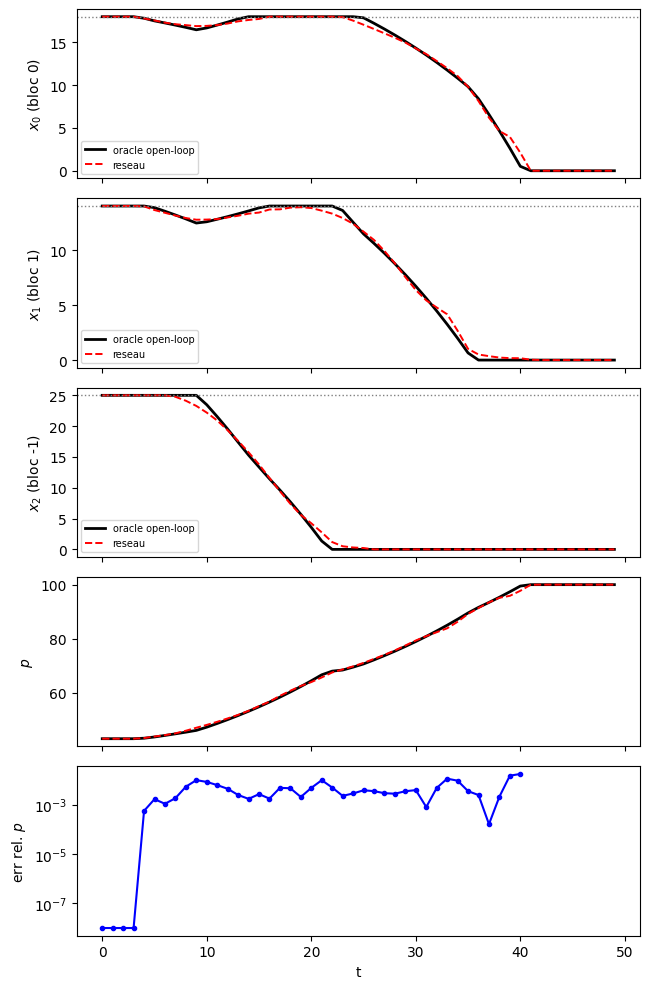


figures -> figs/m3_n3_C_mpe_rollout.png (+ .npz)
[E] run logue dans runs_m3.csv (11 lignes)

ETAGE C (MPE) : ecart a l'open-loop = 1.76% sur le prix. Ce n'est pas une erreur, c'est la mesure de la difference entre les deux concepts.
  Le juge est STEP 9d : le gain de deviation MARKOVIEN doit etre nul.


/tmp/ipykernel_217622/1414262582.py:1654: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  if os.path.exists(p_csv): df = pd.concat([pd.read_csv(p_csv), df], ignore_index=True)


In [2]:
# M3 : N agents (oligopolistes / cartellistes / frange), T periodes, capacite active, PINN.
# Objectif : equilibres de Markov parfaits (MPE) closed-loop a N > 1 joueurs STRATEGIQUES,
# avec graphe d'influence (DAG) : oligopolistes singletons, cartels, frange price-taker,
# capacite kappa active, dynamique hotellingienne.
#
# ============================================================================
# ACQUIS, ET POURQUOI ILS TIENNENT
#
# 1. A UN SEUL JOUEUR STRATEGIQUE, LA DIVERGENCE CL/OL N'EXISTE PAS. Benchekroun &
#    Withagen (2012, Games and Economic Behavior 76(2), 355-374) : les issues du jeu
#    cartel-frange en boucle ouverte et en boucle fermee COINCIDENT quand la frange est
#    preneuse de prix (jeu a la Salant 1976). La litterature sur l'incoherence temporelle
#    porte sur von STACKELBERG, ou le cartel internalise la reaction INSTANTANEE de la
#    frange (dx_f/dx_c). Ce fichier implemente h_i = p - beta*Lam_i - c_i - delta*lambda'_i,
#    donc du Nash-Cournot : feedback = 0 est le resultat ATTENDU, pas un echec.
#    -> il faut >= 2 STRATEGIQUES. C'est la calibration par defaut (a0, a1 + frange).
#
# 2. LE FEEDBACK NE SE LIT PAS DATE PAR DATE. La chaine d'enveloppe donne
#        lambda_i(0) = somme_t delta^t fb_i(t) + delta^T lambda_i(T),
#    et comme lambda croit exactement au taux r, delta^t * fb_i(t) est CONSTANT des lors
#    que fb_i/lambda_i l'est : chaque date interieure contribue le MEME montant, sans
#    attenuation. 0.3% par date sur 20 dates -> ~6% sur mu.
#    MESURE sur l'oracle seul (aucun reseau) : a0 +1.69%, a1 +5.58%. C'est la PREDICTION
#    QUANTITATIVE que l'etage C doit reproduire. Voir CFG["fb_ref"].
#
# 3. LE FEEDBACK EST NUL DES QU'UN STRATEGIQUE EST A UN COIN (J[k,j] = 0). Il faut donc
#    des dates ou DEUX strategiques sont SIMULTANEMENT INTERIEURS. L'ecran ETAPE 1b le
#    verifie avant tout entrainement : 20 dates ici.
#
# 3bis. LA CIBLE DU CO-ETAT EST CLAMPEE A ZERO **APRES** L'AJOUT DU FEEDBACK.
#    lambda = softplus(.)*LREF*G est strictement positif : une cible negative est
#    inatteignable, R_env reste positif en permanence et pousse softplus -> 0. Le feedback
#    etant negatif sur ~37% des points non nuls, clamper la seule marge strategique avant
#    de lui ajouter le feedback laissait passer ce cas.
#
# 4. LA CIBLE DU CO-ETAT DOIT ETRE DURE EN REGIME INTERIEUR (env_hard). Un max(dur,
#    delta*lambda') est un CLIQUET VERS LE HAUT : si le reseau surestime lambda', le max
#    selectionne le bootstrap et court-circuite la cible dure exactement quand elle
#    servirait. Correctif : utiliser le regime, deja connu exactement par `bind`.
#
# 5. LE VALIDATEUR QUI SURVIT A LA DISPARITION DE L'ORACLE, c'est STEP 9, et en son coeur
#    le TEST DE DEVIATION A UN COUP : un profil est un equilibre ssi aucun joueur ne gagne
#    a devier une fois puis a reprendre sa politique. Rivaux GELES -> condition OPEN-LOOP ;
#    rivaux qui REPONDENT -> condition MARKOVIENNE. L'ecart entre les deux gains EST la
#    divergence CL/OL, sans oracle ni grille.
#
# LE MODE D'ECHEC A NE PLUS REPETER : mesurer avec un instrument qu'on n'a pas d'abord
# valide contre une verite. REGLE : tout nouvel objet (gV hors-diagonale, J, feedback,
# grille) passe son propre test de verite AVANT de servir de mesure.
# ============================================================================
#
# ETAGES (toggles cross / sob_off / feedback_only)
#   A. cross=False, sob_off=False : systeme OPEN-LOOP. L'oracle est la VERITE.
#      Attendu : deviation FREEZE ~ 0.
#   B. cross=False, sob_off=True  : on entraine aussi le gradient hors-diagonale via
#      R_soff. OPTIONNEL : 9f a montre que gV croise est deja bon a 7.5% SANS R_soff,
#      dont la cible est auto-referentielle. Ne l'activer que si 9f se degrade.
#   C. cross=True, sob_off=True, feedback_only=True : MPE. On CALCULE J, GV2 et feedback
#      sans les ENTRAINER (R_sob et R_soff annules). L'etage C devient l'etage A plus une
#      ligne : l'injection du feedback dans la cible du co-etat.
#      Attendu : deviation MARKOV ~ 0, deviation FREEZE en HAUSSE, rente deplacee de
#      fb_ref, et 9b Euler s'ecartant de (1+r) de fb/lambda.
#
# COUT : sob_off/cross demandent 3*NAG backward passes avec create_graph.

import os, sys, time, json
import numpy as np
import torch, torch.nn as nn
import torch.nn.functional as F

torch.set_num_threads(4)
torch.set_default_dtype(torch.float64)

######## STEP 0  config
CFG = dict(
    tag="m3_n3_C_mpe", seed=0,
    sampler="mix",           # "mix" = tube+uniforme (defaut) | "tube_oracle" = bras degrade

    # --- ECONOMIE : listes paralleles, un element par AGENT -------------------
    # DEFAUT N=3 : deux oligopolistes singletons (blocs 0 et 1) + une frange (-1).
    #   20 dates ou a0 ET a1 sont simultanement interieurs -> J != 0 -> feedback non nul.
    # Non-regression M2 (N=2) : costs="10,20" kappas="20,30" stocks="700,450" blocs="0,-1"
    #   -> CLOS : coincidence CL/OL demontree et verifiee. Utile comme test de socle.
    costs  = "10,12,20",
    kappas = "18,14,25",
    stocks = "620,410,400",
    blocs  = "0,1,-1",       # entiers distincts = oligopolistes ; egaux = meme cartel ; -1 = frange
    alpha=100.0, beta=1.0, r=0.05, T=50,

    # --- ETAGES ---------------------------------------------------------------
    sob_off=True,            # calculer J, GV2, feedback (necessaire des que cross=True)
    cross=True,              # injecter le feedback dans la cible du co-etat => MPE
    # feedback_only : calculer J/GV2/feedback SANS entrainer R_sob ni R_soff.
    #   9f a mesure gV croise a 7.5% sans R_soff, donc R_soff n'apporte rien ici et porte
    #   tout le risque de sa cible auto-referentielle. L'etage C se reduit alors a
    #   l'etage A + l'injection du feedback : un seul changement, risque minimal.
    #   Mettre False pour reactiver le Sobolev complet (etage B classique).
    # soff_mode : COMMENT superviser le gradient hors-diagonale a l'etage C.
    #   "pathwise" (DEFAUT) : cible MESUREE par differences centrees sur des rollouts de la
    #      politique courante (gv_target_fd). Non auto-referentielle. C'est la bonne
    #      reponse a l'objection "sans supervision explicite, gV derive quand la surface
    #      bascule de OL vers CL". Cout : +25-30% de temps.
    #   "off" : ne superviser que via R_lam et le niveau de V. Mesure a l'etage A :
    #      gV croise 7.5%, diagonal 1.2%/0.7%. Suffisant SI 9f le confirme a l'etage C.
    #   "bellman" : ancienne cible delta*GV2 + M_full, construite depuis le V du reseau.
    #      A converge vers un point fixe auto-coherent mais FAUX (28.9% sur la diagonale
    #      de la frange a N=2). Conserve pour bissection, deconseille.
    soff_mode="pathwise",
    gv_pts=256,              # points du buffer sur lesquels la cible pathwise est calculee
    gv_batch=128,            # sous-echantillon utilise a chaque iteration
    gv_every=400,            # frequence de rafraichissement de la cible

    # --- TOGGLES DE BISSECTION (RUN 9). Ne jamais en bouger deux dans le meme run. ---
    sob_ok_mask=True,        # SOB_OK = lignes canoniques de A (False -> ones : RUN 6, casse)
    G_in_V=True,             # facteur G(t) dans la construction de V
    norm_G_bell=True,        # R_bell divise par G_t
    norm_G_lam=True,         # R_env/R_sob/R_lam divises par G_t
    vref_per_agent=False,    # VREF vectoriel alpha*S0_i au lieu du scalaire alpha*max(S0)

    # Cible Monte-Carlo TD(1) pour V, sur le bras TUBE PUR uniquement. VALIDE.
    #   R_bell est un residu a UN pas : il peut etre minuscule pendant que V derive de 25%.
    #   Le buffer fait deja des rollouts complets, la cible est donc gratuite et exacte.
    use_vmc=True, w_vmc=1.0,

    # Cible DURE pour lambda en regime INTERIEUR (voir acquis 4 en en-tete). VALIDE :
    # a supprime le biais de niveau (+2.1% -> +0.8%) et divise par 4 l'erreur aux bascules.
    env_hard=True,

    # Ecran de feedback sur l'ORACLE seul. DESACTIVE : son travail est fait, le resultat
    # est fige dans fb_ref ci-dessous. Remettre True si la calibration change.
    run_fb_screen=False, fb_h=1e-2,
    # PREDICTION MESUREE de l'ecart CL/OL sur la rente, un element par agent, en fraction
    # de mu. C'est le juge quantitatif de l'etage C (STEP 10).
    fb_ref="0.0169,0.0558,0.0",

    # --- ETAPE 1b : ecran de calibration (cout : quelques secondes, aucun entrainement) ---
    run_screen=True,

    # --- ETAPE 2 : grille MPE (N = 2 ou 3). Cout ~O(ng^N * nx * nbr * T). --------
    #   N=2 : ng=160 nx=31 -> ~30 s.   N=3 : ng=32 nx=15 -> ~2-4 min.
    #   La grille n'est PAS le validateur principal (sa precision plafonne vers 0.5%
    #   en 2D et bien au-dela en 3D). C'est STEP 9 qui valide. La grille sert de
    #   controle croise independant.
    run_mpe_grid=False, mpe_ng=32, mpe_nx=15, mpe_nbr=6,

    # --- reseau ---------------------------------------------------------------
    width=128, emb_dim=16, depth=3,

    # --- loss / sampler -------------------------------------------------------
    w_sob=0.01, w_sob_off=0.1, frac_unif=0.05, frac_gauss=0.25, frac_decor=0.0, box=1.25,
    buf_paths=64, buf_every=100, buf_lo=0.70, buf_hi=1.25,

    # --- entrainement ---------------------------------------------------------
    # ACCELERATION : la loss plafonne vers 15-18k iterations, 20000 suffit. L-BFGS ne
    # converge pas des que sob_off=True (loss_pre == loss_post, Wolfe echoue au premier
    # pas) : le mettre a 0. buf_every 100 au lieu de 50 : ~5% de gain, effet negligeable
    # sur le tube. Total ~-45% de temps par rapport a la configuration etage A.
    iters=20000, batch=512, lr=1e-3, lbfgs_outer=0,

    diag_every=0,            # instrumentation R9bis : decomposition loss + |grad| par residu

    # --- eval -----------------------------------------------------------------
    snap_eps=1e-4, n_field=24, or_nbis=30, or_nouter=15,
    t_decouple="10,20,30", make_figs=True,

    # --- STEP 9 : batterie de coherence SANS ORACLE ---------------------------
    run_step9=True,
    dev_eps_rel=0.15,        # amplitude de deviation, en fraction de la capacite du pas
    dev_n_eps=13,            # points de la grille de deviation (impair : 0 au centre)
    dev_n_dates=5,           # dates sondees
    dev_skip_ext=True,       # exclure les dates d'extinction : sinon le max est pilote
                             # par elles, exactement le defaut deja corrige sur err_p
    fd_rel=5e-3,             # pas relatif des differences finies (gV, J)
    s9_J=False,              # 9g : cablage de J (autodiff vs FD du reseau). Valide 4.7e-5.
    s9_Jor=True,             # 9h : J du reseau vs J de l'ORACLE. Teste l'ECONOMIE, pas le
                             # cablage. C'est le test qui manquait : 9g ne compare le
                             # reseau qu'a lui-meme.
    s9_Jor_dates=3,
)

for a in sys.argv[1:]:
    if "=" not in a: continue
    k, v = a.split("=", 1)
    if k not in CFG: continue
    CFG[k] = (v.lower() in ("1", "true")) if isinstance(CFG[k], bool) else type(CFG[k])(v)

alpha, beta, r, T = CFG["alpha"], CFG["beta"], CFG["r"], CFG["T"]
delta = 1.0/(1.0+r)
C_np   = np.array([float(u) for u in CFG["costs"].split(",")])
KAP_np = np.array([float(u) for u in CFG["kappas"].split(",")])
S0_np  = np.array([float(u) for u in CFG["stocks"].split(",")])
BLOC   = np.array([int(u)   for u in CFG["blocs"].split(",")])
NAG = len(C_np)
assert len(KAP_np) == len(S0_np) == len(BLOC) == NAG, "listes d'agents de longueurs differentes"

# masque de conduite : A[i,j] = 1 ssi i et j sont dans le meme bloc (>=0). Frange : ligne nulle.
# cartelliste -> Lambda_i = Q^C (somme du bloc) ; oligopoliste -> Lambda_i = x_i ; frange -> 0.
A_np = np.zeros((NAG, NAG))
for i in range(NAG):
    if BLOC[i] < 0: continue
    for j in range(NAG):
        if BLOC[j] == BLOC[i]: A_np[i, j] = 1.0
IS_FRINGE = BLOC < 0

# SOB_OK : masque de R_lam SEULEMENT (l'identite dV_i/dS_i = lambda_i). Cette identite
# n'est valide que si coef[i,i] = 0, c'est-a-dire pour un OLIGOPOLISTE SINGLETON a
# l'optimum interieur (theoreme de l'enveloppe : le terme de choix propre s'annule).
#   singleton interieur : coef_ii = p - c_i - beta*x_i - delta*GV2_ii = 0
#   cartelliste         : coef_ii = beta*(Q^C - x_i) != 0
#   frange              : coef_ii = -beta*x_f        != 0
# R_sob, l'enveloppe universelle derivee de Bellman, n'a jamais eu de masque et n'en veut
# pas. RUN 6 (SOB_OK = ones) imposait deux equations incompatibles au meme objet. Ne pas
# y revenir.
SOB_OK = (torch.tensor((A_np == np.eye(NAG)).all(1).astype(float))
          if CFG["sob_ok_mask"] else torch.ones(NAG))

if CFG["cross"] and not CFG["sob_off"]:
    print("[!] cross=True force sob_off=True (le feedback depend de dV_i/dS_k)")
    CFG["sob_off"] = True

torch.manual_seed(CFG["seed"]); np.random.seed(CFG["seed"])
A    = torch.tensor(A_np)
COST = torch.tensor(C_np)
KAP  = torch.tensor(KAP_np)
S0V  = torch.tensor(S0_np)
DEN  = beta*(1.0 + torch.diagonal(A))   # pas de Newton du clamp : dh_i/dx_i = -beta(1+A_ii).
                                        # Ce n'est PAS un parametre de conduite : la conduite
                                        # est entierement dans Lambda = A x.
OFF  = 1.0 - torch.eye(NAG)             # masque k != i
VREF = (alpha*S0V) if CFG["vref_per_agent"] else (alpha*S0_np.max())
LREF = alpha                            # rente bornee par le choke price
XREF = torch.minimum(KAP, S0V)          # echelle des QUANTITES (pas des stocks)
W_SOB, W_SOFF = CFG["w_sob"], CFG["w_sob_off"]
FRAC_UNIF, FRAC_GAUSS, BOX, SNAP_EPS = CFG["frac_unif"], CFG["frac_gauss"], CFG["box"], CFG["snap_eps"]

# STRAT[i] = 1 pour un agent STRATEGIQUE (ligne non nulle dans A), 0 pour la frange.
# Une frange preneuse de prix n'a pas de terme de feedback. VALIDE au RUN 13b.
STRAT = torch.tensor((~IS_FRINGE).astype(float))
STRAT_IDX = [i for i in range(NAG) if not IS_FRINGE[i]]

print(f"STEP 0 : {NAG} agents | blocs={list(BLOC)} | strategiques={STRAT_IDX} "
      f"| frange={list(np.nonzero(IS_FRINGE)[0])}")
print(f"         A =\n{A_np.astype(int)}")

def growth_t(ti):
    """G(t) = (1+r)^(t-(T-1)) : vaut 1 a la derniere date de decision, ~0.09 en t=0.
       C'est EXACTEMENT le facteur de croissance de Hotelling : lambda_i(t) = mu_i(1+r)^t.
       Ecrire lam = softplus(l)*LREF*G ramene donc la cible de la tete co-etat a une
       CONSTANTE en t le long du sentier. Preconditionnement exact, adosse a la theorie."""
    return (1.0+r)**(ti.double() - (T-1))

######### STEP 1  oracle open-loop a N joueurs   [INCHANGE, valide analytiquement]

# rentes initiales mu_i, lambda_i(t) = mu_i*(1+r)^t. A rentes donnees, chaque periode est un
# equilibre STATIQUE a couts effectifs c_i + lambda_i(t) (gere les coins nativement).
# On cherche N scalaires au lieu de N*T inconnues et 3^(N*T) regimes.
# Trois boucles : (a) point fixe de meilleures reponses intra-periode, vectorise sur t ;
# (b) methode de tir : bissection sur mu_i pour atteindre Sigma_t x_i = S_i (le cumul est
# strictement decroissant en mu_i) ; (c) Gauss-Seidel sur les agents, car les mu sont
# couples par le prix. Cout LINEAIRE en N, contre O(nbis^N) pour des bissections imbriquees.
NITER_BR = 60

def static_period_N(ceff, kap):
    """ceff [T_,NAG] -> x [T_,NAG]. h_i = 0 donne
       x_i = [alpha - c_i - beta*somme_{j!=i}(1+A_ij)x_j] / (beta*(1+A_ii)), puis clip [0,kappa_i]."""
    x = np.zeros_like(ceff)
    idx = np.arange(NAG)
    for _ in range(NITER_BR):
        for i in range(NAG):
            o = idx[idx != i]
            num = alpha - ceff[:, i] - beta*((1.0 + A_np[i, o])*x[:, o]).sum(1)
            x[:, i] = np.clip(num/(beta*(1.0 + A_np[i, i])), 0.0, kap[i])
    return x

def totals_N(mu, T_, kap, C=None):
    C = C_np if C is None else C
    g = (1.0+r)**np.arange(T_)
    return static_period_N(C[None, :] + mu[None, :]*g[:, None], kap)

def solve_oracle_N(S_, T_, kap=None, nbis=None, nouter=None, C=None):
    kap = KAP_np if kap is None else kap
    nbis = CFG["or_nbis"] if nbis is None else nbis
    nouter = CFG["or_nouter"] if nouter is None else nouter
    mu = np.zeros(NAG); conv = np.inf
    for _ in range(nouter):
        mu_old = mu.copy()
        for i in range(NAG):
            m0 = mu.copy(); m0[i] = 0.0
            if totals_N(m0, T_, kap, C)[:, i].sum() <= S_[i]:   # stock non contraignant
                mu[i] = 0.0; continue
            lo, hi = 0.0, alpha
            for _ in range(nbis):
                m = .5*(lo+hi); mt = mu.copy(); mt[i] = m
                if totals_N(mt, T_, kap, C)[:, i].sum() > S_[i]: lo = m
                else: hi = m
            mu[i] = .5*(lo+hi)
        conv = np.max(np.abs(mu-mu_old))
        if conv < 1e-10: break
    solve_oracle_N.last_conv = float(conv)      # Gauss-Seidel non certifie : on le journalise
    x = totals_N(mu, T_, kap, C)
    return mu, x, alpha - beta*x.sum(1)
solve_oracle_N.last_conv = np.nan

t_or = time.time()
mu_a, xa, pa = solve_oracle_N(S0_np, T, nbis=60, nouter=40)
print(f"STEP 1 oracle ok ({time.time()-t_or:.0f}s) : mu={np.round(mu_a,3)}  "
      f"(convergence Gauss-Seidel {solve_oracle_N.last_conv:.1e})")
for i in range(NAG):
    ai = xa[:, i] > 1e-9
    print(f"  agent {i} (bloc {BLOC[i]:2d}, c={C_np[i]:5.1f}, kap={KAP_np[i]:5.1f}) : "
          f"actif t<={int(np.max(np.nonzero(ai))) if ai.any() else -1}, "
          f"kappa liante {int((xa[:,i]>KAP_np[i]-1e-6).sum())}/{T}, "
          f"cumul {xa[:,i].sum():.1f}/{S0_np[i]:.1f}")
assert np.abs(xa.sum(0) - S0_np).max() < 1e-4, "epuisement viole"
_tlast = int(np.max(np.nonzero(xa.sum(1) > 1e-9)))
assert _tlast < T-1, f"horizon trop court (production encore en t={_tlast})"

# non-regression M2 (N=2 seulement) : l'oracle doit redonner mu=(12.821, 21.757).
if (NAG == 2 and np.allclose(C_np, [10., 20.]) and np.allclose(S0_np, [700., 450.])
        and np.allclose(KAP_np, [20., 30.]) and BLOC[1] < 0):
    assert abs(mu_a[0]-12.821) < 1e-2 and abs(mu_a[1]-21.757) < 1e-2, "oracle N incompatible avec M2"
    print("  [non-regression M2 : mu retrouve]")

SA_T = torch.tensor(S0_np[None, :] - np.concatenate([np.zeros((1, NAG)), np.cumsum(xa, 0)[:-1]], 0))

# regimes, par agent : interieur = ni a zero ni a kappa. C'est la SEULE zone ou lambda_i
# est identifie (ailleurs la FOC est inactive) et la seule ou dx_i/dS_j != 0.
INT = (xa > 1e-6) & (xa < KAP_np[None, :] - 1e-6)
FB_REF = np.array([float(u) for u in CFG["fb_ref"].split(",")])[:NAG]

# ============================================================================
# ETAPE 1b : ECRAN DE CALIBRATION. Cout nul, aucun entrainement.
#   Le feedback markovien vaut somme_{k!=i} coef[i,k]*J[k,j] avec J[k,j] = dx_k/dS_j.
#   J[k,j] est identiquement NUL si l'agent k est a un coin (x_k = 0 ou x_k = kappa_k) :
#   sa decision ne repond alors plus a l'etat. Il faut donc des dates ou DEUX AGENTS
#   STRATEGIQUES sont SIMULTANEMENT INTERIEURS, sinon l'etage C n'a rien a mesurer et
#   l'etage B entraine des objets multiplies par zero.
#   C'est exactement ce qui s'est passe a la calibration M2 : a0 colle a kappa pendant
#   toute la vie de la frange -> J[1,0] = 0 -> feedback = 0 par construction.
#   CRITERE : au moins ~10 dates de recouvrement pour une paire strategique.
# ============================================================================
def screen_regimes(x, kap=None):
    kap = KAP_np if kap is None else kap
    itr = (x > 1e-6) & (x < kap[None, :] - 1e-6)
    out = {}
    for a_ in range(len(STRAT_IDX)):
        for b_ in range(a_+1, len(STRAT_IDX)):
            i, j = STRAT_IDX[a_], STRAT_IDX[b_]
            out[(i, j)] = int((itr[:, i] & itr[:, j]).sum())
    return itr, out

if CFG["run_screen"]:
    _itr, _ov = screen_regimes(xa)
    print("\nETAPE 1b  ecran de calibration")
    for i in range(NAG):
        print(f"  agent {i} : interieur sur {int(_itr[:,i].sum()):2d} dates "
              f"| kappa {int((xa[:,i]>KAP_np[i]-1e-6).sum()):2d} | zero {int((xa[:,i]<=1e-6).sum()):2d}")
    if _ov:
        for (i, j), n in _ov.items():
            flag = "OK" if n >= 10 else "INSUFFISANT (feedback non identifie)"
            print(f"  recouvrement interieur strategiques ({i},{j}) : {n:2d} dates  -> {flag}")
    else:
        print("  [!] UN SEUL agent strategique : la coincidence CL/OL est un THEOREME")
        print("      (Benchekroun & Withagen 2012). L'etage C n'a rien a mesurer ici.")
        print("      Passer a >= 2 strategiques, p.ex. blocs='0,1,-1'.")

# ============================================================================
# ETAPE 2 : GRILLE MPE (induction retrograde, N = 2 ou 3). Independante de PyTorch.
#
#   DECISION INTRA-PERIODE : maximisation DIRECTE, sans aucune derivee de V.
#     obj_i(x_i) = (alpha - c_i - beta*somme_{j!=i}(1+A_ij)x_j)*x_i
#                  - (beta(1+A_ii)/2)*x_i^2 + delta*V_i(S - x)
#     d(obj_i)/dx_i = p - beta*Lambda_i - c_i - delta*dV_i/dS_i  =  h_i, EXACTEMENT,
#     et pour toute conduite. Frange : A_ii = A_ij = 0 -> derivee = p - c_f - delta*lam_f,
#     la condition de preneur de prix. C'est un potentiel, pas le profit : c'est ce qui
#     permet de traiter la frange par un argmax alors qu'elle ne maximise pas son profit.
#   Aucun terme de feedback a coder : il est contenu dans le V calcule, puisque
#   sigma_{-i}(S) depend de l'etat.
#
#   PORTE D'ACCEPTATION OBLIGATOIRE : le TEST MONO-AGENT. En mettant tous les stocks
#   rivaux a zero, le jeu disparait, MPE == controle optimal, et l'oracle open-loop est
#   la verite EXACTE. Toute difference est de l'erreur numerique pure. Sans ce test on ne
#   sait pas si un ecart CL/OL est de l'economie ou du bruit.
#   PRECISION ATTEINTE : ~0.5% en 2D a ng=160. Ce plafond vient de l'interpolation
#   multilineaire (pente en escalier). La grille est donc un CONTROLE CROISE, pas le
#   validateur principal : c'est STEP 9 qui valide.
# ============================================================================
def _interp_ml(Z, coords, grids):
    """Interpolation multilineaire sur grille reguliere. Z de forme (ng,)*N."""
    N = len(grids); ng = Z.shape[0]
    idx, fr = [], []
    for k in range(N):
        d = grids[k][1]
        aa = np.clip(coords[k]/d, 0.0, ng-1-1e-9)
        i0 = aa.astype(np.intp); idx.append(i0); fr.append(aa-i0)
    out = 0.0
    for corner in range(1 << N):
        w = 1.0; ii = []
        for k in range(N):
            b = (corner >> k) & 1
            w = w*(fr[k] if b else (1.0-fr[k]))
            ii.append(idx[k]+b)
        out = out + w*Z[tuple(ii)]
    return out

def mpe_grid(ng=None, nx=None, nbr=None):
    ng = ng or CFG["mpe_ng"]; nx = nx or CFG["mpe_nx"]; nbr = nbr or CFG["mpe_nbr"]
    assert NAG <= 3, "grille MPE : N <= 3 (le cout explose au-dela ; c'est l'argument du PINN)"
    grids = [np.linspace(0.0, S0_np[i], ng) for i in range(NAG)]
    G = np.meshgrid(*grids, indexing="ij")
    shp = G[0].shape
    V = [np.zeros(shp) for _ in range(NAG)]
    XPOL = np.zeros((T, NAG) + shp)
    u = np.linspace(0.0, 1.0, nx); resid = 0.0
    for t in reversed(range(T)):
        if t == T-1:
            # derniere date de decision : aucune continuation, on extrait tout le possible.
            # A ecrire explicitement : interpoler un tableau de zeros n'est pas neutre
            # apres clip aux bords, et cela introduisait une pente parasite.
            x = [np.minimum(KAP_np[i], G[i]) for i in range(NAG)]
        else:
            x = [np.zeros(shp) for _ in range(NAG)]
            for it_br in range(nbr):
                xold = [xx.copy() for xx in x]
                for i in range(NAG):
                    hi = np.minimum(KAP_np[i], G[i])
                    cand = u.reshape((1,)*NAG + (nx,))*hi[..., None]
                    coords = []
                    for k in range(NAG):
                        base = (G[i][..., None] - cand) if k == i else (G[k]-x[k])[..., None]
                        coords.append(np.ascontiguousarray(
                            np.broadcast_to(base, cand.shape)).ravel())
                    cont = _interp_ml(V[i], coords, grids).reshape(cand.shape)
                    lin = alpha - C_np[i] - beta*sum((1.0+A_np[i, k])*x[k]
                                                     for k in range(NAG) if k != i)
                    obj = (lin[..., None]*cand - 0.5*beta*(1.0+A_np[i, i])*cand**2
                           + delta*cont)
                    x[i] = np.take_along_axis(cand, obj.argmax(-1)[..., None], -1)[..., 0]
                if it_br == nbr-1:
                    resid = max(resid, max(float(np.abs(x[i]-xold[i]).max()) for i in range(NAG)))
        p = alpha - beta*sum(x)
        Sp = [np.ascontiguousarray(G[i]-x[i]).ravel() for i in range(NAG)]
        if t == T-1:
            V = [(p - C_np[i])*x[i] for i in range(NAG)]
        else:
            V = [(p - C_np[i])*x[i] + delta*_interp_ml(V[i], Sp, grids).reshape(shp)
                 for i in range(NAG)]
        for i in range(NAG): XPOL[t, i] = x[i]
    return grids, XPOL, resid

def mpe_rollout(grids, XPOL, S_init=None):
    """Deroule la politique MPE de la grille depuis S_init. -> X [T,NAG], P [T]."""
    S = np.array(S_init if S_init is not None else S0_np, dtype=float)
    X, P = [], []
    for t in range(T):
        co = [np.array([S[k]]) for k in range(NAG)]
        xt = np.array([float(_interp_ml(XPOL[t, i], co, grids)[0]) for i in range(NAG)])
        xt = np.clip(np.minimum(xt, S), 0.0, None)
        X.append(xt.copy()); P.append(alpha - beta*xt.sum()); S = S - xt
    return np.array(X), np.array(P)

# masque des dates d'extinction (+/-1), reutilise en STEP 5.
_ext = np.zeros(T, dtype=bool)
for i in range(NAG):
    _mi = np.nonzero(xa[:, i] > 1e-9)[0]
    if _mi.size: _ext[max(0, _mi[-1]-1):_mi[-1]+2] = True

MPE = {}
Xcl = Pcl = None
if CFG["run_mpe_grid"] and NAG <= 3:
    _tg = time.time()
    _grids, _XPOL, _rs = mpe_grid()
    # PORTE : verite mono-agent. Rivaux a stock nul -> plus de jeu -> l'oracle est exact.
    _Smono = S0_np.copy()
    for k in range(1, NAG): _Smono[k] = 0.0
    _, _xmo, _pmo = solve_oracle_N(_Smono, T, nbis=60, nouter=40)
    _amo = _xmo[:, 0] > 1e-9
    Xmo, Pmo = mpe_rollout(_grids, _XPOL, _Smono)
    _emp = float(np.abs(Pmo[_amo]-_pmo[_amo]).max()/_pmo.max())
    Xcl, Pcl = mpe_rollout(_grids, _XPOL)
    _a = xa.sum(1) > 1e-6; _keepg = _a & (~_ext)
    _e = np.abs(Pcl[_a]-pa[_a])/pa.max()
    MPE = dict(ng=CFG["mpe_ng"], br_resid=_rs, mono_err_p=_emp,
               gap_p=float(_e.max()),
               gap_p_noext=float(np.abs(Pcl[_keepg]-pa[_keepg]).max()/pa.max()),
               gap_p_q90=float(np.quantile(_e, .90)),
               gap_p0=float(abs(Pcl[0]-pa[0])/pa[0]), cum=Xcl.sum(0).tolist())
    print(f"\nETAPE 2  GRILLE MPE ({time.time()-_tg:.0f}s, ng={CFG['mpe_ng']}, nx={CFG['mpe_nx']})")
    print(f"  PORTE mono-agent (erreur numerique pure) : {_emp:.2%} "
          f"{'OK' if _emp < 5e-3 else '-> plancher de la grille, tout ecart CL/OL en dessous est du bruit'}")
    print(f"  residu BR intra-periode : {_rs:.3f} bbl")
    print(f"  epuisement CL {np.round(Xcl.sum(0),1)} / {S0_np}")
    print("   t  | " + " | ".join(f"a{i} CL/OL" for i in range(NAG)) + " |  p CL/OL")
    for tt in [0, T//5, 2*T//5, 3*T//5, _tlast]:
        s = " | ".join(f"{Xcl[tt,i]:5.1f}/{xa[tt,i]:5.1f}" for i in range(NAG))
        print(f"  {tt:3d} | {s} | {Pcl[tt]:6.2f}/{pa[tt]:6.2f}")
    print(f"  ECART CL/OL : max {MPE['gap_p']:.2%} | hors ext {MPE['gap_p_noext']:.2%} "
          f"| q90 {MPE['gap_p_q90']:.2%} | t=0 {MPE['gap_p0']:.2%}")
    print(f"  A COMPARER au plancher mono-agent {_emp:.2%}. En dessous, ce n'est pas de l'economie.")

#####  STEP 2  reseaux

# un reseau par agent, trois tetes (politique z, valeur w, co-etat l), tronc partage.
# Chaque reseau prend l'etat COMPLET S : c'est la definition du Markov, et c'est ce qui rend
# les derivees croisees dV_i/dS_j et dsigma_k/dS_j calculables par autodiff.
# NOTE DAG : le nombre de reseaux VALEUR utiles = nombre d'agents STRATEGIQUES, pas N.
# La tete valeur de la frange n'est lue par aucune equation une fois STRAT applique ; sa
# tete POLITIQUE, elle, est indispensable (J[f,.] entre dans le feedback des strategiques).
# - ancrage terminal EXACT par 1{t<T}
# - SiLU : le residu Sobolev a besoin de dV/dS non trivial ; le kink est deja dans
#   l'architecture via les min(), donc rien de non lisse a apprendre.
class Net(nn.Module):
    def __init__(s, width, emb_dim, depth):
        super().__init__()
        s.emb = nn.Embedding(T+1, emb_dim)          # T+1 : l'index t=T existe, neutralise par alive
        nn.init.normal_(s.emb.weight, std=0.1)
        layers, d = [], NAG + emb_dim
        for _ in range(depth):
            layers += [nn.Linear(d, width), nn.SiLU()]; d = width
        s.trunk = nn.Sequential(*layers)
        s.head_z = nn.Linear(width, 1); s.head_w = nn.Linear(width, 1); s.head_l = nn.Linear(width, 1)
    def forward(s, S, ti):
        h = s.trunk(torch.cat([S/S0V, s.emb(ti)], dim=-1))
        return s.head_z(h).squeeze(-1), s.head_w(h).squeeze(-1), s.head_l(h).squeeze(-1)

NETS = nn.ModuleList([Net(CFG["width"], CFG["emb_dim"], CFG["depth"]) for _ in range(NAG)])
PARAMS = list(NETS.parameters())

def forward_all(S, ti, snap=False):
    """S:[B,NAG] ti:[B] long -> x, V, lam tous [B,NAG]"""
    z, w, l = [], [], []
    for i in range(NAG):
        zi, wi, li = NETS[i](S, ti); z.append(zi); w.append(wi); l.append(li)
    z = torch.stack(z, -1); w = torch.stack(w, -1); l = torch.stack(l, -1)
    # x = min(min(S,kappa), softplus(z)) : atteint kappa EXACTEMENT (coin superieur franc),
    # garantit 0 <= x <= S par construction. La faisabilite n'est jamais a apprendre.
    x = torch.minimum(torch.minimum(S, KAP), F.softplus(z))
    if snap:                                        # EVAL uniquement (zone morte a l'entrainement)
        x = torch.where(x < SNAP_EPS, torch.zeros_like(x), x)
    alive = (ti < T).double().unsqueeze(-1)
    G = growth_t(ti).unsqueeze(-1) if CFG["G_in_V"] else torch.ones_like(alive)
    # V libre. Les deux ancrages testes sont morts et ne doivent pas revenir :
    #   * (S/S0V) : annule V_i et TOUS ses gradients sur l'hyperplan S_i=0, donc detruit
    #     l'ancre terminale de la chaine arriere de R_sob/R_soff.
    #   * (* S)   : impose V_i = lambda_i*S_i, i.e. courbure nulle en S, alors que la
    #     courbure est l'objet meme que l'etage B doit apprendre (mesure : facteur 1.7).
    V   = alive*F.softplus(w) * VREF*G
    lam = alive*F.softplus(l)*LREF*G
    return x, V, lam


# ---- outils PATHWISE : valeur et gradient MESURES sous la politique courante ----
# Ils ne comparent le reseau qu'a ce qu'il produit lui-meme en deroulant sa propre
# politique jusqu'a T. Aucune cible bootstrap, aucun oracle. C'est ce qui les rend
# utilisables a l'etage C, ou la surface de valeur bascule de open-loop vers closed-loop.
def mc_value(Sb, tb):
    """Sb [M,NAG], tb [M] -> V^MC [M,NAG] sous la politique COURANTE."""
    with torch.no_grad():
        S = Sb.clone(); XS, PS = [], []
        for t in range(T):
            live = ((tb + t) < T).double().unsqueeze(-1)
            x, _, _ = forward_all(S, torch.clamp(tb + t, max=T), snap=True)
            x = x*live
            XS.append(x.clone()); PS.append(alpha - beta*x.sum(-1, keepdim=True))
            S = S - x
        Vmc = torch.zeros(Sb.shape[0], NAG)
        for t in reversed(range(T)):
            Vmc = (PS[t] - COST)*XS[t] + delta*Vmc
    return Vmc

def gv_target_fd(S0b, t0b, dlt=None, freeze=False):
    """S0b [M,NAG], t0b [M] -> [M,NAG,NAG] cible de dV_i/dS_j, difference CENTREE."""
    dlt = (CFG["fd_rel"]*S0V) if dlt is None else dlt
    M = S0b.shape[0]
    blocks = [S0b]
    for j in range(NAG):
        ej = torch.zeros(NAG); ej[j] = 1.0
        blocks += [S0b + ej*dlt, torch.clamp(S0b - ej*dlt, min=0.0)]
    base = torch.cat(blocks, 0)
    tb = t0b.repeat(2*NAG+1)
    if not freeze:
        Vmc = mc_value(base, tb)
    else:
        # rivaux GELES sur la trajectoire NON perturbee : chaque colonne j a son propre
        # masque, d'ou la boucle explicite (non vectorisable en une expression).
        with torch.no_grad():
            Sref = S0b.clone(); XR = []
            for t in range(T):
                live = ((t0b + t) < T).double().unsqueeze(-1)
                xr_, _, _ = forward_all(Sref, torch.clamp(t0b + t, max=T), snap=True)
                xr_ = xr_*live; XR.append(xr_.clone()); Sref = Sref - xr_
            Vmc = torch.zeros(base.shape[0], NAG)
            for j in range(NAG):
                for sgn, off in ((+1, 1+2*j), (-1, 2+2*j)):
                    S = base[off*M:(off+1)*M].clone()
                    XS, PS = [], []
                    for t in range(T):
                        live = ((t0b + t) < T).double().unsqueeze(-1)
                        xp, _, _ = forward_all(S, torch.clamp(t0b + t, max=T), snap=True)
                        x = xp*live
                        for k in range(NAG):
                            if k != j: x[:, k] = XR[t][:, k]
                        x = torch.minimum(x, S)
                        XS.append(x.clone()); PS.append(alpha - beta*x.sum(-1, keepdim=True))
                        S = S - x
                    v = torch.zeros(M, NAG)
                    for t in reversed(range(T)):
                        v = (PS[t] - COST)*XS[t] + delta*v
                    Vmc[off*M:(off+1)*M] = v
            Vmc[:M] = mc_value(base[:M], t0b)
    out = torch.zeros(M, NAG, NAG)
    for j in range(NAG):
        out[:, :, j] = (Vmc[(1+2*j)*M:(2+2*j)*M] - Vmc[(2+2*j)*M:(3+2*j)*M])/(2*dlt[j])
    return out

_GS = _GTT = _GTGT = None
def refresh_gv_target(m=None):
    """Cible pathwise du gradient, sur un sous-echantillon du buffer. Analogue de _VBUF."""
    global _GS, _GTT, _GTGT
    m = m or CFG["gv_pts"]
    idx = torch.randint(0, _BUF[0].shape[0], (m,))
    _GS, _GTT = _BUF[0][idx].clone(), _BUF[1][idx].clone()
    _GTGT = gv_target_fd(_GS, _GTT).detach()

def gv_reg_loss(nb=None):
    """Regression de gV sur la cible MESUREE. Terme SEPARE : ne touche ni residuals ni
       sample_states. Masque STRAT sur les lignes (V de la frange n'est lue par rien)."""
    nb = nb or CFG["gv_batch"]
    k = torch.randint(0, _GS.shape[0], (min(nb, _GS.shape[0]),))
    Sg_ = _GS[k].clone().requires_grad_(True); tg_ = _GTT[k]
    _, Vg_, _ = forward_all(Sg_, tg_)
    g_ = torch.stack([torch.autograd.grad(Vg_[:, i].sum(), Sg_, create_graph=True)[0]
                      for i in range(NAG)], dim=1)
    Gt_ = growth_t(tg_).view(-1, 1, 1)
    w_ = STRAT.view(1, -1, 1)
    return (((g_ - _GTGT[k])/(LREF*Gt_)*w_)**2).sum((-1, -2)).mean()

#####  STEP 3  residus

# FOC -> politique ; enveloppe -> co-etat ; Bellman -> valeur ; Sobolev -> lie les deux.
# Chaque agent n'a que SA PROPRE FOC. Ce qui fabrique l'equilibre : p n'est PAS detache
# (le gradient du residu de i remonte dans les reseaux de tous les autres) et chaque reseau
# lit l'etat complet. Tout le reste est de la regression supervisee sur cible bootstrap
# detachee : schema semi-gradient.
# R_foc est EXACT et non approche : h_i etant affine en x_i de pente -beta(1+A_ii), le pas
# x + h/DEN atterrit sur la racine exacte, et le clamp projette. R_foc = 0 <=> x est la
# meilleure reponse contrainte exacte etant donne (p, Lambda, lambda').
def residuals(S, ti):
    S = S.detach().requires_grad_(True)
    x, V, lam = forward_all(S, ti)
    p = alpha - beta*x.sum(-1, keepdim=True)
    Lam = x @ A.T
    S2 = S - x
    _, V2, lam2 = forward_all(S2, ti+1)
    lam2d = lam2.detach()
    cap = torch.minimum(S, KAP)

    h = p - beta*Lam - COST - delta*lam2d
    R_foc = x - torch.clamp(x + h/DEN, torch.zeros_like(x), cap)

    gV = torch.stack([torch.autograd.grad(V[:, i].sum(), S, create_graph=True)[0]
                      for i in range(NAG)], dim=1)

    # Multiplier par 0.0 preserve le lien au graphe d'autodifferenciation
    feedback = x * 0.0
    R_soff = gV * 0.0
    R_sob = x * 0.0

    if CFG["sob_off"]:
        J   = torch.stack([torch.autograd.grad(x[:, k].sum(), S, create_graph=True)[0]
                           for k in range(NAG)], dim=1)

        GV2 = torch.stack([torch.autograd.grad(V2[:, i].sum(), S2, create_graph=True)[0]
                           for i in range(NAG)], dim=1)
        # coef[i,k] = d(pi_i)/d(x_k) - delta*dV_i'/dS_k'
        #           = -beta*x_i - delta*GV2[i,k]  (k!=i)   |   + (p - c_i)  (k=i)
        coef = -beta*x.unsqueeze(-1) - delta*GV2 + torch.diag_embed(p - COST)

        # M_full  : dV_i/dS_j = delta*GV2[i,j] + M_full[i,j]. Somme sur TOUS les k.
        # M_cross : somme sur k != i seulement. Le terme diagonal coef_ii*J_ii n'est PAS du
        #           feedback, c'est le coin de conduite.
        M_full  = torch.einsum('bik,bkj->bij', coef,     J)
        M_cross = torch.einsum('bik,bkj->bij', coef*OFF, J)

        feedback = torch.diagonal(M_cross, dim1=1, dim2=2)
        R_soff   = (gV - (delta*GV2 + M_full).detach())*OFF
        # ATTENTION : cette cible est AUTO-REFERENTIELLE (construite depuis le V du
        # reseau lui-meme, ancre terminale degeneree a 0). R_sob peut converger vers un
        # point fixe auto-coherent mais faux la ou il est le seul residu actif. C'est la
        # raison de feedback_only. Alternative mesuree : gv_target_fd (9f).
        R_sob = torch.diagonal(gV, dim1=1, dim2=2) - (delta*torch.diagonal(GV2, dim1=1, dim2=2)
                                            + torch.diagonal(M_full, dim1=1, dim2=2)).detach()

        # Une frange PRENEUSE DE PRIX n'a pas de terme de feedback. Une fois feedback_f = 0,
        # GV2[f,:] n'entre plus dans aucune equation.
        R_soff   = R_soff * STRAT.view(1, -1, 1)
        feedback = feedback * STRAT

        if CFG["soff_mode"] != "bellman":
            # "off" et "pathwise" : on garde J, GV2 et feedback, on annule les residus
            # Sobolev construits depuis le V du reseau. En mode "pathwise" la supervision
            # du gradient est assuree par un terme SEPARE, sur cible mesuree (STEP 4).
            R_sob = R_sob*0.0; R_soff = R_soff*0.0

    bind = (x >= KAP - 1e-4).detach()
    zero = (x <= SNAP_EPS).detach()
    marg = p.detach()-beta*Lam.detach()-COST        # marge strategique, PAS encore clampee
    if CFG["env_hard"]:
        # regime INTERIEUR -> cible DURE mesuree, sans bootstrap.
        # regimes kappa et zero -> enveloppe lambda = delta*lambda'.
        tgt = torch.where(bind | zero, delta*lam2d, marg)
    else:
        tgt = torch.where(bind, delta*lam2d, torch.maximum(marg, delta*lam2d))
    # Injection du MPE : UNE ligne. Le feedback entre dans la cible du CO-ETAT, puis se
    # propage a la politique via le terme delta*lambda' de la FOC. Correct dans les deux
    # branches : en zone kappa J_ii = 0, a l'interieur coef_ii = 0 pour un singleton, donc
    # dV_i/dS_i = delta*lambda'_i + feedback_i dans les deux cas.
    if CFG["cross"]: tgt = tgt + feedback.detach()
    # CLAMP APRES LE FEEDBACK, sur la cible TOTALE. lam = softplus(.)*LREF*G est
    # STRICTEMENT positif : une cible negative est inatteignable, R_env reste positif en
    # permanence et pousse softplus -> 0, un point fixe faux. Le feedback est negatif sur
    # 37% des points non nuls, donc ce cas se produit. Clamper `marg` seul ne couvrait pas
    # la branche kappa/zero, ou delta*lambda' + feedback peut aussi passer sous zero.
    # A cross=False ce clamp est strictement equivalent au precedent (delta*lam2d >= 0).
    tgt = torch.clamp(tgt, min=0.0)
    R_env = lam - tgt

    R_bell = V - ((p.detach()-COST)*x.detach() + delta*V2.detach())

    R_lam = (torch.diagonal(gV, dim1=1, dim2=2) - lam) * SOB_OK

    return R_foc, R_env, R_bell, R_sob, R_soff, R_lam, V

def loss_from_res(R, ti, Vtgt=None, msk=None, parts=False):
    # UNE loss, somme sur tous les agents, un seul optimiseur conjoint.
    R_foc, R_env, R_bell, R_sob, R_soff, R_lam, V = R
    G_t = growth_t(ti).unsqueeze(-1)
    GB = G_t if CFG["norm_G_bell"] else torch.ones_like(G_t)
    GL = G_t if CFG["norm_G_lam"]  else torch.ones_like(G_t)
    c_foc  =        ((R_foc /XREF      )**2).sum(-1)
    c_env  =        ((R_env /(LREF*GL) )**2).sum(-1)
    c_bell =        ((R_bell/(VREF*GB) )**2).sum(-1)
    c_sob  = W_SOB *((R_sob /(LREF*GL) )**2).sum(-1)
    c_lam  = W_SOB *((R_lam /(LREF*GL) )**2).sum(-1)
    L = c_foc + c_env + c_bell + c_sob + c_lam
    c_soff = torch.zeros_like(L)
    if CFG["sob_off"]:
        c_soff = W_SOFF*((R_soff/(LREF*GL.unsqueeze(-1)))**2).sum((-1, -2))
        L = L + c_soff

    # Cible Monte-Carlo TD(1) pour V, sur le tube. R_bell est un residu a UN pas : il peut
    # etre minuscule pendant que V derive de 25% (V est un bootstrap a 20-40 pas avec une
    # unique ancre en T). Le buffer fait deja 64 rollouts complets : la cible est gratuite,
    # exacte, sans oracle, et valide a l'etage C (V^MC est la valeur de la politique
    # COURANTE, quelle qu'elle soit). msk = 1 uniquement sur le bras tube pur.
    # ATTENTION : STEP 6 compare V_net(S0,0) au profit du rollout depuis S0, soit
    # exactement l'objet regresse ici -> Bellman MC devient QUASI-TAUTOLOGIQUE.
    c_vmc = torch.zeros_like(L)
    if CFG["use_vmc"] and (Vtgt is not None) and (msk is not None):
        c_vmc = CFG["w_vmc"]*(((V - Vtgt.detach())/(VREF*GB))**2).sum(-1)*msk
        L = L + c_vmc

    if parts:
        d = dict(foc=c_foc, env=c_env, bell=c_bell, sob=c_sob, lam=c_lam,
                 soff=c_soff, vmc=c_vmc)
        return L.mean(), {k: v.mean().item() for k, v in d.items()}
    return L.mean()

# normes de gradient par residu. Sans ces chiffres on pilote a l'aveugle.
def grad_norms(Sb, tb, Vtgt=None, msk=None):
    R = residuals(Sb, tb)
    G_t = growth_t(tb).unsqueeze(-1)
    GB = G_t if CFG["norm_G_bell"] else torch.ones_like(G_t)
    GL = G_t if CFG["norm_G_lam"]  else torch.ones_like(G_t)
    comps = dict(
        foc  =        ((R[0]/XREF     )**2).sum(-1).mean(),
        env  =        ((R[1]/(LREF*GL))**2).sum(-1).mean(),
        bell =        ((R[2]/(VREF*GB))**2).sum(-1).mean(),
        sob  = W_SOB *((R[3]/(LREF*GL))**2).sum(-1).mean(),
        lam  = W_SOB *((R[5]/(LREF*GL))**2).sum(-1).mean(),
    )
    if CFG["sob_off"]:
        comps["soff"] = (W_SOFF*((R[4]/(LREF*GL.unsqueeze(-1)))**2).sum((-1, -2))).mean()
    if CFG["use_vmc"] and (Vtgt is not None) and (msk is not None):
        comps["vmc"] = (CFG["w_vmc"]*(((R[6]-Vtgt.detach())/(VREF*GB))**2).sum(-1)*msk).mean()
    out = {}
    for k, v in comps.items():
        if float(v) == 0.0: out[k] = 0.0; continue
        g = torch.autograd.grad(v, PARAMS, retain_graph=True, allow_unused=True)
        out[k] = float(torch.sqrt(sum((gi**2).sum() for gi in g if gi is not None)))
    return out

##### STEP 4  sampler + entrainement

# tube (buffer de la politique COURANTE : voisinage transverse, force de rappel du rollout)
# + petit ancrage uniforme (structure globale). Le tube-oracle a bruit nul ne donnait aucun
# champ transverse => loss 1e-6 et trajectoire fausse a 16%.
# LA LOSS NE VALIDE RIEN : une loss 65x pire a battu l'autre d'un facteur 2.5 sur le rollout.
# A N grand l'ancrage uniforme couvre de moins en moins (volume exponentiel) : c'est le TUBE
# qui rend le DEQN faisable la ou une grille ne l'est pas.
_BUF = None
_VBUF = None
def refresh_buffer(n=None):
    global _BUF, _VBUF
    n = n or CFG["buf_paths"]
    with torch.no_grad():
        S = (CFG["buf_lo"] + (CFG["buf_hi"]-CFG["buf_lo"])*torch.rand(n, NAG))*S0V
        SS, TT, XX, PP = [], [], [], []
        for t in range(T):
            ti = torch.full((n,), t, dtype=torch.long)
            SS.append(S.clone()); TT.append(ti)
            x, _, _ = forward_all(S, ti)
            XX.append(x.clone()); PP.append(alpha - beta*x.sum(-1, keepdim=True))
            S = S - x
        _BUF = (torch.cat(SS, 0), torch.cat(TT, 0), n)
        # accumulation ARRIERE du profit actualise le long du rollout DEJA calcule.
        # V^MC_i(S_t,t) = somme_{s>=t} delta^(s-t) (p_s - c_i) x_is , tronquee en T.
        Vmc, VV = torch.zeros(n, NAG), [None]*T
        for t in reversed(range(T)):
            Vmc = (PP[t] - COST)*XX[t] + delta*Vmc
            VV[t] = Vmc.clone()
        _VBUF = torch.cat(VV, 0)

def sample_states(B):
    if CFG["sampler"] == "tube_oracle":
        idx = torch.randint(0, T, (B,))
        return SA_T[idx], idx, torch.zeros(B, NAG), torch.zeros(B)

    n_u = int(CFG["frac_unif"] * B)
    n_j = int(CFG["frac_gauss"] * B)
    n_d = int(CFG.get("frac_decor", 0.0) * B)
    n_b = B - n_u - n_j - n_d

    S_u = torch.rand(n_u, NAG) * S0V * BOX                      # 1. global uniforme
    t_u = torch.randint(0, T, (n_u,))

    idx_j = torch.randint(0, _BUF[0].shape[0], (n_j,))          # 2. jitter local
    S_j = torch.clamp(_BUF[0][idx_j] + torch.randn(n_j, NAG) * 0.05 * S0V, min=0.0)
    t_j = _BUF[1][idx_j]

    idx_b = torch.randint(0, _BUF[0].shape[0], (n_b,))          # 3. tube pur
    S_b = _BUF[0][idx_b]; t_b = _BUF[1][idx_b]

    # 4. bras decorrelant (brise la collinearite S_0 <-> t). Le confondant est ETABLI mais
    # ce bras ne le casse pas : la cible de gV[i,j] est construite depuis le V du reseau
    # lui-meme. Point fixe auto-referentiel, qu'aucun echantillonnage ne casse.
    # -> frac_decor=0.0 par defaut ; le bras reste inerte mais present.
    idx_d = torch.randint(0, _BUF[0].shape[0], (n_d,))
    S_d = _BUF[0][idx_d].clone()
    agent_idx = torch.randint(0, NAG, (n_d,))
    if n_d: S_d[torch.arange(n_d), agent_idx] = torch.rand(n_d) * S0V[agent_idx] * BOX
    t_d = _BUF[1][idx_d]

    # la cible MC n'est VALIDE QUE sur le bras 3 (tube pur, etat non perturbe).
    Vt = torch.cat([torch.zeros(n_u, NAG), torch.zeros(n_j, NAG),
                    (_VBUF[idx_b] if _VBUF is not None else torch.zeros(n_b, NAG)),
                    torch.zeros(n_d, NAG)], 0)
    mk = torch.cat([torch.zeros(n_u), torch.zeros(n_j),
                    torch.ones(n_b),  torch.zeros(n_d)], 0)
    return (torch.cat([S_u, S_j, S_b, S_d], 0), torch.cat([t_u, t_j, t_b, t_d], 0), Vt, mk)

print(f"\nSTEP 4 : Adam (NAG={NAG}, cross={CFG['cross']}, sob_off={CFG['sob_off']}, "
      f"vmc={CFG['use_vmc']})...")
_PATHW = CFG["sob_off"] and CFG["soff_mode"] == "pathwise"
opt = torch.optim.Adam(PARAMS, lr=CFG["lr"])
t0 = time.time(); refresh_buffer(); loss_hist = []
if _PATHW:
    print(f"  supervision du gradient : PATHWISE ({CFG['gv_pts']} pts, "
          f"rafraichie tous les {CFG['gv_every']} pas, batch {CFG['gv_batch']})")
for it in range(CFG["iters"]):
    if it == CFG["iters"]*4//10:
        for g in opt.param_groups: g["lr"] = 3e-4
    if it == CFG["iters"]*6//10:
        for g in opt.param_groups: g["lr"] = 1e-4
    if CFG["sampler"] == "mix" and it % CFG["buf_every"] == 0: refresh_buffer()
    opt.zero_grad()
    Sb, tb, Vb, mb = sample_states(CFG["batch"])
    L = loss_from_res(residuals(Sb, tb), tb, Vb, mb)
    if _PATHW and (it % CFG["gv_every"] == 0 or _GS is None): refresh_gv_target()
    if _PATHW: L = L + W_SOFF*gv_reg_loss()
    L.backward(); opt.step()
    if it % 100 == 0: loss_hist.append((it, L.item()))
    if it % 3000 == 0: print(f"  it={it:5d} loss={L.item():.3e} ({time.time()-t0:.0f}s)", flush=True)
    if CFG["diag_every"] and it % CFG["diag_every"] == 0:
        Sd, td, Vd, md = sample_states(CFG["batch"])
        _, pc = loss_from_res(residuals(Sd, td), td, Vd, md, parts=True)
        gn = grad_norms(Sd, td, Vd, md)
        print("        parts " + " ".join(f"{k}={v:.2e}" for k, v in pc.items()), flush=True)
        print("        |grad| " + " ".join(f"{k}={v:.2e}" for k, v in gn.items()), flush=True)

print("STEP 4 : L-BFGS (collocation fixe)...")
Lpost = loss_hist[-1][1] if loss_hist else float("nan")
for outer in range(CFG["lbfgs_outer"]):
    if CFG["sampler"] == "mix": refresh_buffer(256)
    Sb, tb, Vb, mb = sample_states(6000)
    Sb = torch.cat([Sb, S0V.expand(100, NAG)], 0)   # ancre S0 dans le jeu fixe
    tb = torch.cat([tb, torch.zeros(100, dtype=torch.long)], 0)
    Vb = torch.cat([Vb, torch.zeros(100, NAG)], 0)
    mb = torch.cat([mb, torch.zeros(100)], 0)
    if _PATHW: refresh_gv_target()
    opt2 = torch.optim.LBFGS(PARAMS, lr=1.0, max_iter=400, history_size=60,
                             tolerance_grad=1e-15, tolerance_change=1e-16,
                             line_search_fn="strong_wolfe")
    def closure():
        opt2.zero_grad(); Lf = loss_from_res(residuals(Sb, tb), tb, Vb, mb)
        if _PATHW: Lf = Lf + W_SOFF*gv_reg_loss()
        Lf.backward(); return Lf
    L = opt2.step(closure); Lpost = closure().item(); loss_hist.append((CFG["iters"]+outer, Lpost))
    print(f"  outer={outer} loss_pre={L.item():.3e} loss_post={Lpost:.3e} ({time.time()-t0:.0f}s)", flush=True)
LOSS_FINAL = Lpost

###### STEP 5  rollout vs oracle

def rollout(S_init, snap=True):
    S = S_init.clone().reshape(1, NAG); X, P = [], []
    with torch.no_grad():
        for t in range(T):
            x, _, _ = forward_all(S, torch.tensor([t]), snap=snap)
            X.append(x[0].clone().numpy()); P.append((alpha - beta*x.sum()).item())
            S = S - x
    return np.array(X), np.array(P), S[0].numpy()

X, P, Send = rollout(S0V)
act = xa.sum(1) > 1e-6
err_p = np.abs(P[act]-pa[act]).max()/pa.max()
err_x = np.abs(X[act]-xa[act]).max()/KAP_np.max()
print(f"\nSTEP 5 rollout vs oracle open-loop "
      f"({'COMPARATEUR (MPE)' if CFG['cross'] else 'VALIDATEUR'})")
print("  t  | " + " | ".join(f"a{i} res/or" for i in range(NAG)) + " |  p res/or")
for tt in [0, T//5, 2*T//5, 3*T//5, _tlast]:
    s = " | ".join(f"{X[tt,i]:5.1f}/{xa[tt,i]:5.1f}" for i in range(NAG))
    print(f" {tt:3d} | {s} | {P[tt]:6.2f}/{pa[tt]:6.2f}")
print(f"  epuisement {np.round(X.sum(0),1)} / {S0_np}")
print(f"  err_max(actives) x={err_x:.2e}  p={err_p:.2e}")

ep = np.abs(P[act]-pa[act])/pa.max(); ia = np.nonzero(act)[0]
top = np.argsort(ep)[::-1][:4]
print("  4 pires dates :", ", ".join(f"t={ia[i]}({ep[i]*100:.1f}%)" for i in top))

# METRIQUES ROBUSTES : err_p est un MAX, donc pilote par la seule date d'extinction, ou
# le biais structurel de date d'extinction domine. err_p_noext exclut les dates
# d'extinction +/-1 ; err_p_q90 est insensible a un point isole.
# ATTENTION A L'ESTIMAND : la "cible M2 de 9e-3" etait un err_p COMPLET. La comparer a
# err_p_noext flatte mecaniquement le run.
_keep = act & (~_ext)
ERRP_NOEXT = float(np.abs(P[_keep]-pa[_keep]).max()/pa.max()) if _keep.any() else float("nan")
ERRP_Q90 = float(np.quantile(ep, 0.90))
print(f"  err_p hors dates d'extinction = {ERRP_NOEXT:.2e}   |   err_p q90 = {ERRP_Q90:.2e}")

# Hotelling : marge STRATEGIQUE h_i = p - beta*Lambda_i - c_i, deflatee -> doit etre PLATE
# a la hauteur mu_i. La PLATITUDE (cv) est un test SANS ORACLE ; le NIVEAU utilise mu.
# Ne porte que sur les dates INTERIEURES, seules ou lambda est identifie.
# A cross=True la courbe n'est plus plate, et l'ecart a la platitude EST le feedback.
Lam_r = X @ A_np.T
hall = (P[:, None] - beta*Lam_r - C_np[None, :])/((1.0+r)**np.arange(T))[:, None]
HOT = {}
for i in range(NAG):
    mi = (X[:, i] > 1e-3) & (X[:, i] < KAP_np[i]-1e-3)
    if mi.sum() > 1:
        HOT[i] = (hall[mi, i].std()/abs(hall[mi, i].mean()), hall[mi, i].mean())
        print(f"  Hotelling a{i} : cv={HOT[i][0]:.2e} sur {int(mi.sum())} dates | "
              f"niveau {HOT[i][1]:.2f} vs mu={mu_a[i]:.2f}")

###### STEP 5a  rente par date
lam_true = mu_a[None, :]*((1.0+r)**np.arange(T))[:, None]
with torch.no_grad():
    _, _, lam_net = forward_all(SA_T, torch.arange(T))
rel_lam = np.abs(lam_net.numpy()-lam_true)/np.maximum(lam_true, 1e-9)
act_nag = xa > 1e-6      # masque 2D : dates actives de CHAQUE agent (pas un masque global)
LAM_MED = float(np.median(rel_lam[act_nag]))
LAM_MAX = float(rel_lam[act_nag].max())
print(f"\nSTEP 5a rente le long du sentier : err rel mediane {LAM_MED:.2%}, max {LAM_MAX:.2%}")
for i in range(NAG):
    m = xa[:, i] > 1e-6
    if m.any():
        print(f"  a{i}: med {np.median(rel_lam[m, i]):.2%} max {rel_lam[m, i].max():.2%}")

###### STEP 5e  la rente par ses DEUX representations, sur le TUBE
# 5a mesure la tete lambda. Ici dV_i/dS_i, meme verite, meme echantillon.
# ATTENTION AUX AGENTS NON SINGLETONS (SOB_OK=0) : pour la frange, dV_f/dS_f n'est PAS
# lambda_f. L'ecart structurel est le COIN DE CONDUITE beta*x_f*J_ff/lambda_f, MESURE a
# ~13%. 5e compare donc deux objets DIFFERENTS pour un non-singleton : c'est la metrique
# qui est mal specifiee, pas le reseau. Pour la frange, lire 9f, pas 5e.
# A L'ETAGE C : lam_true est la rente OPEN-LOOP. Les ecarts affiches ici sont donc
# ATTENDUS et valent le feedback lui-meme. Le juge est STEP 10, pas 5a/5e.
Sg = SA_T.clone().requires_grad_(True); tg = torch.arange(T)
_, Vg, _ = forward_all(Sg, tg)
gd = torch.diagonal(torch.stack([torch.autograd.grad(Vg[:, i].sum(), Sg, retain_graph=True)[0]
                                 for i in range(NAG)], dim=1), dim1=1, dim2=2).detach().numpy()
rel_g = np.abs(gd - lam_true)/np.maximum(lam_true, 1e-9)
print("\nSTEP 5e rente : dV/dS (tube) vs tete lambda, contre oracle")
for i in range(NAG):
    m = xa[:, i] > 1e-6
    if m.any():
        print(f"  a{i}: dV/dS med {np.median(rel_g[m,i]):.2%} max {rel_g[m,i].max():.2%}"
              f"  |  tete lam med {np.median(rel_lam[m,i]):.2%}  (SOB_OK={int(SOB_OK[i])})")
# profil temporel de la rente DEFLATEE : doit etre plate a la hauteur mu.
# NON INTERPRETABLE en zone kappa (FOC inactive, lambda non identifie).
lt = lam_net.numpy()/((1.0+r)**np.arange(T))[:, None]
for i in range(NAG):
    m = np.nonzero(xa[:, i] > 1e-6)[0]
    if len(m) > 6:
        q = [m[0], m[len(m)//4], m[len(m)//2], m[3*len(m)//4], m[-1]]
        print(f"  a{i} lam_deflate " + " ".join(f"t{t}:{lt[t,i]:.2f}" for t in q)
              + f"   (mu={mu_a[i]:.2f})")

###### STEP 5b  champ, STRATIFIE
# field_int_med est la metrique de CHAMP la plus fiable, et le champ est l'argument meme
# du PINN face a une grille. La surveiller : une degradation du champ pendant que le
# sentier s'ameliore est la signature d'un surajustement au tube.
print(f"\nSTEP 5b champ (oracle tronque, n={CFG['n_field']})")
rng = np.random.default_rng(0)
Sf_ = rng.uniform(0.05, 1.10, (CFG["n_field"], NAG))*S0_np
tf_ = rng.integers(0, T-1, CFG["n_field"])
buck = {"kappa": [], "interieur": [], "zero": []}
t_f0 = time.time()
with torch.no_grad():
    for sv, tv in zip(Sf_, tf_):
        _, xo, _ = solve_oracle_N(sv, T-int(tv))
        xn, _, _ = forward_all(torch.tensor(sv).reshape(1, NAG), torch.tensor([int(tv)]), snap=True)
        for i in range(NAG):
            reg = ("kappa" if xo[0, i] >= KAP_np[i]-1e-6
                   else ("zero" if xo[0, i] <= 1e-9 else "interieur"))
            buck[reg].append(abs(xn[0, i].item()-xo[0, i]))
FIELD = {}
for reg, d in buck.items():
    if not d: continue
    d = np.array(d); FIELD[reg] = (float(np.median(d)), float(np.quantile(d, .9)))
    print(f"  {reg:9s} n={len(d):4d} | err med {FIELD[reg][0]:.3f} q90 {FIELD[reg][1]:.3f} bbl")
print(f"  ({time.time()-t_f0:.0f}s)")
FI = FIELD.get("interieur", (np.nan, np.nan))

###### STEP 5c  recuperation hors-sentier
# distingue une POLITIQUE sigma(S) d'une sequence memorisee : partir d'ailleurs et
# retomber sur l'oracle recalcule depuis ce point.
print("\nSTEP 5c recuperation hors-sentier")
REC = {}
for fac in (0.8, 1.2):
    Xp, Pp, _ = rollout(S0V*fac)
    _, xo, po = solve_oracle_N(S0_np*fac, T, nbis=60, nouter=40)
    a_ = xo.sum(1) > 1e-6
    REC[fac] = float(np.abs(Pp[a_]-po[a_]).max()/po.max())
    print(f"  S0x{fac} : err_p={REC[fac]:.2e}")

####### STEP 5d  decouplage 1-pas
# action du reseau A L'ETAT ORACLE de la date t, puis continuation ORACLE.
# Petit => la decision locale est bonne, l'erreur du rollout vient de la derive d'etat.
# Choisir des dates ou un agent est INTERIEUR : la ou tout le monde est colle a kappa, la
# decision est exacte par architecture et le test est degenere.
print("\nSTEP 5d decouplage 1-pas (etat oracle)")
DEC = {}
for ts in [int(u) for u in CFG["t_decouple"].split(",")]:
    if ts >= _tlast: continue
    Ss = SA_T[ts].reshape(1, NAG)
    with torch.no_grad():
        xs, _, _ = forward_all(Ss, torch.tensor([ts]), snap=True)
    xs = xs[0].numpy()
    _, _, ptail = solve_oracle_N(Ss[0].numpy()-xs, T-ts-1, nbis=60, nouter=40)
    ph = np.concatenate(([alpha - beta*xs.sum()], ptail))
    ao = xa[ts:].sum(1) > 1e-6
    DEC[ts] = float(np.abs(ph[ao]-pa[ts:][ao]).max()/pa.max())
    print(f"  t={ts:2d} : err_p={DEC[ts]:.2e}")

####### STEP 6  Bellman Monte-Carlo
# coherence de la VALEUR, SANS ORACLE : V_i(S0,0) predit contre le profit actualise
# REELLEMENT realise. Survit tel quel a l'etage C.
# QUASI-TAUTOLOGIQUE quand use_vmc=True : c'est exactement l'objet regresse sur le tube.
with torch.no_grad():
    _, V0, _ = forward_all(S0V.reshape(1, NAG), torch.tensor([0]))
d_t = delta**np.arange(T)
V_mc = np.array([float(np.sum(d_t*(P - C_np[i])*X[:, i])) for i in range(NAG)])
V_net = V0[0].numpy()
V_or = np.array([float(np.sum(d_t*(pa - C_np[i])*xa[:, i])) for i in range(NAG)])
print("  paiement realise vs oracle : " + " ".join(f"a{i} {(V_mc[i]/V_or[i]-1):+.3%}"
                                                   for i in range(NAG)))
BELL = float(np.max(np.abs(V_net-V_mc)/np.maximum(np.abs(V_mc), 1e-9)))
print(f"\nSTEP 6 Bellman MC : ecart max {BELL:.2%}")
for i in range(NAG):
    print(f"  a{i} : V_net={V_net[i]:9.1f} vs realise={V_mc[i]:9.1f}")

####### STEP 7  enveloppe + gradients croises
# COH est identiquement |R_lam|/lambda : il mesure l'erreur de la TETE LAMBDA, pas celle
# du gradient. Son estimand change avec SOB_OK : ne jamais comparer deux COH sous masques
# differents.
# AVERTISSEMENT : le SIGNE ne dit RIEN de la MAGNITUDE, et le feedback est un PRODUIT
# coef[i,k]*J[k,j]. 98% de signes corrects sont compatibles avec un facteur 3 d'erreur en
# amplitude. La magnitude est mesuree en 9f, pas ici.
Sp = (torch.rand(2000, NAG)*S0V*1.1).requires_grad_(True)
tp = torch.randint(0, T-1, (2000,))
_, Vp, lamp = forward_all(Sp, tp)
gVp = torch.stack([torch.autograd.grad(Vp[:, i].sum(), Sp, retain_graph=True)[0]
                   for i in range(NAG)], dim=1)

COH = (((torch.diagonal(gVp, dim1=1, dim2=2) - lamp).abs()
        / (lamp.abs() + 1e-6))[:, SOB_OK > 0]).median().item()

# filtre d'amplitude : on ignore les regions ou la derivee croisee est physiquement ~0.
# Sans ce filtre, CROSS_NEG comptait le signe d'une derivee nulle : quatre runs perdus.
off_mask = OFF.unsqueeze(0).expand_as(gVp) > 0
scale = lamp.detach().abs().unsqueeze(-1).expand_as(gVp)[off_mask] + 1e-9
offv = gVp[off_mask]
sig  = offv.abs() > 0.05 * scale
CROSS_NEG = (offv[sig] < 0).double().mean().item() if sig.any() else 0.0

print(f"\nSTEP 7 |dV_i/dS_i - lambda_i|/lambda = {COH:.2%}")
print(f"        dV_i/dS_j < 0 sur {CROSS_NEG:.0%} des cas significatifs (boite)")
for i in range(NAG):
    ci = ((gVp[:, i, i] - lamp[:, i]).abs()/(lamp[:, i].abs()+1e-6)).median().item()
    print(f"        COH a{i} = {ci:.2%}  (SOB_OK={int(SOB_OK[i])})")
for i in range(NAG):
    for j in range(NAG):
        if i == j: continue
        sig_ij = gVp[:, i, j].abs() > 0.05 * (lamp[:, i].detach().abs() + 1e-9)
        c_neg = (gVp[:, i, j][sig_ij] < 0).double().mean().item() if sig_ij.any() else 0.0
        print(f"        Boite (i={i}, j={j}) : {c_neg:.0%} negatifs (sur {int(sig_ij.sum())} pts)")

# mesure stricte sur le TUBE (seule zone d'interet pour le MPE)
St = SA_T.clone().requires_grad_(True)
tt = torch.arange(T)
_, Vt, _ = forward_all(St, tt)
gVt = torch.stack([torch.autograd.grad(Vt[:, i].sum(), St, retain_graph=True)[0]
                   for i in range(NAG)], dim=1)
for i in range(NAG):
    for j in range(NAG):
        if i == j: continue
        act_ij = (xa[:, i] > 1e-6) & (xa[:, j] > 1e-6)
        if act_ij.any():
            c_neg_t = (gVt[act_ij, i, j] < 0).double().mean().item()
            print(f"        Tube  (i={i}, j={j}) : {c_neg_t:.0%} negatifs (sur {int(act_ij.sum())} dates)")

####### STEP 8  taille du terme croise
# A cross=False c'est le terme OMIS (erreur de specification de l'open-loop) ; a cross=True
# c'est le terme effectivement internalise.
# ATTENTION : derivee LOCALE du premier ordre, identiquement nulle a un coin. Elle ne
# capture pas les deplacements de date de bascule de regime. Et le chiffre par date n'est
# PAS l'ecart d'equilibre : celui-ci est la somme actualisee (voir fb_ref / STEP 10).
FB = np.nan; FB_SIGN = np.nan
try:
    Sr = SA_T[:_tlast].clone().requires_grad_(True)
    tr = torch.arange(_tlast)
    xr, Vr, lamr = forward_all(Sr, tr)
    Sr2 = Sr - xr
    _, Vr2, _ = forward_all(Sr2, tr+1)
    Jr = torch.stack([torch.autograd.grad(xr[:, k].sum(), Sr, create_graph=True)[0]
                      for k in range(NAG)], dim=1)
    GV2r = torch.stack([torch.autograd.grad(Vr2[:, i].sum(), Sr2, create_graph=True)[0]
                        for i in range(NAG)], dim=1)
    pr = alpha - beta*xr.sum(-1, keepdim=True)
    coefr = -beta*xr.unsqueeze(-1) - delta*GV2r + torch.diag_embed(pr - COST)
    Mr = torch.einsum('bik,bkj->bij', coefr*OFF, Jr)   # feedback = somme k != i UNIQUEMENT
    fbs = torch.diagonal(Mr, dim1=1, dim2=2)*STRAT
    fb = fbs.abs().detach().numpy()
    rel = fb/np.maximum(np.abs(lamr.detach().numpy()), 1e-9)
    FB = float(np.median(rel[rel > 0])) if (rel > 0).any() else 0.0
    # le SIGNE decide si l'agent closed-loop est plus ou moins conservateur que l'open-loop.
    _fbs = fbs.detach().numpy()
    FB_SIGN = float(np.mean(_fbs[np.abs(_fbs) > 1e-9] < 0)) if (np.abs(_fbs) > 1e-9).any() else np.nan
    print(f"\nSTEP 8 |feedback_i| / lambda_i sur le sentier : mediane {FB:.2%}, max {rel.max():.2%}")
    print(f"        feedback < 0 sur {FB_SIGN:.0%} des points non nuls")
    for i in range(NAG):
        ri = rel[:, i]; ri = ri[ri > 0]
        if ri.size:
            print(f"  a{i} (STRAT={int(STRAT[i])}) : mediane {np.median(ri):.2%} max {ri.max():.2%}")
except Exception as e:
    print(f"\n[STEP 8 ignore : {e}]")

# diagnostic desagrege de lambda : interieur vs zone kappa. Cout nul.
# Un desaccord fort en zone kappa n'est PAS une regression : lambda n'y est pas identifie
# (FOC inactive). Les controles qui font foi : Hotelling interieur et dV/dS sur le tube.
for i in STRAT_IDX:
    m_int = INT[:, i]; m_kap = xa[:, i] >= KAP_np[i]-1e-3
    if m_int.any():
        print(f"  lam a{i} interieur : med {100*np.median(rel_lam[m_int,i]):.2f}%  "
              f"max {100*rel_lam[m_int,i].max():.2f}%  |  dV/dS interieur "
              f"{100*np.median(rel_g[m_int,i]):.2f}%", end="")
    if m_kap.any():
        print(f"  |  zone kappa {100*np.median(rel_lam[m_kap,i]):.2f}%")
    else:
        print()

# dates de BASCULE kappa -> interieur : LA ou une erreur de lambda issue de la chaine
# kappa entre dans une decision reellement LIBRE. Partout ailleurs le clamp l'absorbe.
# C'est le diagnostic qui a motive env_hard.
SWITCH = {}
for i in STRAT_IDX:
    sw = np.nonzero(INT[1:, i] & ~INT[:-1, i])[0] + 1
    if sw.size:
        SWITCH[i] = (float(rel_lam[sw, i].max()), float(rel_g[sw, i].max()))
        print(f"  a{i} bascule kappa->int t={list(sw)} : lam err max {100*SWITCH[i][0]:.2f}%"
              f"  |  dV/dS err max {100*SWITCH[i][1]:.2f}%")

# ============================================================================
# ETAPE 8b : ECRAN DE FEEDBACK SUR L'ORACLE SEUL. Aucun reseau.
#   Repond a "l'etage C a-t-il un objet a mesurer ?" independamment de la qualite du PINN.
#   coef[i,k] = -beta*x_i - delta*dV_i/dS_k  et  J[k,i] = dx_k/dS_i, les deux par
#   differences CENTREES sur solve_oracle_N. feedback_i = somme_{k!=i} coef[i,k]*J[k,i].
#
#   LE CHIFFRE QUI COMPTE N'EST PAS fb/lambda A UNE DATE. La chaine d'enveloppe donne
#       lambda_i(0) = somme_t delta^t fb_i(t) + delta^T lambda_i(T)
#   donc l'ecart de RENTE entre closed-loop et open-loop est la SOMME ACTUALISEE des
#   feedbacks. Et comme lambda croit exactement au taux r, delta^t * fb_i(t) est CONSTANT
#   des lors que fb_i(t)/lambda_i(t) l'est : chaque date interieure contribue le MEME
#   montant, sans attenuation. Un feedback de 0.3% par date sur 20 dates de recouvrement
#   donne ~6% sur mu, pas 0.3%. C'est ce ratio CUMULE qu'il faut comparer au plancher de
#   bruit du solveur (err_p_noext).
#
#   BALAYER TOUTES LES DATES DE RECOUVREMENT : fb est identiquement nul des qu'un
#   strategique est a un coin. Trois dates tirees au hasard renvoient surtout des zeros
#   STRUCTURELS et sous-estiment massivement (mesure : t=0 et t=20 -> 0.00%, t=10 -> 0.29%).
#
#   CONSEQUENCE SUR T : reduire l'horizon reduit le nombre de dates de recouvrement, donc
#   reduit le signal PROPORTIONNELLEMENT. Ne pas raccourcir T pour gagner du temps de
#   calcul : c'est la seule quantite que le projet cherche a mesurer. Le biais de lambda,
#   lui, se corrige par env_hard, pas par T.
# ============================================================================
def feedback_screen(dates=None, h_rel=None, verbose=True):
    h_rel = CFG["fb_h"] if h_rel is None else h_rel
    if dates is None:
        need = 2 if len(STRAT_IDX) >= 2 else 1
        dates = list(np.nonzero(INT[:, STRAT_IDX].sum(1) >= need)[0])
    dt = delta**np.arange(T)
    cum = np.zeros(NAG); rows = []
    for t0 in dates:
        S0t = SA_T[t0].numpy(); Th = T - int(t0)
        if Th < 3: continue
        h = np.minimum(np.maximum(h_rel*S0_np, 1e-6), 0.4*np.maximum(S0t, 1e-9))
        _, x0, p0 = solve_oracle_N(S0t, Th, nbis=60, nouter=40)
        Jc = np.zeros((NAG, NAG)); dV = np.zeros((NAG, NAG))
        for k in range(NAG):
            if h[k] <= 1e-9: continue
            Sp = S0t.copy(); Sp[k] += h[k]
            Sm = S0t.copy(); Sm[k] -= h[k]          # borne symetrique : 2h reste exact
            _, xp, pp = solve_oracle_N(Sp, Th, nbis=60, nouter=40)
            _, xm, pm = solve_oracle_N(Sm, Th, nbis=60, nouter=40)
            Jc[:, k] = (xp[0] - xm[0])/(2*h[k])
            for i in range(NAG):
                dV[i, k] = (np.sum(dt[:Th]*(pp - C_np[i])*xp[:, i])
                            - np.sum(dt[:Th]*(pm - C_np[i])*xm[:, i]))/(2*h[k])
        coef = -beta*x0[0][:, None] - delta*dV
        fb = ((coef*(1.0-np.eye(NAG))) @ Jc).diagonal().copy()*STRAT.numpy()
        cum += dt[int(t0)]*fb                       # somme actualisee -> ecart sur mu
        rows.append((int(t0), fb/np.maximum(mu_a*(1.0+r)**int(t0), 1e-9)))
    rel_cum = cum/np.maximum(mu_a, 1e-9)
    if verbose:
        print("\nETAPE 8b  ecran de feedback (ORACLE seul, aucun reseau)")
        print(f"  {len(rows)} dates de recouvrement balayees, h_rel={h_rel:.1e}")
        for t0, rl in rows[::max(1, len(rows)//6)]:
            print(f"    t={t0:2d} fb/lambda = " + "  ".join(f"a{i} {rl[i]:+.3%}" for i in STRAT_IDX))
        print("  ECART CUMULE SUR LA RENTE (somme_t delta^t fb / mu) :")
        for i in STRAT_IDX:
            print(f"    a{i} : {rel_cum[i]:+.2%}")
        mx = max(abs(rel_cum[i]) for i in STRAT_IDX) if STRAT_IDX else 0.0
        print(f"  max |ecart| = {mx:.2%}   vs plancher de bruit du solveur {ERRP_NOEXT:.2%}")
        print("    " + ("SIGNAL EXPLOITABLE : l'etage C est falsifiable."
                        if mx > 3*ERRP_NOEXT else
                        "SIGNAL TROP FAIBLE : l'etage C sera infalsifiable. Recalibrer pour "
                        "AUGMENTER le recouvrement interieur (surtout PAS reduire T)."))
    return rel_cum, rows

FBSCR = FB_REF.copy()          # prediction figee ; recalculee si run_fb_screen=True
if CFG["run_fb_screen"]:
    try:
        FBSCR, _fbrows = feedback_screen()
    except Exception as e:
        print(f"\n[ETAPE 8b ignoree : {e}]")

# ============================================================================
# STEP 9 : BATTERIE DE COHERENCE **SANS ORACLE**
#
#   C'est le validateur destine a survivre a la disparition de l'oracle (etage C, puis
#   N > 3 ou aucune grille n'existe). Chaque test ci-dessous se suffit a lui-meme : il ne
#   compare le reseau qu'a des quantites qu'il produit lui-meme, ou a des identites que
#   tout equilibre doit satisfaire.
#
#   REGLE DE LECTURE : un reseau irreprochable sur 9a-9g n'est pas garanti correct, mais
#   un reseau qui echoue a l'un d'eux est certainement faux. C'est une batterie de
#   FALSIFICATION, pas une preuve.
# ============================================================================
STEP9 = {}
if CFG["run_step9"]:
    print("\n" + "="*70)
    print("STEP 9  COHERENCE SANS ORACLE")
    print("="*70)

    # ---- 9a  FAISABILITE ----------------------------------------------------
    # x >= 0, x <= kappa, x <= S, et stock final >= 0. Garanti par l'architecture
    # (min(min(S,kappa), softplus)), donc un echec ici est un bug de cablage, pas
    # d'apprentissage. Test a cout nul qu'il faut garder pour cette raison meme.
    feas = dict(neg=float(X.min()), over_kap=float((X - KAP_np[None, :]).max()),
                send=float(Send.min()), unext=float((S0_np - X.sum(0)).max()))
    print(f"\n 9a faisabilite : min(x)={feas['neg']:.2e}  max(x-kappa)={feas['over_kap']:.2e}"
          f"  min(S_T)={feas['send']:.2e}  stock non extrait max={feas['unext']:.3f}")
    print(f"    {'OK' if feas['neg']>-1e-12 and feas['over_kap']<1e-9 and feas['send']>-1e-9 else 'ECHEC'}"
          f"  (le stock non extrait est une PERTE : valeur terminale nulle)")
    STEP9["feas_unext"] = feas["unext"]

    # ---- 9b  EULER / HOTELLING, SANS mu -------------------------------------
    # A l'interieur, h_i = p - beta*Lambda_i - c_i doit croitre EXACTEMENT au taux r.
    # On teste le RATIO h_i(t+1)/h_i(t) contre (1+r) sur les dates interieures
    # CONSECUTIVES. Aucun mu, aucun oracle : c'est la condition d'arbitrage elle-meme.
    # A l'etage C ce ratio s'ecarte de (1+r), et l'ecart EST le feedback.
    print("\n 9b Euler/Hotelling sans oracle : h_i(t+1)/h_i(t) doit valoir 1+r =", f"{1+r:.3f}")
    EUL = {}
    hall_raw = P[:, None] - beta*(X @ A_np.T) - C_np[None, :]
    for i in range(NAG):
        mi = (X[:, i] > 1e-3) & (X[:, i] < KAP_np[i]-1e-3)
        idx = np.nonzero(mi)[0]
        pair = [k for k in idx if (k+1) in idx and hall_raw[k, i] > 1e-6]
        if len(pair) < 2: continue
        rat = hall_raw[np.array(pair)+1, i]/hall_raw[np.array(pair), i]
        EUL[i] = (float(np.median(np.abs(rat/(1+r)-1))), float(np.abs(rat/(1+r)-1).max()))
        print(f"    a{i} : ecart median {EUL[i][0]:.2%}  max {EUL[i][1]:.2%}  "
              f"sur {len(pair)} paires interieures consecutives")
    STEP9["euler_med"] = float(np.median([v[0] for v in EUL.values()])) if EUL else np.nan

    # ---- 9c  BELLMAN, PAR AGENT ET HORS-SENTIER -----------------------------
    # V_i(S,t) contre le profit actualise realise en deroulant la politique depuis (S,t).
    # Evalue sur des etats TIRES AU HASARD, pas seulement sur S0 : c'est ce qui le rend
    # non tautologique meme avec use_vmc=True (la cible MC ne vit que sur le tube).
    _rng9 = np.random.default_rng(1)
    Sb9 = torch.tensor(_rng9.uniform(0.15, 1.10, (128, NAG))*S0_np)
    tb9 = torch.tensor(_rng9.integers(0, T-2, 128))
    with torch.no_grad():
        _, Vnet9, _ = forward_all(Sb9, tb9)
    Vmc9 = mc_value(Sb9, tb9)
    relb = (Vnet9 - Vmc9).abs()/Vmc9.abs().clamp(min=1e-6)
    # STRATIFIER PAR t : aux dates tardives V -> 0 et l'erreur RELATIVE explose
    # mecaniquement. Un q90 global y est ininterpretable ; c'est le tiers precoce qui
    # porte l'information (V_i(S,0) est l'objet economiquement significatif).
    print("\n 9c Bellman hors-sentier (V_net vs profit realise, 128 etats aleatoires)")
    _b3 = [(tb9 < T//3), (tb9 >= T//3) & (tb9 < 2*T//3), (tb9 >= 2*T//3)]
    _nm = ["t<T/3 ", "T/3-2T/3", "t>2T/3"]
    for i in range(NAG):
        line = f"    a{i} : "
        for m_, nm_ in zip(_b3, _nm):
            if m_.sum() < 3: continue
            line += f"{nm_} med {relb[m_,i].median():6.2%} q90 {relb[m_,i].quantile(.9):7.2%}  |  "
        print(line)
    STEP9["bell_off_med"] = float(relb[_b3[0]].median()) if _b3[0].sum() else float(relb.median())

    # ---- 9d  TEST DE DEVIATION A UN COUP  [LE TEST D'EQUILIBRE] -------------
    #   DEFINITION de l'equilibre : aucun joueur ne gagne a devier une fois puis a
    #   reprendre sa politique. On perturbe x_i(t0) de eps, on continue avec les
    #   politiques apprises, et on compare le profit actualise de i a celui de eps = 0.
    #   Le gain maximal doit etre ~0 (a l'ordre de la resolution en eps).
    #
    #   freeze=True  : les RIVAUX gardent leurs quantites de la trajectoire de reference
    #                  -> condition d'equilibre OPEN-LOOP. Doit etre nulle aux etages A/B.
    #   freeze=False : les rivaux REPONDENT via leur politique sigma_k(S)
    #                  -> condition d'equilibre MARKOVIEN. Doit etre nulle a l'etage C.
    #   L'ECART ENTRE LES DEUX GAINS EST LA DIVERGENCE CL/OL, mesuree sans aucune grille
    #   ni oracle. C'est le second estimateur, independant de la grille.
    #
    #   Un gain positif significatif en freeze=True a l'etage A signale soit une politique
    #   non optimale, soit une valeur mal ancree. Un gain de l'ordre de 1e-4 est le bruit
    #   de discretisation en eps.
    def deviation_gain(t_probe, freeze=True, eps_rel=None, n_eps=None):
        eps_rel = CFG["dev_eps_rel"] if eps_rel is None else eps_rel
        n_eps   = CFG["dev_n_eps"]   if n_eps   is None else n_eps
        with torch.no_grad():
            S = S0V.clone().reshape(1, NAG); XB = []
            for t in range(T):
                xb, _, _ = forward_all(S, torch.tensor([t]), snap=True)
                XB.append(xb[0].clone()); S = S - xb
            XB = torch.stack(XB)                                   # [T,NAG] reference
            SB = S0V.unsqueeze(0) - torch.cat([torch.zeros(1, NAG),
                                               torch.cumsum(XB, 0)[:-1]], 0)
            out = np.full((len(t_probe), NAG), np.nan)
            M = n_eps; mid = n_eps//2
            for a_, t0 in enumerate(t_probe):
                for i in range(NAG):
                    capi = float(torch.minimum(SB[t0, i], KAP[i]))
                    if capi <= 1e-6: continue
                    e = torch.linspace(-eps_rel*capi, eps_rel*capi, M)
                    S = SB[t0].expand(M, NAG).clone()
                    prof = torch.zeros(M)
                    for t in range(t0, T):
                        ti = torch.full((M,), t, dtype=torch.long)
                        xp, _, _ = forward_all(S, ti, snap=True)
                        x = xp.clone()
                        if freeze:
                            for k in range(NAG):
                                if k != i: x[:, k] = XB[t, k]
                        if t == t0:
                            x[:, i] = torch.clamp(XB[t0, i] + e, min=0.0)
                        x = torch.minimum(torch.minimum(x, S), KAP)
                        p = alpha - beta*x.sum(-1)
                        prof = prof + (delta**(t-t0))*(p - COST[i])*x[:, i]
                        S = S - x
                    base = float(prof[mid])
                    out[a_, i] = float((prof.max() - prof[mid]))/max(abs(base), 1e-9)
            return out, XB

    # dates sondees : celles ou le maximum d'agents STRATEGIQUES sont interieurs.
    _score = INT[:, STRAT_IDX].sum(1) if STRAT_IDX else INT.sum(1)
    _cands = np.nonzero(_score >= max(1, _score.max()))[0]
    if _cands.size >= CFG["dev_n_dates"]:
        t_probe = list(np.linspace(_cands[0], _cands[-1], CFG["dev_n_dates"]).astype(int))
    else:
        t_probe = list(np.linspace(0, max(1, _tlast-1), CFG["dev_n_dates"]).astype(int))
    if CFG["dev_skip_ext"]:
        # sans ce filtre, le max est pilote par la date d'extinction d'un agent, exactement
        # le defaut deja corrige sur err_p. A l'etage C cela rendrait 9d illisible.
        _tp = [u for u in t_probe if not _ext[u]]
        if len(_tp) >= 2: t_probe = _tp
    t_probe = sorted(set(int(u) for u in t_probe))
    print(f"\n 9d test de deviation a un coup (dates {t_probe}, "
          f"eps = +/-{CFG['dev_eps_rel']:.0%} de la capacite du pas)")
    DEV_F, _XB = deviation_gain(t_probe, freeze=True)
    DEV_M, _   = deviation_gain(t_probe, freeze=False)
    print("      gain relatif max ; FREEZE = condition open-loop, MARKOV = condition MPE")
    print("    t   | " + " | ".join(f"a{i} freeze / markov" for i in range(NAG)))
    for a_, t0 in enumerate(t_probe):
        s = " | ".join(f"{DEV_F[a_,i]:9.2e} /{DEV_M[a_,i]:9.2e}" for i in range(NAG))
        print(f"   {t0:3d} | {s}")
    DEVF = float(np.nanmax(DEV_F[:, STRAT_IDX])) if STRAT_IDX else float(np.nanmax(DEV_F))
    DEVM = float(np.nanmax(DEV_M[:, STRAT_IDX])) if STRAT_IDX else float(np.nanmax(DEV_M))
    print(f"    max sur les strategiques : freeze {DEVF:.2e}  |  markov {DEVM:.2e}")
    if not CFG["cross"]:
        print(f"    ETAGE {'B' if CFG['sob_off'] else 'A'} : c'est FREEZE qui doit etre nul.")
        print(f"    DIVERGENCE CL/OL implicite = {abs(DEVM-DEVF):.2e} "
              f"(gain markovien laisse sur la table par la solution open-loop)")
    else:
        print(f"    ETAGE C : c'est MARKOV qui doit etre nul.")
        print(f"    DIVERGENCE CL/OL implicite = {abs(DEVF-DEVM):.2e}")
    STEP9["dev_freeze"] = DEVF; STEP9["dev_markov"] = DEVM

    # ---- 9e  SYMETRIE -------------------------------------------------------
    # Si deux agents ont des parametres identiques, leurs politiques DOIVENT coincider.
    # Test sans oracle, tres discriminant : il attrape tout bug de cablage asymetrique.
    # Inactif si aucune paire symetrique dans la calibration.
    SYM = np.nan
    _pairs = [(i, j) for i in range(NAG) for j in range(i+1, NAG)
              if abs(C_np[i]-C_np[j]) < 1e-9 and abs(KAP_np[i]-KAP_np[j]) < 1e-9
              and abs(S0_np[i]-S0_np[j]) < 1e-9 and BLOC[i] != BLOC[j]]
    if _pairs:
        Ss = torch.tensor(_rng9.uniform(0.15, 1.05, (256, NAG))*S0_np)
        ts = torch.tensor(_rng9.integers(0, T-1, 256))
        with torch.no_grad():
            xs, _, _ = forward_all(Ss, ts, snap=True)
            d = []
            for (i, j) in _pairs:
                Sw = Ss.clone(); Sw[:, [i, j]] = Ss[:, [j, i]]
                xw, _, _ = forward_all(Sw, ts, snap=True)
                d.append(((xs[:, i]-xw[:, j]).abs()/XREF[i]).median().item())
        SYM = float(np.max(d))
        print(f"\n 9e symetrie (paires {_pairs}) : ecart median max {SYM:.2%} de la capacite")
    else:
        print("\n 9e symetrie : aucune paire d'agents symetriques dans cette calibration (test inactif)")
    STEP9["sym"] = SYM

    # ---- 9f  MAGNITUDE de gV contre une cible PATHWISE MESUREE --------------
    #   gV_target[i,j] = (V_i^MC(S + D e_j, t) - V_i^MC(S - D e_j, t)) / (2D), la politique
    #   COURANTE etant deroulee jusqu'a T. C'est exactement la derivee totale markovienne,
    #   reponses de politique comprises. Cible MESUREE, non auto-referentielle : c'est
    #   l'attaque de P-C (la cible de R_soff est construite depuis le V du reseau lui-meme).
    #   PREMIERE mesure de MAGNITUDE de gV du projet. Le signe (98-100% negatifs) n'en
    #   disait rien, et le feedback est un PRODUIT.
    #   CRITERE : < 10% sur les couples (i,j) strategiques. Au-dela, l'etage C est premature.
    #   freeze=True gele les rivaux -> gradient OPEN-LOOP. La difference des deux versions
    #   est un TROISIEME estimateur de la divergence CL/OL.

    n9 = min(_tlast, 30)
    S9 = SA_T[:n9].clone().requires_grad_(True); t9 = torch.arange(n9)
    _, V9, _ = forward_all(S9, t9)
    gV9 = torch.stack([torch.autograd.grad(V9[:, i].sum(), S9, retain_graph=True)[0]
                       for i in range(NAG)], dim=1).detach()
    GT_cl = gv_target_fd(SA_T[:n9], torch.arange(n9), freeze=False)
    print("\n 9f magnitude de gV contre cible pathwise mesuree (tube, differences centrees)")
    GVERR = {}
    for i in range(NAG):
        for j in range(NAG):
            m = (xa[:n9, i] > 1e-6) & (xa[:n9, j] > 1e-6)
            if m.sum() < 3: continue
            num = (gV9[m, i, j] - GT_cl[m, i, j]).abs()
            den = GT_cl[m, i, j].abs().clamp(min=1e-6)
            v = float((num/den).median())
            GVERR[(i, j)] = v
            tag = "diag" if i == j else ("CROISE STRAT" if (i in STRAT_IDX and j != i) else "croise")
            print(f"    gV({i},{j}) [{tag:12s}] : err med {v:6.1%}   "
                  f"| reseau {float(gV9[m,i,j].median()):9.3f}  cible {float(GT_cl[m,i,j].median()):9.3f}")
    _crit = [v for (i, j), v in GVERR.items() if i != j and i in STRAT_IDX]
    STEP9["gv_cross_err"] = float(np.max(_crit)) if _crit else np.nan
    if _crit:
        print(f"    CRITERE : max sur les croises strategiques = {max(_crit):.1%} "
              f"{'OK (< 10%)' if max(_crit) < 0.10 else '-> ETAGE C PREMATURE, basculer R_soff sur cette cible'}")

    # ---- 9g  MAGNITUDE de J contre differences finies sur la politique ------
    # J = dx_k/dS_j par autodiff, contre (x_k(S+D e_j) - x_k(S-D e_j))/(2D) du reseau
    # lui-meme. Ne teste pas l'economie mais le CABLAGE de l'autodiff, qui n'a jamais ete
    # verifie alors que J entre directement dans le feedback.
    if CFG["s9_J"]:
      with torch.no_grad():
        dl = CFG["fd_rel"]*S0V
        Jfd = torch.zeros(n9, NAG, NAG)
        for j in range(NAG):
            ej = torch.zeros(NAG); ej[j] = 1.0
            xp_, _, _ = forward_all(SA_T[:n9] + ej*dl, t9)
            xm_, _, _ = forward_all(torch.clamp(SA_T[:n9] - ej*dl, min=0.0), t9)
            Jfd[:, :, j] = (xp_ - xm_)/(2*dl[j])
      S9b = SA_T[:n9].clone().requires_grad_(True)
      x9, _, _ = forward_all(S9b, t9)
      Jad = torch.stack([torch.autograd.grad(x9[:, k].sum(), S9b, retain_graph=True)[0]
                         for k in range(NAG)], dim=1).detach()
      mfree = torch.tensor(INT[:n9].astype(float))        # J n'est non nul qu'a l'interieur
      num = (Jad - Jfd).abs(); den = Jfd.abs().clamp(min=1e-4)
      print("\n 9g coherence de J (autodiff vs differences finies sur la politique)")
      for k in range(NAG):
          m = mfree[:, k] > 0
          if m.sum() < 3: continue
          print(f"    J({k},:) sur {int(m.sum())} dates interieures : err med "
                f"{float((num[m,k,:]/den[m,k,:]).median()):.1%}  "
                f"|J| med {float(Jad[m,k,:].abs().median()):.4f}")
      STEP9["J_err"] = float((num[mfree.sum(1) > 0]/den[mfree.sum(1) > 0]).median())
    else:
        print("\n 9g coherence de J (autodiff vs FD du reseau) : DESACTIVE, valide 4.7e-5")

    # ---- 9h  J DU RESEAU contre J DE L'ORACLE -------------------------------
    # 9g ne compare le reseau qu'a LUI-MEME : il valide le CABLAGE de l'autodiff, pas
    # l'ECONOMIE. Ici on compare dx_k/dS_j du reseau a la meme derivee calculee par
    # differences CENTREES sur solve_oracle_N. C'est la seule verification que J porte
    # bien la reponse strategique reelle, et J entre directement dans le feedback.
    # A l'etage C l'oracle n'est plus l'equilibre : l'ecart attendu est alors de l'ordre
    # du feedback lui-meme, pas zero. Lire ce test comme un ORDRE DE GRANDEUR.
    if CFG["s9_Jor"]:
        _dj = [int(u) for u in np.linspace(0, max(1, len(np.nonzero(
            INT[:, STRAT_IDX].sum(1) >= max(1, len(STRAT_IDX)))[0])-1),
            CFG["s9_Jor_dates"]).astype(int)]
        _cand = np.nonzero(INT[:, STRAT_IDX].sum(1) >= max(1, len(STRAT_IDX)))[0]
        _dj = sorted(set(int(_cand[u]) for u in _dj if u < len(_cand))) if len(_cand) else []
        print("\n 9h J du reseau vs J de l'ORACLE (differences centrees, dates interieures)")
        JOR = []
        for t0 in _dj:
            S0t = SA_T[t0].numpy(); Th = T - t0
            if Th < 3: continue
            hh = np.minimum(np.maximum(CFG["fb_h"]*S0_np, 1e-6), 0.4*np.maximum(S0t, 1e-9))
            Jo = np.zeros((NAG, NAG))
            for k in range(NAG):
                Sp_ = S0t.copy(); Sp_[k] += hh[k]
                Sm_ = S0t.copy(); Sm_[k] -= hh[k]
                _, xpo, _ = solve_oracle_N(Sp_, Th, nbis=60, nouter=40)
                _, xmo, _ = solve_oracle_N(Sm_, Th, nbis=60, nouter=40)
                Jo[:, k] = (xpo[0] - xmo[0])/(2*hh[k])
            Sn_ = SA_T[t0:t0+1].clone().requires_grad_(True)
            xn_, _, _ = forward_all(Sn_, torch.tensor([t0]))
            Jn = torch.stack([torch.autograd.grad(xn_[:, k].sum(), Sn_, retain_graph=True)[0]
                              for k in range(NAG)], dim=1).detach().numpy()[0]
            m_ = np.abs(Jo) > 1e-3
            e_ = float(np.abs(Jn-Jo)[m_].max()/max(np.abs(Jo)[m_].max(), 1e-9)) if m_.any() else np.nan
            JOR.append(e_)
            print(f"    t={t0:2d} : ecart max {e_:.1%}  | J_res diag "
                  + " ".join(f"{Jn[i,i]:+.4f}" for i in range(NAG))
                  + "  | J_or diag " + " ".join(f"{Jo[i,i]:+.4f}" for i in range(NAG)))
        STEP9["J_oracle_err"] = float(np.nanmax(JOR)) if JOR else np.nan

    print("\n  SYNTHESE STEP 9 (tout sans oracle) : "
          + " | ".join(f"{k}={v:.2e}" for k, v in STEP9.items() if v == v))
    print("="*70)

# ============================================================================
# STEP 10 : JUGE QUANTITATIF DE L'ETAGE C
#   L'oracle open-loop n'est plus validateur, mais on dispose de TROIS predictions
#   preenregistrees, toutes independantes du reseau :
#     (1) le gain de deviation MARKOVIEN doit tomber a ~0, et le gain FREEZE doit MONTER
#         (l'open-loop cesse d'etre un equilibre quand les rivaux repondent) ;
#     (2) la rente initiale doit se deplacer de fb_ref, mesure sur l'oracle seul ;
#     (3) 9b Euler doit s'ecarter de (1+r) de l'ordre de fb/lambda par pas.
#   Un etage A ne verifie qu'une chose. L'etage C en verifie trois, dont deux chiffrees.
# ============================================================================
if CFG["cross"]:
    print("\n" + "="*70)
    print("STEP 10  ETAGE C : ECART MESURE vs PREDICTION INDEPENDANTE")
    print("="*70)
    # ESTIMAND : le niveau de Hotelling DEFLATE, restreint aux dates INTERIEURES du
    # rollout. C'est le seul endroit ou la rente est identifiee (ailleurs la FOC est
    # inactive). NE PAS lire lambda(S0,0) : a t=0 les strategiques sont a kappa dans
    # cette calibration, la rente n'y est pas identifiee et le chiffre serait un artefact.
    print("  deplacement de la rente, mesure sur les dates INTERIEURES (niveau Hotelling")
    print("  deflate / mu open-loop - 1) :")
    for i in STRAT_IDX:
        if i not in HOT: 
            print(f"    a{i} : pas de date interieure, non identifie"); continue
        obs = HOT[i][1]/mu_a[i] - 1.0
        pre = FB_REF[i]
        ok = ("OK" if (abs(pre) > 1e-9 and abs(obs-pre) < 0.5*abs(pre))
              else ("signe OK, amplitude hors tolerance" if obs*pre > 0 else "SIGNE FAUX"))
        print(f"    a{i} : observe {obs:+.2%}  |  predit {pre:+.2%}  |  {ok}")
    print("  fb_ref est une prediction du PREMIER ORDRE : le feedback evalue A LA SOLUTION")
    print("  OPEN-LOOP. L'equilibre markovien deplace le sentier, donc les termes d'ordre")
    print("  superieur ne sont pas captures et l'egalite exacte n'est PAS attendue. Le juge")
    print("  irrefutable reste 9d MARKOV ; ceci est un controle de signe et d'amplitude.")
    if "dev_markov" in STEP9:
        print(f"\n  deviation MARKOV {STEP9['dev_markov']:.2e} (doit etre ~0)"
              f"  |  FREEZE {STEP9['dev_freeze']:.2e} (doit MONTER vs etage A ~5e-5)")
        if STEP9["dev_markov"] < STEP9["dev_freeze"]:
            print("    -> ORDRE CORRECT : le profil markovien est un equilibre, l'open-loop non.")
        else:
            print("    -> ORDRE INVERSE : le reseau n'a pas bascule en closed-loop. Verifier")
            print("       que feedback est non nul (STEP 8) et que cross=True a bien pris.")
    print("="*70)

###### figures
if CFG["make_figs"]:
    try:
        import matplotlib.pyplot as plt
        os.makedirs("figs", exist_ok=True); tag = CFG["tag"]
        fig, axs = plt.subplots(NAG+2, 1, figsize=(6.6, 2.0*(NAG+2)), sharex=True)
        for i in range(NAG):
            axs[i].plot(xa[:, i], "k-", lw=2, label="oracle open-loop")
            axs[i].plot(X[:, i], "r--", lw=1.4, label="reseau")
            if MPE: axs[i].plot(Xcl[:, i], "g-.", lw=1.2, label="grille MPE")
            axs[i].axhline(KAP_np[i], color="gray", ls=":", lw=1)
            axs[i].set_ylabel(f"$x_{i}$ (bloc {BLOC[i]})"); axs[i].legend(fontsize=7)
        axs[NAG].plot(pa, "k-", lw=2); axs[NAG].plot(P, "r--", lw=1.4)
        if MPE: axs[NAG].plot(Pcl, "g-.", lw=1.2)
        axs[NAG].set_ylabel("$p$")
        axs[NAG+1].semilogy(ia, np.maximum(ep, 1e-8), "b.-")
        axs[NAG+1].set_ylabel("err rel. $p$"); axs[NAG+1].set_xlabel("t")
        fig.tight_layout(); fig.savefig(f"figs/{tag}_rollout.png", dpi=160)
        np.savez(f"figs/{tag}_curves.npz", loss=np.array(loss_hist), X=X, P=P, xa=xa, pa=pa,
                 err_p=err_p, A=A_np, mu=mu_a)
        plt.show()
        print(f"\nfigures -> figs/{tag}_rollout.png (+ .npz)")
    except Exception as e:
        print(f"\n[figures ignorees : {e}]")

##### log CSV
row = dict(CFG)
row.update(run_id=time.strftime("%Y%m%d-%H%M%S"), secs=round(time.time()-t0), nag=NAG,
           loss=LOSS_FINAL, err_p=err_p, err_x=err_x,
           err_p_noext=ERRP_NOEXT, err_p_q90=ERRP_Q90,
           lam_path_med=LAM_MED, lam_path_max=LAM_MAX,
           field_int_med=FI[0], field_int_q90=FI[1],
           rec_08=REC.get(0.8), rec_12=REC.get(1.2),
           bellman_gap=BELL, coh=COH, cross_neg=CROSS_NEG, feedback_rel=FB,
           feedback_neg_frac=FB_SIGN,
           fb_cum_max=(float(np.nanmax(np.abs(FBSCR[STRAT_IDX]))) if STRAT_IDX else np.nan),
           lam0_shift=json.dumps([float(round(v, 5)) for v in
                                  (FBSCR if not CFG["cross"] else FB_REF)]),
           mpe_ng=MPE.get("ng"), mpe_br_resid=MPE.get("br_resid"),
           mpe_mono_err_p=MPE.get("mono_err_p"),
           mpe_gap_p=MPE.get("gap_p"), mpe_gap_p_noext=MPE.get("gap_p_noext"),
           mpe_gap_p_q90=MPE.get("gap_p_q90"), mpe_gap_p0=MPE.get("gap_p0"),
           mu_oracle=json.dumps(list(np.round(mu_a, 4))))
row.update({f"s9_{k}": v for k, v in STEP9.items()})
row.update({f"sw_lam_a{i}": v[0] for i, v in SWITCH.items()})
row.update({f"sw_dv_a{i}":  v[1] for i, v in SWITCH.items()})
row.update({f"dec_t{k}": v for k, v in DEC.items()})
row.update({f"hot_cv_a{i}": v[0] for i, v in HOT.items()})
try:
    import pandas as pd
    p_csv = "runs_m3.csv"
    df = pd.DataFrame([row])
    if os.path.exists(p_csv): df = pd.concat([pd.read_csv(p_csv), df], ignore_index=True)
    df.to_csv(p_csv, index=False)
    print(f"[E] run logue dans {p_csv} ({len(df)} lignes)")
except Exception as e:
    print(f"[E] pandas indisponible ({e}) ; ligne brute :\n{json.dumps(row, default=str)}")

if not CFG["cross"]:
    # etages A et B : l'oracle est la VERITE. Verdict imprime, pas d'assert : STEP 9 est
    # deja passe et ses chiffres ne doivent pas etre perdus sur un run sous-entraine.
    if err_p >= 5e-2:
        print(f"\n[!] ECHEC : rollout tres loin de l'oracle open-loop ({err_p:.2e}). "
              f"Run sous-entraine ou regression.")
    else:
        print("\nVALIDATION OK" if err_p < 1e-2 else f"\ntolerance large ; err_p={err_p:.2e} > 1%")
else:
    print(f"\nETAGE C (MPE) : ecart a l'open-loop = {err_p:.2%} sur le prix. "
          f"Ce n'est pas une erreur, c'est la mesure de la difference entre les deux concepts.")
    print(f"  Le juge est STEP 9d : le gain de deviation MARKOVIEN doit etre nul.")
    if MPE:
        print(f"  Controle croise grille : ecart CL/OL = {MPE['gap_p_noext']:.2%} "
              f"(plancher numerique mono-agent {MPE['mono_err_p']:.2%}).")